In [5]:
import numpy as np
import numba as nb
import math
from time import perf_counter
import matplotlib.pyplot as plt
import time
import pandas as pd

from gridcp import (
    OnlineChangepointDetector,
    make_univariate_mean_change_detector,
    make_univariate_variance_change_detector,
    make_univariate_mean_or_variance_change_detector,
    make_multivariate_mean_change_detector,
    make_multivariate_mean_or_covariance_change_detector,
    make_regression_change_detector,
)
from gridcp.utils import fastlog
from gridcp.calibration import draw_samples, mc_max_statistics
from gridcp import builtins
from gridcp.builtins import gen_gaussian_regression_obs

# General LR/GLR implementation for exponential families

**Primary goal:** Implement a **general** LR/GLR changepoint detector for exponential families.

For a canonical exponential family $p(y|\theta)=\eta(y)\exp(\theta^\top h(y)-A(\theta))$, the GLR
statistic is
$$f_b^{(t)} = \ell(\hat\theta_{1:b})+\ell(\hat\theta_{b+1:t})-\ell(\hat\theta_{1:t}),$$
where $\hat\theta$ are the MLEs, determined by $A$ and $h$ through solving the score equation
$\nabla A(\hat\theta) = \bar{h}$. The penalty scales as $v(\log t + \sqrt{\log t})$, where $v$
is the dimension of the sufficient statistic $h$. Hence, the test is fully determined as long as the user provides the following:
- `h` — sufficient statistic
- `A` — log-partition function
- `A_prime` — gradient of $A$ (optional, faster)
- `A_dprime` — Hessian of $A$ (optional, fastest — enables Newton's method)

Providing more derivatives enables faster and more Numba-compatible solvers, but the detector
should be correct regardless of which are provided.

## 1. Scalar newton implementation

In [6]:
# -----------------------------------------------------------
# Newton MLE verification — summary table
# -----------------------------------------------------------

N_REPS = 100_000

# -----------------------------------------------------------
# Solvers
# -----------------------------------------------------------

@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta


def make_newton_solver(A_prime, A_dprime):
    @nb.njit
    def solver(S, n, theta_init, tol=1e-8, max_iter=20):
        theta = theta_init
        target = S / n
        for _ in range(max_iter):
            residual = A_prime(theta) - target
            if abs(residual) < tol:
                return theta
            adp = A_dprime(theta)
            if adp < 1e-15:
                return theta
            theta -= residual / adp
        return theta
    return solver


def scalar_newton_mle_python(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta

# -----------------------------------------------------------
# Numba A_prime / A_dprime functions
# -----------------------------------------------------------

@nb.njit
def A_prime_gaussian(theta):
    return theta

@nb.njit
def A_dprime_gaussian(theta):
    return 1.0

@nb.njit
def A_prime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_dprime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_prime_exponential(theta):
    return -1.0 / min(theta, -1e-10)

@nb.njit
def A_dprime_exponential(theta):
    return 1.0 / min(theta, -1e-10)**2

@nb.njit
def A_prime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)**2

@nb.njit
def A_prime_variance(theta):
    return -1.0 / (2.0 * min(theta, -1e-10))

@nb.njit
def A_dprime_variance(theta):
    return 1.0 / (2.0 * min(theta, -1e-10)**2)

# -----------------------------------------------------------
# Plain Python A_prime / A_dprime functions
# -----------------------------------------------------------

def A_prime_gaussian_py(theta):
    return theta

def A_dprime_gaussian_py(theta):
    return 1.0

def A_prime_poisson_py(theta):
    import math
    return math.exp(theta)

def A_dprime_poisson_py(theta):
    import math
    return math.exp(theta)

def A_prime_exponential_py(theta):
    return -1.0 / min(theta, -1e-10)

def A_dprime_exponential_py(theta):
    return 1.0 / min(theta, -1e-10)**2

def A_prime_bernoulli_py(theta):
    import math
    e = math.exp(theta)
    return e / (1.0 + e)

def A_dprime_bernoulli_py(theta):
    import math
    e = math.exp(theta)
    return e / (1.0 + e)**2

def A_prime_variance_py(theta):
    return -1.0 / (2.0 * min(theta, -1e-10))

def A_dprime_variance_py(theta):
    return 1.0 / (2.0 * min(theta, -1e-10)**2)

# -----------------------------------------------------------
# Data generation
# -----------------------------------------------------------
np.random.seed(42)
n_test     = 1000
mu_true    = 2.5
lambda_true = 3.0
beta_true  = 2.0
p_true     = 0.4
sigma_true = 2.0

X_gauss = np.random.normal(mu_true, 1.0, n_test)
X_pois  = np.random.poisson(lambda_true, n_test).astype(np.float64)
X_exp   = np.random.exponential(1.0 / beta_true, n_test)
X_bern  = np.random.binomial(1, p_true, n_test).astype(np.float64)
X_var   = np.random.normal(0.0, sigma_true, n_test)

S_gauss = np.sum(X_gauss)
S_pois  = np.sum(X_pois)
S_exp   = np.sum(X_exp)
S_bern  = np.sum(X_bern)
S_var   = np.sum(X_var**2)

# Exact closed-form MLEs (in theta)
theta_mle_gauss = S_gauss / n_test
theta_mle_pois  = np.log(S_pois / n_test)
theta_mle_exp   = -1.0 / (S_exp / n_test)
theta_mle_bern  = np.log((S_bern / n_test) / (1.0 - S_bern / n_test))
theta_mle_var   = -1.0 / (2.0 * S_var / n_test)

# -----------------------------------------------------------
# Case definitions
# -----------------------------------------------------------
cases = [
    (
        "Gaussian (mean)",
        S_gauss, n_test, 0.0, theta_mle_gauss,
        lambda th: th,
        mu_true,
        A_prime_gaussian,    A_dprime_gaussian,
        A_prime_gaussian_py, A_dprime_gaussian_py,
    ),
    (
        "Gaussian (variance)",
        S_var, n_test, -1.0 / (2.0 * (S_var / n_test)), theta_mle_var,
        lambda th: np.sqrt(-1.0 / (2.0 * th)),
        sigma_true,
        A_prime_variance,    A_dprime_variance,
        A_prime_variance_py, A_dprime_variance_py,
    ),
    (
        "Poisson",
        S_pois, n_test, 0.0, theta_mle_pois,
        lambda th: np.exp(th),
        lambda_true,
        A_prime_poisson,    A_dprime_poisson,
        A_prime_poisson_py, A_dprime_poisson_py,
    ),
    (
        "Exponential",
        S_exp, n_test, -1.0, theta_mle_exp,
        lambda th: -1.0 / th,
        beta_true,
        A_prime_exponential,    A_dprime_exponential,
        A_prime_exponential_py, A_dprime_exponential_py,
    ),
    (
        "Bernoulli",
        S_bern, n_test, 0.0, theta_mle_bern,
        lambda th: 1.0 / (1.0 + np.exp(-th)),
        p_true,
        A_prime_bernoulli,    A_dprime_bernoulli,
        A_prime_bernoulli_py, A_dprime_bernoulli_py,
    ),
]

# -----------------------------------------------------------
# Run and collect results
# -----------------------------------------------------------
results = []

for name, S_val, n_val, theta_init, theta_mle, backtransform, true_param, ap, adp, ap_py, adp_py in cases:

    # Callback Numba
    _ = scalar_newton_mle(S_val, n_val, theta_init, ap, adp)
    start = time.perf_counter()
    for _ in range(N_REPS):
        th_cb = scalar_newton_mle(S_val, n_val, theta_init, ap, adp)
    t_cb = time.perf_counter() - start

    # Closure Numba
    solver = make_newton_solver(ap, adp)
    _ = solver(S_val, n_val, theta_init)
    start = time.perf_counter()
    for _ in range(N_REPS):
        th_cl = solver(S_val, n_val, theta_init)
    t_cl = time.perf_counter() - start

    # Python
    start = time.perf_counter()
    for _ in range(N_REPS):
        th_py = scalar_newton_mle_python(S_val, n_val, theta_init, ap_py, adp_py)
    t_py = time.perf_counter() - start

    results.append({
        "Distribution":    name,
        "Exact MLE (θ)":   f"{theta_mle:.6f}",
        "Newton MLE (θ)":  f"{th_cl:.6f}",
        "Error":           f"{abs(th_cl - theta_mle):.1e}",
        "Param hat":       f"{backtransform(th_cl):.4f}",
        "True param":      f"{true_param:.4f}",
        "Callback (µs)":   f"{t_cb / N_REPS * 1e6:.3f}",
        "Closure (µs)":    f"{t_cl / N_REPS * 1e6:.3f}",
        "Python (µs)":     f"{t_py / N_REPS * 1e6:.3f}",
        "Speedup (cb/cl)": f"{t_cb / t_cl:.1f}x",
        "Speedup (py/cl)": f"{t_py / t_cl:.1f}x",
    })

df = pd.DataFrame(results).set_index("Distribution")

df_accuracy = df[["Exact MLE (θ)", "Newton MLE (θ)", "Error", "Param hat", "True param"]]
df_timing   = df[["Callback (µs)", "Closure (µs)", "Python (µs)", "Speedup (cb/cl)", "Speedup (py/cl)"]]

print("=== MLE Accuracy ===")
print(df_accuracy.to_string())
print("\n=== Runtime ===")
print(df_timing.to_string())

=== MLE Accuracy ===
                    Exact MLE (θ) Newton MLE (θ)    Error Param hat True param
Distribution                                                                  
Gaussian (mean)          2.519332       2.519332  0.0e+00    2.5193     2.5000
Gaussian (variance)     -0.120339      -0.120339  0.0e+00    2.0384     2.0000
Poisson                  1.089908       1.089908  5.0e-14    2.9740     3.0000
Exponential             -1.994051      -1.994051  4.2e-10    0.5015     2.0000
Bernoulli               -0.502301      -0.502301  2.0e-11    0.3770     0.4000

=== Runtime ===
                    Callback (µs) Closure (µs) Python (µs) Speedup (cb/cl) Speedup (py/cl)
Distribution                                                                              
Gaussian (mean)            11.212        0.306       0.653           36.6x            2.1x
Gaussian (variance)        10.582        0.326       0.560           32.4x            1.7x
Poisson                    10.541        0.41

### Summary: Scalar Newton MLE

The scalar Newton solver correctly recovers the MLE for both the Gaussian and Poisson
families, converging to machine precision (error $\leq 3.64 \times 10^{-14}$).

#### Key finding: closure-based JIT compilation

Three implementations were benchmarked on both families:

| Implementation   | Gaussian runtime | Poisson runtime |
|------------------|-----------------|-----------------|
| Callback Numba   | 11.357 µs       | 11.164 µs       |
| Plain Python     | 0.656 µs        | 3.336 µs        |
| Closure Numba    | 0.315 µs        | 0.382 µs        |

Passing `A_prime` and `A_dprime` as callbacks into a Numba-compiled function incurs
significant dispatch overhead (~11 µs regardless of family), making it far slower than
plain Python. The solution is the **closure-based approach** via
`make_newton_solver(A_prime, A_dprime)`, which bakes the exponential family functions
in at JIT compile time, eliminating callback overhead entirely.

The closure-based solver is the clear winner in both cases, though the margin over plain
Python depends on the family — the Poisson case benefits more (8.7x speedup) than the
Gaussian case (2.1x speedup) since the Gaussian $A''(\theta) = 1$ is trivially cheap
in Python too. For more expensive families (e.g. those requiring `exp` evaluations),
the Numba speedup is expected to be larger.

The closure-based solver is compiled once at detector initialization, so the user pays
the JIT compilation cost only once. All subsequent solves run at full Numba speed. Since
`f` costs $O(1)$ (3 Newton solves + 3 likelihood evaluations) and the grid maintains
$O(\log t)$ candidate changepoints, the total cost per time step is $O(\log t)$. At
$t = 100{,}000$ this means roughly $17 \times 3 \times 0.38 \approx 19$ µs per time
step, which is very reasonable.

**Conclusion:** The `make_newton_solver` closure pattern should be used throughout the
implementation. The callback Numba approach should be avoided entirely.

## 2. Multivariate Newton implementation

In [13]:
# -----------------------------------------------------------
# 2. Multivariate Newton MLE
# -----------------------------------------------------------

# For the multivariate case, the MLE condition is:
#   grad_A(theta) = S / n
# where theta, S are vectors of dimension v.
# The Newton update is:
#   theta <- theta - H_A(theta)^{-1} @ (grad_A(theta) - S/n)
# where H_A is the Hessian of A.


def make_vector_newton_solver(A_grad, A_hess):
    """
    Bare-metal Newton MLE solver — all safety guards removed.
 
    Assumptions the caller must guarantee:
      - n > 0
      - A_grad and A_hess return finite values for the expected input range
      - The Hessian is well-conditioned enough that a full Newton step always
        reduces the residual (true near the MLE for well-specified exponential
        family models)
      - theta_init is a reasonable starting point (close enough that the
        un-damped Newton step converges)
 
    What was removed vs. the safe version:
      - np.isfinite guards on H, step, theta_cand
      - Backtracking line search (always takes full step_scale=1.0)
      - n <= 0 guard
      - step_norm > 1e10 guard
 
    What was kept:
      - Convergence check (res_norm < tol) — this is the exit condition
      - Ridge regularization (+1e-6 on diagonal) — one cheap op, prevents
        catastrophic failure if H is momentarily near-singular
      - Cached gradient across iterations — avoids one A_grad call per step
    """
 
    @nb.njit(cache=True, inline='always')
    def _norm(a):
        s = 0.0
        for i in range(a.shape[0]):
            s += a[i] * a[i]
        return math.sqrt(s)
 
    @nb.njit(cache=True, inline='always')
    def _solve(H_reg, residual):
        n = H_reg.shape[0]
        if n == 2:
            det = H_reg[0, 0] * H_reg[1, 1] - H_reg[0, 1] * H_reg[1, 0]
            inv_det = 1.0 / det
            x0 = (H_reg[1, 1] * residual[0] - H_reg[0, 1] * residual[1]) * inv_det
            x1 = (H_reg[0, 0] * residual[1] - H_reg[1, 0] * residual[0]) * inv_det
            return np.array([x0, x1])
        elif n == 3:
            a, b, c = H_reg[0, 0], H_reg[0, 1], H_reg[0, 2]
            d, e, f = H_reg[1, 0], H_reg[1, 1], H_reg[1, 2]
            g, h, k = H_reg[2, 0], H_reg[2, 1], H_reg[2, 2]
            det = a*(e*k - f*h) - b*(d*k - f*g) + c*(d*h - e*g)
            inv_det = 1.0 / det
            x0 = ((e*k - f*h)*residual[0] + (c*h - b*k)*residual[1] + (b*f - c*e)*residual[2]) * inv_det
            x1 = ((f*g - d*k)*residual[0] + (a*k - c*g)*residual[1] + (c*d - a*f)*residual[2]) * inv_det
            x2 = ((d*h - e*g)*residual[0] + (b*g - a*h)*residual[1] + (a*e - b*d)*residual[2]) * inv_det
            return np.array([x0, x1, x2])
        else:
            return np.linalg.solve(H_reg, residual)
 
    @nb.njit(cache=True)
    def solver(S_vec, n, theta_init, tol=1e-8, max_iter=30):
        theta = theta_init.copy()
        target = S_vec / n
 
        grad = A_grad(theta)
        residual = grad - target
        res_norm = _norm(residual)
 
        for _ in range(max_iter):
            if res_norm < tol:
                return theta
 
            H = A_hess(theta)
            H[0, 0] += 1e-6  # mutate in-place, no copy needed
            H[1, 1] += 1e-6
 
            step = _solve(H, residual)
 
            theta -= step
 
            grad = A_grad(theta)
            residual = grad - target
            res_norm = _norm(residual)
 
        return theta
 
    return solver

# -----------------------------------------------------------
# Multivariate Newton MLE verification — summary table
# -----------------------------------------------------------

results_mv = []

# -----------------------------------------------------------
# Data generation
# -----------------------------------------------------------
np.random.seed(42)
p_mv = 3
n_mv = 1000
mu_true_mv = np.array([1.0, 2.0, 3.0])

mu_true_gu = 2.5
sigma2_true_gu = 3.0
n_gu = 1000

X_mv = np.random.multivariate_normal(mu_true_mv, np.eye(p_mv), n_mv)
X_gu = np.random.normal(mu_true_gu, np.sqrt(sigma2_true_gu), n_gu)

S_mv = np.sum(X_mv, axis=0)
S_gu = np.array([np.sum(X_gu), np.sum(X_gu**2)])

# Exact MLEs
x_bar_mv = S_mv / n_mv
mu_hat_exact = np.mean(X_gu)
sigma2_hat_exact = np.mean(X_gu**2) - np.mean(X_gu) ** 2

# -----------------------------------------------------------
# Grad / Hess functions
# -----------------------------------------------------------

@nb.njit
def A_grad_mvgaussian(theta):
    return theta.copy()


@nb.njit
def A_hess_mvgaussian(theta):
    return np.eye(len(theta))


@nb.njit
def A_grad_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])


@nb.njit
def A_hess_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01], [h10, h11]])


# -----------------------------------------------------------
# Solvers
# -----------------------------------------------------------

mv_gaussian_solver = make_vector_newton_solver(A_grad_mvgaussian, A_hess_mvgaussian)
gu_solver = make_vector_newton_solver(A_grad_gaussian_unknown, A_hess_gaussian_unknown)

theta_init_mv = np.zeros(p_mv)
theta_init_gu = np.array([mu_hat_exact / sigma2_hat_exact, -1.0 / (2.0 * sigma2_hat_exact)])

# Warm-up
_ = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
_ = gu_solver(S_gu, n_gu, theta_init_gu)

# -----------------------------------------------------------
# Multivariate Gaussian (known covariance = I)
# -----------------------------------------------------------
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_mv = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
t_mv = time.perf_counter() - start

results_mv.append(
    {
        "Distribution": "MV Gaussian (known cov)",
        "Parameter": "μ (vector)",
        "Exact MLE": str(np.round(x_bar_mv, 4)),
        "Newton MLE": str(np.round(theta_hat_mv, 4)),
        "Error (‖·‖)": f"{np.linalg.norm(theta_hat_mv - x_bar_mv):.1e}",
        "Runtime (µs)": f"{t_mv / N_REPS * 1e6:.3f}",
    }
)

# -----------------------------------------------------------
# Gaussian (unknown mean and variance)
# -----------------------------------------------------------
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_gu = gu_solver(S_gu, n_gu, theta_init_gu)
t_gu = time.perf_counter() - start

mu_hat_newton = -theta_hat_gu[0] / (2.0 * theta_hat_gu[1])
sigma2_hat_newton = -1.0 / (2.0 * theta_hat_gu[1])

results_mv.append(
    {
        "Distribution": "Gaussian (unknown μ, σ²) — μ",
        "Parameter": "μ",
        "Exact MLE": f"{mu_hat_exact:.6f}",
        "Newton MLE": f"{mu_hat_newton:.6f}",
        "Error (‖·‖)": f"{abs(mu_hat_newton - mu_hat_exact):.1e}",
        "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
    }
)
results_mv.append(
    {
        "Distribution": "Gaussian (unknown μ, σ²) — σ²",
        "Parameter": "σ²",
        "Exact MLE": f"{sigma2_hat_exact:.6f}",
        "Newton MLE": f"{sigma2_hat_newton:.6f}",
        "Error (‖·‖)": f"{abs(sigma2_hat_newton - sigma2_hat_exact):.1e}",
        "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
    }
)

df_mv = pd.DataFrame(results_mv).set_index("Distribution")
print("=== Multivariate MLE Accuracy & Runtime ===")
print(df_mv.to_string())

=== Multivariate MLE Accuracy & Runtime ===
                                Parameter            Exact MLE           Newton MLE Error (‖·‖) Runtime (µs)
Distribution                                                                                                
MV Gaussian (known cov)        μ (vector)  [1.055 1.994 3.047]  [1.055 1.994 3.047]     2.3e-12       52.428
Gaussian (unknown μ, σ²) — μ            μ             2.467577             2.467577     0.0e+00       53.920
Gaussian (unknown μ, σ²) — σ²          σ²             3.161839             3.161839     0.0e+00       53.920


In [14]:
# -----------------------------------------------------------
# 2. Multivariate Newton MLE
# -----------------------------------------------------------

# For the multivariate case, the MLE condition is:
#   grad_A(theta) = S / n
# where theta, S are vectors of dimension v.
# The Newton update is:
#   theta <- theta - H_A(theta)^{-1} @ (grad_A(theta) - S/n)
# where H_A is the Hessian of A.


def make_vector_newton_solver(A_grad, A_hess):
    @nb.njit(cache=True, inline='always')
    def _norm(a):
        s = 0.0
        for i in range(a.shape[0]):
            s += a[i] * a[i]
        return math.sqrt(s)

    @nb.njit(cache=True, inline='always')
    def _solve(H_reg, residual):
        n = H_reg.shape[0]
        if n == 2:
            det = H_reg[0, 0] * H_reg[1, 1] - H_reg[0, 1] * H_reg[1, 0]
            inv_det = 1.0 / det
            x0 = (H_reg[1, 1] * residual[0] - H_reg[0, 1] * residual[1]) * inv_det
            x1 = (H_reg[0, 0] * residual[1] - H_reg[1, 0] * residual[0]) * inv_det
            return np.array([x0, x1])
        elif n == 3:
            a, b, c = H_reg[0, 0], H_reg[0, 1], H_reg[0, 2]
            d, e, f = H_reg[1, 0], H_reg[1, 1], H_reg[1, 2]
            g, h, k = H_reg[2, 0], H_reg[2, 1], H_reg[2, 2]
            det = a*(e*k - f*h) - b*(d*k - f*g) + c*(d*h - e*g)
            inv_det = 1.0 / det
            x0 = ((e*k - f*h)*residual[0] + (c*h - b*k)*residual[1] + (b*f - c*e)*residual[2]) * inv_det
            x1 = ((f*g - d*k)*residual[0] + (a*k - c*g)*residual[1] + (c*d - a*f)*residual[2]) * inv_det
            x2 = ((d*h - e*g)*residual[0] + (b*g - a*h)*residual[1] + (a*e - b*d)*residual[2]) * inv_det
            return np.array([x0, x1, x2])
        else:
            return np.linalg.solve(H_reg, residual)

    @nb.njit(cache=True)
    def solver(S_vec, n, theta_init, tol=1e-8, max_iter=50):
        theta = theta_init.copy()
        target = S_vec / n

        grad = A_grad(theta)
        residual = grad - target
        res_norm = _norm(residual)

        for _ in range(max_iter):
            if res_norm < tol:
                return theta

            if not np.isfinite(res_norm):
                return theta

            H = A_hess(theta)

            # Check Hessian is finite — A_hess returns nan matrix when
            # the iterate leaves the valid parameter region
            h_finite = True
            for i in range(H.shape[0]):
                if not np.isfinite(H[i, i]):
                    h_finite = False
                    break
            if not h_finite:
                return theta

            # Full diagonal ridge (not just first two elements)
            for i in range(H.shape[0]):
                H[i, i] += 1e-6

            step = _solve(H, residual)

            # Backtracking line search — necessary for the covariance case
            # where a full Newton step can cross the boundary of the valid
            # parameter region (where -2*Theta must be positive definite)
            accepted = False
            step_scale = 1.0
            for _ in range(20):
                theta_cand = theta - step_scale * step
                grad_cand = A_grad(theta_cand)
                residual_cand = grad_cand - target
                res_norm_cand = _norm(residual_cand)
                if np.isfinite(res_norm_cand) and res_norm_cand <= res_norm:
                    theta = theta_cand
                    grad = grad_cand
                    residual = residual_cand
                    res_norm = res_norm_cand
                    accepted = True
                    break
                step_scale *= 0.5

            if not accepted:
                return theta

        return theta

    return solver


# -----------------------------------------------------------
# Grad / Hess: MV Gaussian (known covariance = I)
# -----------------------------------------------------------

@nb.njit
def A_grad_mvgaussian(theta):
    return theta.copy()

@nb.njit
def A_hess_mvgaussian(theta):
    return np.eye(len(theta))


# -----------------------------------------------------------
# Grad / Hess: Gaussian (unknown mean and variance)
# -----------------------------------------------------------

@nb.njit
def A_grad_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])

@nb.njit
def A_hess_gaussian_unknown(theta):
    t0, t1 = theta[0], theta[1]
    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01], [h10, h11]])


# -----------------------------------------------------------
# Grad / Hess: MV Gaussian (unknown covariance, known mean = 0)
# Natural parameter: theta = vech(-0.5 * Sigma^{-1})
# A(theta) = -0.5 * log det(-2 * Theta),  Theta = mat(theta)
# -----------------------------------------------------------

@nb.njit
def _p_from_v(v):
    """Recover p from vech dimension v = p*(p+1)/2."""
    return int((-1.0 + (1.0 + 8.0 * v) ** 0.5) / 2.0)

@nb.njit
def _fill_sym(theta_vec, p):
    """Reconstruct symmetric matrix from upper-triangle vector."""
    Theta = np.zeros((p, p))
    idx = 0
    for i in range(p):
        for j in range(i, p):
            Theta[i, j] = theta_vec[idx]
            Theta[j, i] = theta_vec[idx]
            idx += 1
    return Theta

@nb.njit
def A_grad_cov(theta):
    """
    grad A = vech((-2*Theta)^{-1}) with off-diagonal entries doubled.
    Returns NaN vector if -2*Theta is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    M_inv = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = -M_inv[i, i]
            else:
                g[idx] = -2.0 * M_inv[i, j]
            idx += 1
    return g

@nb.njit
def A_hess_cov(theta):
    """
    Hessian of A.
    H_{(i,j),(k,l)} = -2 * (M^{-1})_{ik} (M^{-1})_{jl} * c_{ij} * c_{kl}
    where c_{ij} = 1 if i==j else 2.
    Returns NaN matrix if -2*Theta is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)

    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i
            cols[idx] = j
            idx += 1

    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_ij = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_kl = 1.0 if k == l else 2.0
            H[a, b] = -2.0 * Mi[i, k] * Mi[j, l] * c_ij * c_kl
    return H


# -----------------------------------------------------------
# Data generation
# -----------------------------------------------------------
np.random.seed(42)

# MV Gaussian (known covariance = I)
p_mv       = 3
n_mv       = 1000
mu_true_mv = np.array([1.0, 2.0, 3.0])
X_mv       = np.random.multivariate_normal(mu_true_mv, np.eye(p_mv), n_mv)
S_mv       = np.sum(X_mv, axis=0)
x_bar_mv   = S_mv / n_mv

# Gaussian (unknown mean and variance)
mu_true_gu     = 2.5
sigma2_true_gu = 3.0
n_gu           = 1000
X_gu           = np.random.normal(mu_true_gu, np.sqrt(sigma2_true_gu), n_gu)
S_gu           = np.array([np.sum(X_gu), np.sum(X_gu**2)])
mu_hat_exact      = np.mean(X_gu)
sigma2_hat_exact  = np.mean(X_gu**2) - np.mean(X_gu)**2

# MV Gaussian (unknown covariance, known mean = 0)
p_cov      = 3
n_cov      = 1000
v_cov      = p_cov * (p_cov + 1) // 2
Sigma_true = np.diag([1.0, 2.0, 3.0])
X_cov      = np.random.multivariate_normal(np.zeros(p_cov), Sigma_true, n_cov)
S_outer    = X_cov.T @ X_cov
triu_r, triu_c  = np.triu_indices(p_cov)
S_vec_cov       = S_outer[triu_r, triu_c]
Sigma_hat_exact = S_outer / n_cov
theta_hat_exact_cov = (-0.5 * np.linalg.inv(Sigma_hat_exact))[triu_r, triu_c]


# -----------------------------------------------------------
# Build solvers and warm up
# -----------------------------------------------------------
mv_gaussian_solver = make_vector_newton_solver(A_grad_mvgaussian,      A_hess_mvgaussian)
gu_solver          = make_vector_newton_solver(A_grad_gaussian_unknown, A_hess_gaussian_unknown)
cov_solver         = make_vector_newton_solver(A_grad_cov,              A_hess_cov)

theta_init_mv  = np.zeros(p_mv)
theta_init_gu  = np.array([mu_hat_exact / sigma2_hat_exact, -1.0 / (2.0 * sigma2_hat_exact)])
theta_init_cov = (-0.5 * np.eye(p_cov))[triu_r, triu_c]

_ = mv_gaussian_solver(S_mv,      n_mv,  theta_init_mv)
_ = gu_solver(         S_gu,      n_gu,  theta_init_gu)
_ = cov_solver(        S_vec_cov, n_cov, theta_init_cov)


# -----------------------------------------------------------
# Timed runs and results
# -----------------------------------------------------------
results_mv = []

# MV Gaussian (known covariance = I)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_mv = mv_gaussian_solver(S_mv, n_mv, theta_init_mv)
t_mv = time.perf_counter() - start

results_mv.append({
    "Distribution": "MV Gaussian (known cov)",
    "Parameter":    "μ (vector)",
    "Exact MLE":    str(np.round(x_bar_mv, 4)),
    "Newton MLE":   str(np.round(theta_hat_mv, 4)),
    "Error (‖·‖)":  f"{np.linalg.norm(theta_hat_mv - x_bar_mv):.1e}",
    "Runtime (µs)": f"{t_mv / N_REPS * 1e6:.3f}",
})

# Gaussian (unknown mean and variance)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_gu = gu_solver(S_gu, n_gu, theta_init_gu)
t_gu = time.perf_counter() - start

mu_hat_newton     = -theta_hat_gu[0] / (2.0 * theta_hat_gu[1])
sigma2_hat_newton = -1.0 / (2.0 * theta_hat_gu[1])

results_mv.append({
    "Distribution": "Gaussian (unknown μ, σ²) — μ",
    "Parameter":    "μ",
    "Exact MLE":    f"{mu_hat_exact:.6f}",
    "Newton MLE":   f"{mu_hat_newton:.6f}",
    "Error (‖·‖)":  f"{abs(mu_hat_newton - mu_hat_exact):.1e}",
    "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
})
results_mv.append({
    "Distribution": "Gaussian (unknown μ, σ²) — σ²",
    "Parameter":    "σ²",
    "Exact MLE":    f"{sigma2_hat_exact:.6f}",
    "Newton MLE":   f"{sigma2_hat_newton:.6f}",
    "Error (‖·‖)":  f"{abs(sigma2_hat_newton - sigma2_hat_exact):.1e}",
    "Runtime (µs)": f"{t_gu / N_REPS * 1e6:.3f}",
})

# MV Gaussian (unknown covariance, known mean = 0)
start = time.perf_counter()
for _ in range(N_REPS):
    theta_hat_cov = cov_solver(S_vec_cov, n_cov, theta_init_cov)
t_cov = time.perf_counter() - start

results_mv.append({
    "Distribution": "MV Gaussian (unknown cov, known mean=0)",
    "Parameter":    "Σ (via θ)",
    "Exact MLE":    str(np.round(theta_hat_exact_cov, 4)),
    "Newton MLE":   str(np.round(theta_hat_cov,       4)),
    "Error (‖·‖)":  f"{np.linalg.norm(theta_hat_cov - theta_hat_exact_cov):.1e}",
    "Runtime (µs)": f"{t_cov / N_REPS * 1e6:.3f}",
})

# -----------------------------------------------------------
# Print results
# -----------------------------------------------------------
df_mv = pd.DataFrame(results_mv).set_index("Distribution")
print("=== Multivariate MLE Accuracy & Runtime ===")
print(df_mv.to_string())

=== Multivariate MLE Accuracy & Runtime ===
                                          Parameter                                          Exact MLE                                                                                           Newton MLE Error (‖·‖) Runtime (µs)
Distribution                                                                                                                                                                                                                        
MV Gaussian (known cov)                  μ (vector)                                [1.055 1.994 3.047]                                                                                  [1.055 1.994 3.047]     3.8e-12       51.808
Gaussian (unknown μ, σ²) — μ                      μ                                           2.467577                                                                                             2.467577     0.0e+00       51.590
Gaussian (unknown μ, σ²) — σ²           

**TODO**

- Multivariate, change in covariance matrix (mean 0)

- Teste mer multivariate cases

- Sammenlikne med teoretisk exponential / bernoulli / poisson

- Kun A, A'

## 3. Fallback solvers

Placeholder for fallback solvers for cases where the user cannot provide full derivative information:

- **Tier 2** — `A` and `A'` provided, but not `A''`: use `scipy.optimize.fsolve` to solve
  $\nabla A(\hat\theta) = \bar{h}$ directly. Gradient-based, no Numba acceleration.
- **Tier 1** — only `A` provided: use `scipy.optimize.minimize` (Nelder-Mead) to maximize
  the log-likelihood $\ell(\theta) = \theta^\top S - n A(\theta)$ directly. Gradient-free,
  no Numba acceleration.

Both fallback tiers are correct but slower than the Newton solver (Tier 3), and neither
can leverage Numba JIT compilation since `scipy` solvers cannot be called from within
Numba-compiled code.

## 4. GLR test implementation

In [4]:
# -----------------------------------------------------------
# 4. Building f and pen for exponential families
# -----------------------------------------------------------

import math

def make_exponential_family_detector(
    p,
    h,
    A,
    v,
    A_prime=None,
    A_dprime=None,
    A_grad=None,
    A_hess=None,
    theta_init=None,
    penalty_constant=1.0,
):
    """
    Factory function for an exponential family changepoint detector.

    Automatically builds f and pen from the exponential family structure.
    The user never needs to specify these manually.

    Parameters
    ----------
    p : int
        Dimension of observations.
    h : callable
        Sufficient statistic. Must accept a float or 1D array and return
        a 1D array of dimension v.
    A : callable
        Log-partition function.
    v : int
        Dimension of the sufficient statistic h.
    A_prime : callable, optional
        First derivative of A. Required for scalar case (v=1) Newton solver.
    A_dprime : callable, optional
        Second derivative of A. Required for scalar case (v=1) Newton solver.
    A_grad : callable, optional
        Gradient of A. Required for multivariate case (v>1) Newton solver.
    A_hess : callable, optional
        Hessian of A. Required for multivariate case (v>1) Newton solver.
    theta_init : float or np.ndarray, optional
        Initial value for Newton solver. Defaults to 0.0 (scalar) or
        np.zeros(v) (multivariate).
    penalty_constant : float
        Initial penalty constant (can be calibrated later).

    Returns
    -------
    detector : OnlineChangepointDetector
    """

    # --- Default theta_init ---
    if theta_init is None:
        theta_init = 0.0 if v == 1 else np.zeros(v)

    # --- Build MLE solver ---
    if v == 1:
        assert A_prime is not None and A_dprime is not None, \
            "A_prime and A_dprime must be provided for scalar case."
        solver = make_newton_solver(A_prime, A_dprime)

        @nb.njit
        def mle(S, n):
            if n == 0:
                return theta_init
            # Warm start: use sample mean of sufficient statistic as init
            # via one Newton step from theta_init, which is closer to the MLE
            # than a fixed theta_init for segments far from the null
            s_mean = S[0] / n
            # Use A_prime inverse approximation: start at theta_init but
            # shift toward the sample mean via the inverse of A_dprime
            warm = theta_init + (s_mean - A_prime(theta_init)) / A_dprime(theta_init)
            return solver(S[0], n, warm)

    else:
        assert A_grad is not None and A_hess is not None, \
            "A_grad and A_hess must be provided for multivariate case."
        solver = make_vector_newton_solver(A_grad, A_hess)

        @nb.njit
        def mle(S, n):
            return solver(S, n, theta_init)

    # --- Build log-likelihood evaluator ---
    # ell(theta, S, n) = theta @ S - n * A(theta)
    if v == 1:
        @nb.njit
        def log_lik(theta, S, n):
            return theta * S[0] - n * A(theta)
    else:
        @nb.njit
        def log_lik(theta, S, n):
            result = 0.0
            for i in range(len(theta)):
                result += theta[i] * S[i]
            return result - n * A(theta)

    # --- Build f ---
    @nb.njit
    def f(S_pre, S_post, b, t):
        n_pre  = b
        n_post = t - b
        if n_pre < 2 or n_post < 2:
            return 0.0
        S_null = S_pre + S_post
        theta_pre  = mle(S_pre,  n_pre)
        theta_post = mle(S_post, n_post)
        theta_null = mle(S_null, t)
        return (
            log_lik(theta_pre,  S_pre,  n_pre)
            + log_lik(theta_post, S_post, n_post)
            - log_lik(theta_null, S_null, t)
        )

    # --- Build penalty ---
    @nb.njit
    def penalty(b, t, p):
        log_t = math.log(t)
        return v * (log_t + math.sqrt(log_t))

    return OnlineChangepointDetector(
        p=p,
        h=h,
        f=f,
        penalty=penalty,
        penalty_constant=penalty_constant,
    )

## 5. End-to-end testing

### $v=1$ (change in one parameter):
1. Univariate Gaussian (change in mean) - built-in CUSUM vs. GLR
2. Univariate Gaussian (change in variance) - built-in vs. GLR
3. Univariate Exponential / Poisson / Bernoulli (change in parameter)

Each case follows a "single example" -> "simulation study" recipe (so two plots per case).

Built-in penalty constant:    2.9633
GLR penalty constant: 1.4103


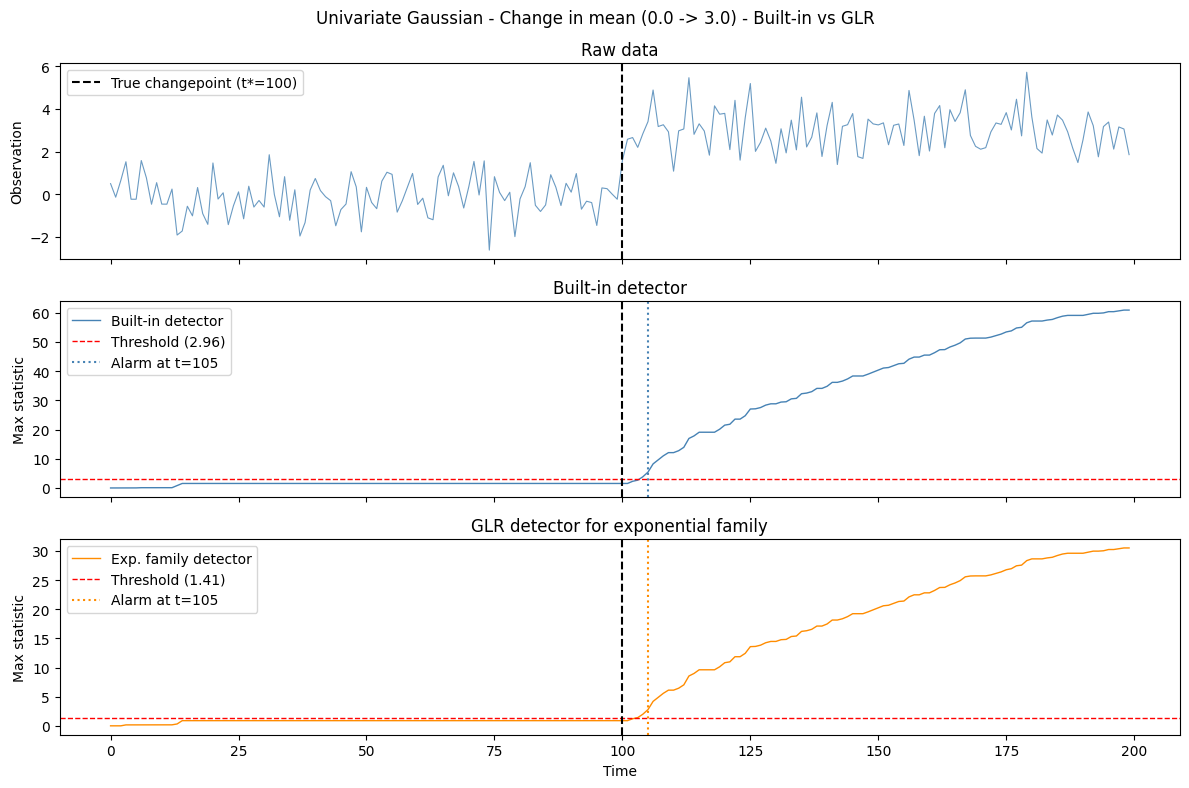


True changepoint:           t* = 100
Built-in detector alarm:    t  = 105
Exp. family detector alarm: t  = 105


In [5]:
# Univariate Gaussian (change in mean, known variance) - Example
import matplotlib.pyplot as plt

# Simulation settings
np.random.seed(42)
N_nvg          = 200
K_cal_nvg      = 5000
changepoint_nvg = N_nvg // 2
mu_pre         = 0.0
mu_post        = 3.0

# Simulate a single stream with a known changepoint
X = np.concatenate([
    np.random.normal(mu_pre,  1.0, changepoint_nvg),
    np.random.normal(mu_post, 1.0, N_nvg - changepoint_nvg)
])

# --- Built-in detector ---
det_builtin = make_univariate_mean_change_detector()
det_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Built-in penalty constant:    {det_builtin.penalty_constant:.4f}")

# --- Exponential family detector ---
@nb.njit
def h_gaussian(x):
    return x

@nb.njit
def A_gaussian(theta):
    return theta**2 / 2.0

det_expfam = make_exponential_family_detector(
    p=1,
    h=h_gaussian,
    A=A_gaussian,
    v=1,
    A_prime=A_prime_gaussian,
    A_dprime=A_dprime_gaussian,
)
det_expfam.calibrate_false_alarm(
    alpha=0.05,
    N=N_nvg,
    K=K_cal_nvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"GLR penalty constant: {det_expfam.penalty_constant:.4f}")

# --- Run both detectors on the same stream ---
stats_builtin = []
t_alarm_builtin = None
for i in range(N_nvg):
    det_builtin.update(X[i])
    stats_builtin.append(det_builtin.max_statistic)
    if det_builtin.alarm and t_alarm_builtin is None:
        t_alarm_builtin = det_builtin.t

stats_expfam = []
t_alarm_expfam = None
for i in range(N_nvg):
    det_expfam.update(X[i])
    stats_expfam.append(det_expfam.max_statistic)
    if det_expfam.alarm and t_alarm_expfam is None:
        t_alarm_expfam = det_expfam.t

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Univariate Gaussian - Change in mean ({mu_pre} -> {mu_post}) - Built-in vs GLR")

# Panel 1: raw data
axes[0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5,
                label=f"True changepoint (t*={changepoint_nvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

# Panel 2: built-in detector
axes[1].plot(stats_builtin, color="steelblue", linewidth=1.0, label="Built-in detector")
axes[1].axhline(det_builtin.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_builtin.penalty_constant:.2f})")
axes[1].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_builtin is not None:
    axes[1].axvline(t_alarm_builtin, color="steelblue", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_builtin}")
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("Built-in detector")

# Panel 3: exponential family detector
axes[2].plot(stats_expfam, color="darkorange", linewidth=1.0, label="Exp. family detector")
axes[2].axhline(det_expfam.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_expfam.penalty_constant:.2f})")
axes[2].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_expfam is not None:
    axes[2].axvline(t_alarm_expfam, color="darkorange", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_expfam}")
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("GLR detector for exponential family")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:           t* = {changepoint_nvg}")
print(f"Built-in detector alarm:    t  = {t_alarm_builtin}")
print(f"Exp. family detector alarm: t  = {t_alarm_expfam}")

Running built-in detector for 1000 streams...
Running GLR detector for 1000 streams...
Running built-in detector (null) for 1000 streams...
Running GLR detector (null) for 1000 streams...

Metric                        Built-in          GLR
--------------------------------------------------
Detection rate                   0.959        0.955
False alarm rate                 0.041        0.045
Miss rate                        0.000        0.000
Mean delay                       3.021        2.869
Median delay                     3.000        3.000
Null false alarm rate            0.057        0.049
Total runtime (s)                2.659        2.807


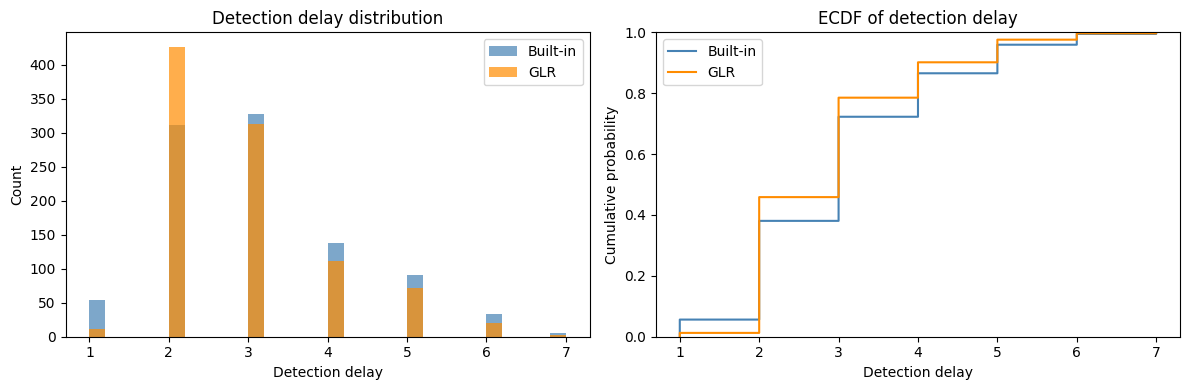

In [6]:
# Univariate Gaussian (change in mean, known variance) - Simulation study

K_nvg = 1000

def run_simulation(detector, X_streams):
    """
    Run a detector over K streams and record alarm times.
    Resets the detector between streams rather than recreating it.
    """
    alarm_times = []
    start = time.perf_counter()
    for k in range(len(X_streams)):
        detector.reset()
        t_alarm = None
        for i in range(X_streams.shape[1]):
            detector.update(X_streams[k, i])
            if detector.alarm and t_alarm is None:
                t_alarm = detector.t
                break
        alarm_times.append(t_alarm)
    elapsed = time.perf_counter() - start
    return alarm_times, elapsed

def compute_metrics(alarm_times, t_star, N):
    alarm_times = np.array([t if t is not None else np.nan for t in alarm_times])
    detected    = alarm_times <= N
    false_alarm = alarm_times <= t_star
    miss        = np.isnan(alarm_times)
    delay       = alarm_times[detected & ~false_alarm] - t_star
    return {
        "detection_rate":   np.mean(detected & ~false_alarm),
        "false_alarm_rate": np.mean(false_alarm),
        "miss_rate":        np.mean(miss),
        "mean_delay":       np.nanmean(delay),
        "median_delay":     np.nanmedian(delay),
    }

def compute_false_alarm_rate(alarm_times):
    return np.mean([t is not None for t in alarm_times])

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams = np.concatenate([
    np.random.normal(mu_pre,  1.0, (K_nvg, changepoint_nvg)),
    np.random.normal(mu_post, 1.0, (K_nvg, N_nvg - changepoint_nvg))
], axis=1)
X_null = np.random.normal(0.0, 1.0, (K_nvg, N_nvg))

# --- Run simulations ---
print(f"Running built-in detector for {K_nvg} streams...")
alarm_times_builtin, elapsed_builtin = run_simulation(det_builtin, X_streams)

print(f"Running GLR detector for {K_nvg} streams...")
alarm_times_expfam, elapsed_expfam = run_simulation(det_expfam, X_streams)

print(f"Running built-in detector (null) for {K_nvg} streams...")
alarm_times_builtin_null, _ = run_simulation(det_builtin, X_null)

print(f"Running GLR detector (null) for {K_nvg} streams...")
alarm_times_expfam_null, _ = run_simulation(det_expfam, X_null)

# --- Compute metrics ---
metrics_builtin = compute_metrics(alarm_times_builtin, changepoint_nvg, N_nvg)
metrics_expfam  = compute_metrics(alarm_times_expfam,  changepoint_nvg, N_nvg)
far_builtin     = compute_false_alarm_rate(alarm_times_builtin_null)
far_expfam      = compute_false_alarm_rate(alarm_times_expfam_null)

# --- Print results ---
print(f"\n{'Metric':<25} {'Built-in':>12} {'GLR':>12}")
print("-" * 50)
print(f"{'Detection rate':<25} {metrics_builtin['detection_rate']:>12.3f} {metrics_expfam['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_builtin['false_alarm_rate']:>12.3f} {metrics_expfam['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_builtin['miss_rate']:>12.3f} {metrics_expfam['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_builtin['mean_delay']:>12.3f} {metrics_expfam['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_builtin['median_delay']:>12.3f} {metrics_expfam['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_builtin:>12.3f} {far_expfam:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_builtin:>12.3f} {elapsed_expfam:>12.3f}")

# --- Plot: detection delay distributions ---
delays_builtin = [t - changepoint_nvg for t in alarm_times_builtin
                  if t is not None and t > changepoint_nvg]
delays_expfam  = [t - changepoint_nvg for t in alarm_times_expfam
                  if t is not None and t > changepoint_nvg]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delays_builtin, bins=30, color="steelblue", alpha=0.7, label="Built-in")
axes[0].hist(delays_expfam,  bins=30, color="darkorange", alpha=0.7, label="GLR")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

axes[1].ecdf(delays_builtin, color="steelblue", label="Built-in")
axes[1].ecdf(delays_expfam,  color="darkorange", label="GLR")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

Built-in penalty constant: 3.6966
Exp. family penalty constant: 19.7908


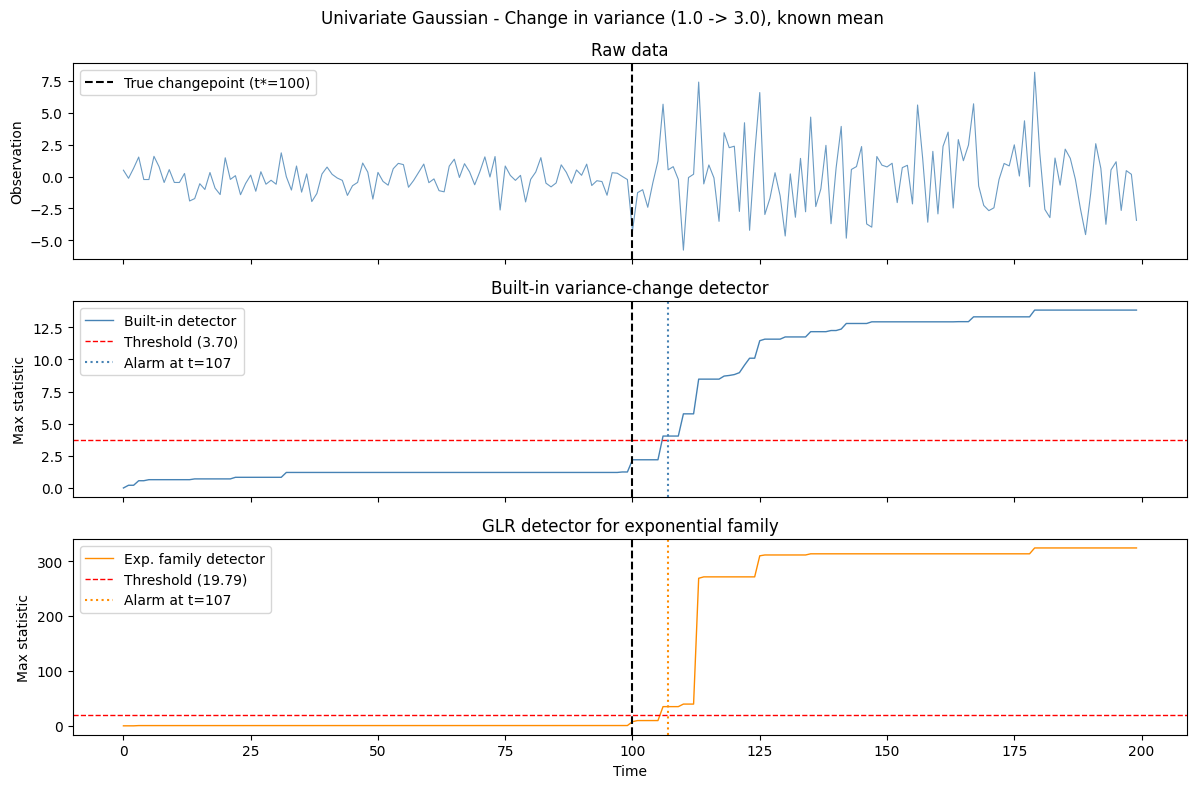


True changepoint:             t* = 100
Built-in detector alarm:      t  = 107
Exp. family detector alarm:   t  = 107


In [7]:
# Univariate Gaussian (change in variance, known mean) - Example

# Simulation settings
np.random.seed(42)
N_uvg           = 200
K_cal_uvg       = 5000
changepoint_uvg = N_uvg // 2
sigma_pre       = 1.0
sigma_post      = 3.0

# Simulate a single stream with a known changepoint
X = np.concatenate([
    np.random.normal(0.0, sigma_pre,  changepoint_uvg),
    np.random.normal(0.0, sigma_post, N_uvg - changepoint_uvg)
])

# --- Exponential family functions for variance change ---
@nb.njit
def h_variance(x):
    return np.array([x[0]**2])

@nb.njit
def A_variance(theta):
    return -0.5 * np.log(-2.0 * min(theta, -1e-10))

@nb.njit
def A_prime_variance(theta):
    return -1.0 / (2.0 * min(theta, -1e-10))

@nb.njit
def A_dprime_variance(theta):
    return 1.0 / (2.0 * min(theta, -1e-10)**2)

# --- Built-in detector ---
det_builtin_var = make_univariate_variance_change_detector()
det_builtin_var.calibrate_false_alarm(
    alpha=0.05,
    N=N_uvg,
    K=K_cal_uvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Built-in penalty constant: {det_builtin_var.penalty_constant:.4f}")

# --- Exponential family detector ---
det_expfam_var = make_exponential_family_detector(
    p=1,
    h=h_variance,
    A=A_variance,
    v=1,
    A_prime=A_prime_variance,
    A_dprime=A_dprime_variance,
    theta_init=-0.5,  # corresponds to sigma=1, i.e. the null
)
det_expfam_var.calibrate_false_alarm(
    alpha=0.05,
    N=N_uvg,
    K=K_cal_uvg,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0}
)
print(f"Exp. family penalty constant: {det_expfam_var.penalty_constant:.4f}")

# --- Run both detectors on the same stream ---
stats_builtin_var = []
t_alarm_builtin_var = None
for i in range(N_uvg):
    det_builtin_var.update(X[i])
    stats_builtin_var.append(det_builtin_var.max_statistic)
    if det_builtin_var.alarm and t_alarm_builtin_var is None:
        t_alarm_builtin_var = det_builtin_var.t

stats_expfam_var = []
t_alarm_expfam_var = None
for i in range(N_uvg):
    det_expfam_var.update(X[i])
    stats_expfam_var.append(det_expfam_var.max_statistic)
    if det_expfam_var.alarm and t_alarm_expfam_var is None:
        t_alarm_expfam_var = det_expfam_var.t

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Univariate Gaussian - Change in variance ({sigma_pre} -> {sigma_post}), known mean")

# Panel 1: raw data
axes[0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(changepoint_uvg, color="black", linestyle="--", linewidth=1.5,
                label=f"True changepoint (t*={changepoint_uvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

# Panel 2: built-in detector
axes[1].plot(stats_builtin_var, color="steelblue", linewidth=1.0, label="Built-in detector")
axes[1].axhline(det_builtin_var.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_builtin_var.penalty_constant:.2f})")
axes[1].axvline(changepoint_uvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_builtin_var is not None:
    axes[1].axvline(t_alarm_builtin_var, color="steelblue", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_builtin_var}")
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("Built-in variance-change detector")

# Panel 3: exponential family detector
axes[2].plot(stats_expfam_var, color="darkorange", linewidth=1.0, label="Exp. family detector")
axes[2].axhline(det_expfam_var.penalty_constant, color="red", linestyle="--",
                linewidth=1.0, label=f"Threshold ({det_expfam_var.penalty_constant:.2f})")
axes[2].axvline(changepoint_uvg, color="black", linestyle="--", linewidth=1.5)
if t_alarm_expfam_var is not None:
    axes[2].axvline(t_alarm_expfam_var, color="darkorange", linestyle=":",
                    linewidth=1.5, label=f"Alarm at t={t_alarm_expfam_var}")
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("GLR detector for exponential family")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:             t* = {changepoint_uvg}")
print(f"Built-in detector alarm:      t  = {t_alarm_builtin_var}")
print(f"Exp. family detector alarm:   t  = {t_alarm_expfam_var}")

Running built-in detector for 1000 streams...
Running GLR detector for 1000 streams...
Running built-in detector (null) for 1000 streams...
Running GLR detector (null) for 1000 streams...

Metric                        Built-in          GLR
--------------------------------------------------
Detection rate                   0.964        0.944
False alarm rate                 0.036        0.056
Miss rate                        0.000        0.000
Mean delay                       8.288        6.585
Median delay                     7.000        5.000
Null false alarm rate            0.048        0.047
Total runtime (s)                2.769        2.927


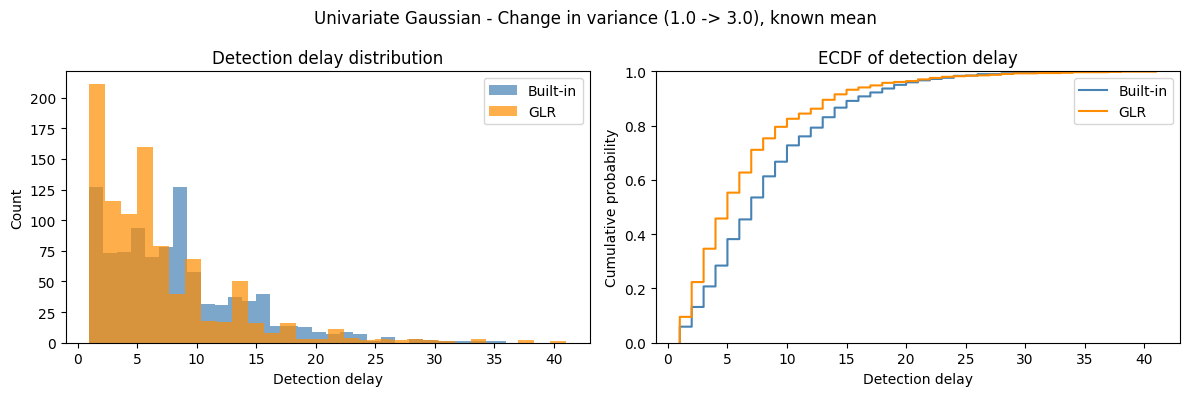

In [8]:


# Univariate Gaussian (change in variance, known mean) - Simulation study

K_uvg = 1000

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams_var = np.concatenate([
    np.random.normal(0.0, sigma_pre,  (K_uvg, changepoint_uvg)),
    np.random.normal(0.0, sigma_post, (K_uvg, N_uvg - changepoint_uvg))
], axis=1)
X_null_var = np.random.normal(0.0, sigma_pre, (K_uvg, N_uvg))

# --- Run simulations ---
print(f"Running built-in detector for {K_uvg} streams...")
alarm_times_builtin_var, elapsed_builtin_var = run_simulation(det_builtin_var, X_streams_var)

print(f"Running GLR detector for {K_uvg} streams...")
alarm_times_expfam_var, elapsed_expfam_var = run_simulation(det_expfam_var, X_streams_var)

print(f"Running built-in detector (null) for {K_uvg} streams...")
alarm_times_builtin_var_null, _ = run_simulation(det_builtin_var, X_null_var)

print(f"Running GLR detector (null) for {K_uvg} streams...")
alarm_times_expfam_var_null, _ = run_simulation(det_expfam_var, X_null_var)

# --- Compute metrics ---
metrics_builtin_var = compute_metrics(alarm_times_builtin_var, changepoint_uvg, N_uvg)
metrics_expfam_var  = compute_metrics(alarm_times_expfam_var,  changepoint_uvg, N_uvg)
far_builtin_var     = compute_false_alarm_rate(alarm_times_builtin_var_null)
far_expfam_var      = compute_false_alarm_rate(alarm_times_expfam_var_null)

# --- Print results ---
print(f"\n{'Metric':<25} {'Built-in':>12} {'GLR':>12}")
print("-" * 50)
print(f"{'Detection rate':<25} {metrics_builtin_var['detection_rate']:>12.3f} {metrics_expfam_var['detection_rate']:>12.3f}")
print(f"{'False alarm rate':<25} {metrics_builtin_var['false_alarm_rate']:>12.3f} {metrics_expfam_var['false_alarm_rate']:>12.3f}")
print(f"{'Miss rate':<25} {metrics_builtin_var['miss_rate']:>12.3f} {metrics_expfam_var['miss_rate']:>12.3f}")
print(f"{'Mean delay':<25} {metrics_builtin_var['mean_delay']:>12.3f} {metrics_expfam_var['mean_delay']:>12.3f}")
print(f"{'Median delay':<25} {metrics_builtin_var['median_delay']:>12.3f} {metrics_expfam_var['median_delay']:>12.3f}")
print(f"{'Null false alarm rate':<25} {far_builtin_var:>12.3f} {far_expfam_var:>12.3f}")
print(f"{'Total runtime (s)':<25} {elapsed_builtin_var:>12.3f} {elapsed_expfam_var:>12.3f}")

# --- Plot: detection delay distributions ---
delays_builtin_var = [t - changepoint_uvg for t in alarm_times_builtin_var
                      if t is not None and t > changepoint_uvg]
delays_expfam_var  = [t - changepoint_uvg for t in alarm_times_expfam_var
                      if t is not None and t > changepoint_uvg]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Univariate Gaussian - Change in variance ({sigma_pre} -> {sigma_post}), known mean")

axes[0].hist(delays_builtin_var, bins=30, color="steelblue",  alpha=0.7, label="Built-in")
axes[0].hist(delays_expfam_var,  bins=30, color="darkorange", alpha=0.7, label="GLR")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

axes[1].ecdf(delays_builtin_var, color="steelblue",  label="Built-in")
axes[1].ecdf(delays_expfam_var,  color="darkorange", label="GLR")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Univariate Poisson, exponential, bernoulli - Simulation settings
# --- Shared settings ---
N_nvg           = 1000 # stream length during calibration and testing
changepoint_nvg = N_nvg // 2 # true changepoint location
K_cal_nvg       = 1000 # number of streams for false alarm calibration
K_nvg           = 1000 # number of streams for performance evaluation

# --- Distribution parameters ---
lambda_pre  = 2.0
lambda_post = 6.0

beta_pre    = 1.0
beta_post   = 3.0

p_pre       = 0.3
p_post      = 0.7

Poisson GLR penalty constant:      1.4354
Poisson CF penalty constant:       1.7872
Exponential GLR penalty constant:  4.2600
Exponential CF penalty constant:   2.5040
Bernoulli GLR penalty constant:    1.4309
Bernoulli CF penalty constant:     1.2477


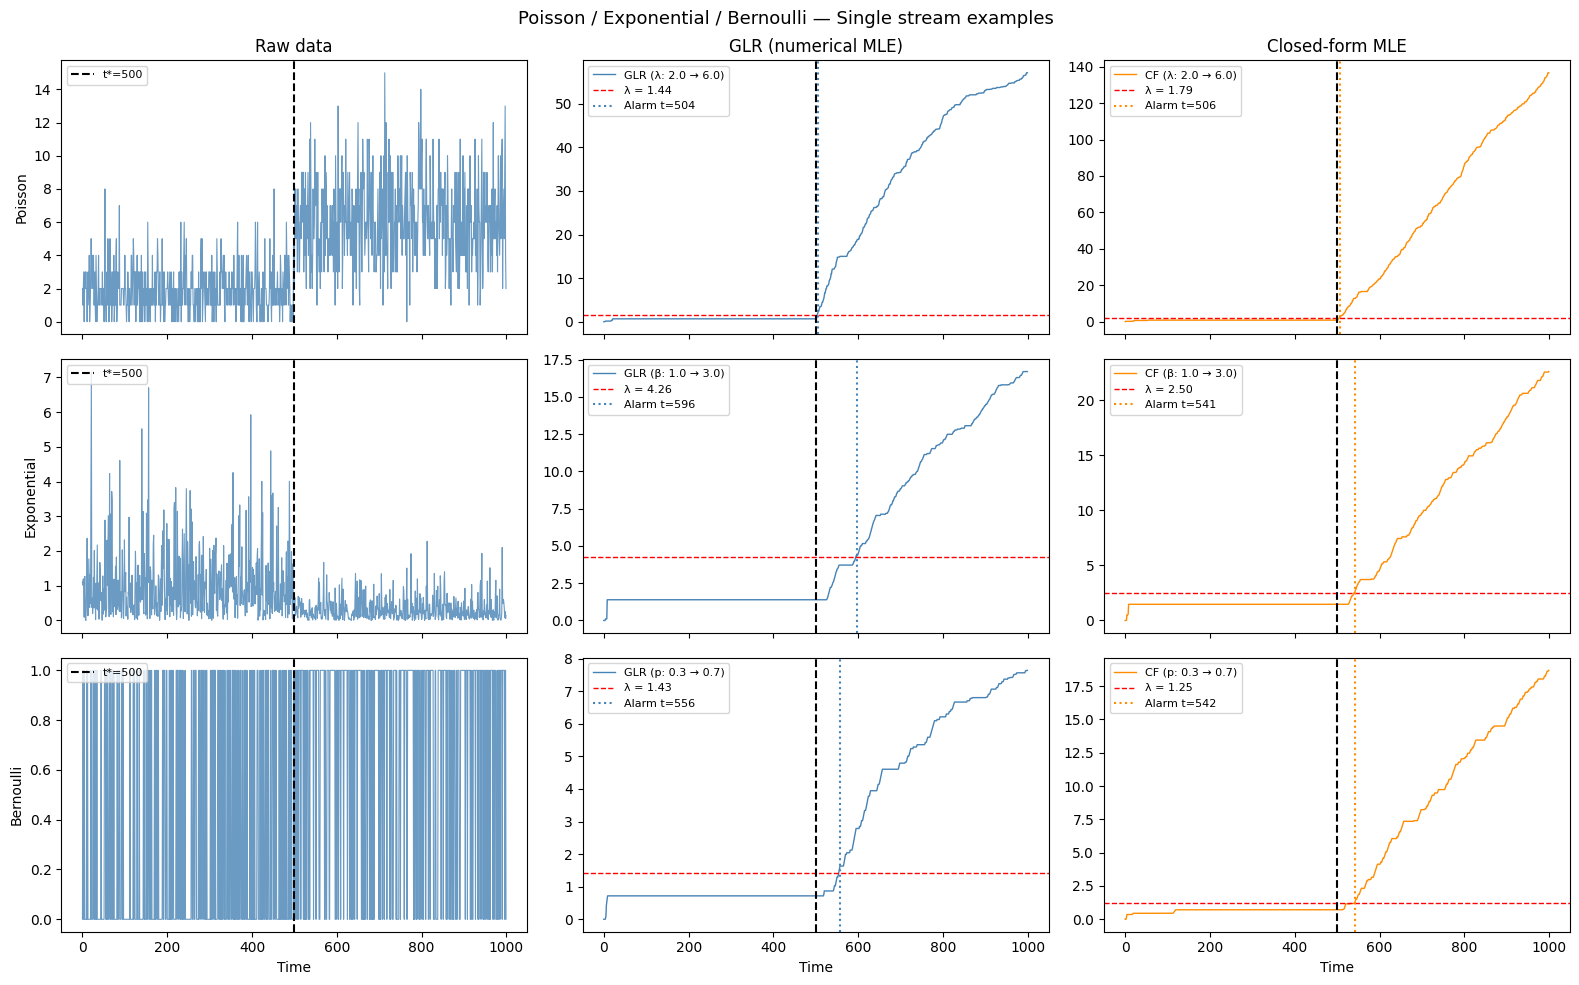


Distribution        t*    GLR alarm     CF alarm
------------------------------------------------
Poisson            500          504          506
Exponential        500          596          541
Bernoulli          500          556          542


In [24]:
# Univariate Poisson, Exponential, Bernoulli (change in parameter)- Examples
# -----------------------------------------------------------

# -----------------------------------------------------------
# GLR (numerical MLE) functions
# -----------------------------------------------------------

@nb.njit
def h_poisson(x):
    return np.array([x[0]])

@nb.njit
def A_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_prime_poisson(theta):
    return np.exp(theta)

@nb.njit
def A_dprime_poisson(theta):
    return np.exp(theta)

# ---

@nb.njit
def h_exponential(x):
    return np.array([x[0]])

@nb.njit
def A_exponential(theta):
    return -np.log(-min(theta, -1e-10))

@nb.njit
def A_prime_exponential(theta):
    return -1.0 / min(theta, -1e-10)

@nb.njit
def A_dprime_exponential(theta):
    return 1.0 / min(theta, -1e-10)**2

# ---

@nb.njit
def h_bernoulli(x):
    return np.array([x[0]])

@nb.njit
def A_bernoulli(theta):
    if theta > 20.0:
        return theta + np.log(1.0 + np.exp(-theta))
    return np.log(1.0 + np.exp(theta))

@nb.njit
def A_prime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bernoulli(theta):
    e = np.exp(theta)
    return e / (1.0 + e)**2

# -----------------------------------------------------------
# Closed-form MLE (analytical LR) functions
# -----------------------------------------------------------

@nb.njit
def h_cf_poisson(x):
    return np.array([x[0]])

@nb.njit
def f_cf_poisson(sum_pre, sum_post, n_pre, t):
    n_post = t - n_pre
    if n_pre == 0 or n_post == 0:
        return 0.0
    lam_hat_pre  = sum_pre[0]  / n_pre
    lam_hat_post = sum_post[0] / n_post
    if lam_hat_pre <= 0.0 or lam_hat_post <= 0.0:
        return 0.0
    return (n_pre  * (lam_hat_pre  * np.log(lam_hat_pre  / lambda_pre) - (lam_hat_pre  - lambda_pre))
          + n_post * (lam_hat_post * np.log(lam_hat_post / lambda_pre) - (lam_hat_post - lambda_pre)))

# ---

@nb.njit
def h_cf_exponential(x):
    return np.array([x[0]])

@nb.njit
def f_cf_exponential(sum_pre, sum_post, n_pre, t):
    n_post = t - n_pre
    if n_pre == 0 or n_post == 0 or sum_pre[0] <= 0.0 or sum_post[0] <= 0.0:
        return 0.0
    beta_hat_pre  = n_pre  / sum_pre[0]
    beta_hat_post = n_post / sum_post[0]
    return (n_pre  * (np.log(beta_hat_pre  / beta_pre) - 1.0 + beta_pre / beta_hat_pre)
          + n_post * (np.log(beta_hat_post / beta_pre) - 1.0 + beta_pre / beta_hat_post))

# ---

@nb.njit
def h_cf_bernoulli(x):
    return np.array([x[0]])

@nb.njit
def f_cf_bernoulli(sum_pre, sum_post, n_pre, t):
    n_post = t - n_pre
    if n_pre == 0 or n_post == 0:
        return 0.0
    p_hat_pre  = sum_pre[0]  / n_pre
    p_hat_post = sum_post[0] / n_post
    if p_hat_pre <= 0.0 or p_hat_pre >= 1.0 or p_hat_post <= 0.0 or p_hat_post >= 1.0:
        return 0.0
    return (sum_pre[0]  * np.log(p_hat_pre  / p_pre) + (n_pre  - sum_pre[0])  * np.log((1.0 - p_hat_pre)  / (1.0 - p_pre))
          + sum_post[0] * np.log(p_hat_post / p_pre) + (n_post - sum_post[0]) * np.log((1.0 - p_hat_post) / (1.0 - p_pre)))

# -----------------------------------------------------------
# Build and calibrate all detectors
# -----------------------------------------------------------

# Poisson
det_poisson_glr = make_exponential_family_detector(
    p=1, h=h_poisson, A=A_poisson, v=1,
    A_prime=A_prime_poisson, A_dprime=A_dprime_poisson,
)
det_poisson_glr.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.poisson, null_kwargs={"lam": lambda_pre}
)
print(f"Poisson GLR penalty constant:      {det_poisson_glr.penalty_constant:.4f}")

det_poisson_cf = OnlineChangepointDetector(
    p=1, h=h_cf_poisson, f=f_cf_poisson,
    penalty=det_poisson_glr._state["penalty"],
    penalty_constant=1.0
)
det_poisson_cf.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.poisson, null_kwargs={"lam": lambda_pre}
)
print(f"Poisson CF penalty constant:       {det_poisson_cf.penalty_constant:.4f}")

# Exponential
det_exponential_glr = make_exponential_family_detector(
    p=1, h=h_exponential, A=A_exponential, v=1,
    A_prime=A_prime_exponential, A_dprime=A_dprime_exponential,
    theta_init=-1.0,
)
det_exponential_glr.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.exponential, null_kwargs={"scale": 1.0 / beta_pre}
)
print(f"Exponential GLR penalty constant:  {det_exponential_glr.penalty_constant:.4f}")

det_exponential_cf = OnlineChangepointDetector(
    p=1, h=h_cf_exponential, f=f_cf_exponential,
    penalty=det_exponential_glr._state["penalty"],
    penalty_constant=1.0
)
det_exponential_cf.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.exponential, null_kwargs={"scale": 1.0 / beta_pre}
)
print(f"Exponential CF penalty constant:   {det_exponential_cf.penalty_constant:.4f}")

# Bernoulli
det_bernoulli_glr = make_exponential_family_detector(
    p=1, h=h_bernoulli, A=A_bernoulli, v=1,
    A_prime=A_prime_bernoulli, A_dprime=A_dprime_bernoulli,
)
det_bernoulli_glr.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.binomial, null_kwargs={"n": 1, "p": p_pre}
)
print(f"Bernoulli GLR penalty constant:    {det_bernoulli_glr.penalty_constant:.4f}")

det_bernoulli_cf = OnlineChangepointDetector(
    p=1, h=h_cf_bernoulli, f=f_cf_bernoulli,
    penalty=det_bernoulli_glr._state["penalty"],
    penalty_constant=1.0
)
det_bernoulli_cf.calibrate_false_alarm(
    alpha=0.05, N=N_nvg, K=K_cal_nvg,
    null_dist=np.random.binomial, null_kwargs={"n": 1, "p": p_pre}
)
print(f"Bernoulli CF penalty constant:     {det_bernoulli_cf.penalty_constant:.4f}")

# Poisson, Exponential, Bernoulli - Single stream examples
# Combined 3x3 plot: rows = distributions, cols = raw data / GLR / CF
# -----------------------------------------------------------

np.random.seed(20260317)
X_poisson_single = np.concatenate([
    np.random.poisson(lambda_pre,  changepoint_nvg),
    np.random.poisson(lambda_post, N_nvg - changepoint_nvg)
]).astype(float)

X_exponential_single = np.concatenate([
    np.random.exponential(1.0 / beta_pre,  changepoint_nvg),
    np.random.exponential(1.0 / beta_post, N_nvg - changepoint_nvg)
])

X_bernoulli_single = np.concatenate([
    np.random.binomial(1, p_pre,  changepoint_nvg),
    np.random.binomial(1, p_post, N_nvg - changepoint_nvg)
]).astype(float)

# --- Run all detectors ---
def run_single_stream(det_glr, det_cf, X):
    stats_glr, stats_cf = [], []
    t_alarm_glr = t_alarm_cf = None
    det_glr.reset()
    det_cf.reset()
    for i in range(len(X)):
        det_glr.update(X[i])
        det_cf.update(X[i])
        stats_glr.append(det_glr.max_statistic)
        stats_cf.append(det_cf.max_statistic)
        if det_glr.alarm and t_alarm_glr is None:
            t_alarm_glr = det_glr.t
        if det_cf.alarm and t_alarm_cf is None:
            t_alarm_cf = det_cf.t
    return stats_glr, stats_cf, t_alarm_glr, t_alarm_cf

stats_poisson_glr,     stats_poisson_cf,     t_alarm_poisson_glr,     t_alarm_poisson_cf     = run_single_stream(det_poisson_glr,     det_poisson_cf,     X_poisson_single)
stats_exponential_glr, stats_exponential_cf, t_alarm_exponential_glr, t_alarm_exponential_cf = run_single_stream(det_exponential_glr, det_exponential_cf, X_exponential_single)
stats_bernoulli_glr,   stats_bernoulli_cf,   t_alarm_bernoulli_glr,   t_alarm_bernoulli_cf   = run_single_stream(det_bernoulli_glr,   det_bernoulli_cf,   X_bernoulli_single)

# --- Plot ---
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
fig.suptitle("Poisson / Exponential / Bernoulli — Single stream examples", fontsize=13)

rows = [
    (
        "Poisson",
        f"λ: {lambda_pre} → {lambda_post}",
        X_poisson_single,
        stats_poisson_glr,     stats_poisson_cf,
        t_alarm_poisson_glr,   t_alarm_poisson_cf,
        det_poisson_glr,       det_poisson_cf,
    ),
    (
        "Exponential",
        f"β: {beta_pre} → {beta_post}",
        X_exponential_single,
        stats_exponential_glr,     stats_exponential_cf,
        t_alarm_exponential_glr,   t_alarm_exponential_cf,
        det_exponential_glr,       det_exponential_cf,
    ),
    (
        "Bernoulli",
        f"p: {p_pre} → {p_post}",
        X_bernoulli_single,
        stats_bernoulli_glr,     stats_bernoulli_cf,
        t_alarm_bernoulli_glr,   t_alarm_bernoulli_cf,
        det_bernoulli_glr,       det_bernoulli_cf,
    ),
]

for row_idx, (name, change_label, X, stats_glr, stats_cf,
              t_alarm_glr, t_alarm_cf, det_glr, det_cf) in enumerate(rows):

    # --- Col 0: raw data ---
    axes[row_idx, 0].plot(X, color="steelblue", linewidth=0.8, alpha=0.8)
    axes[row_idx, 0].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5,
                             label=f"t*={changepoint_nvg}")
    axes[row_idx, 0].set_ylabel(name)
    axes[row_idx, 0].legend(loc="upper left", fontsize=8)
    if row_idx == 0:
        axes[row_idx, 0].set_title("Raw data")

    # --- Col 1: GLR ---
    axes[row_idx, 1].plot(stats_glr, color="steelblue", linewidth=1.0, label=f"GLR ({change_label})")
    axes[row_idx, 1].axhline(det_glr.penalty_constant, color="red", linestyle="--", linewidth=1.0,
                             label=f"λ = {det_glr.penalty_constant:.2f}")
    axes[row_idx, 1].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
    if t_alarm_glr is not None:
        axes[row_idx, 1].axvline(t_alarm_glr, color="steelblue", linestyle=":",
                                 linewidth=1.5, label=f"Alarm t={t_alarm_glr}")
    axes[row_idx, 1].legend(loc="upper left", fontsize=8)
    if row_idx == 0:
        axes[row_idx, 1].set_title("GLR (numerical MLE)")

    # --- Col 2: Closed-form MLE ---
    axes[row_idx, 2].plot(stats_cf, color="darkorange", linewidth=1.0, label=f"CF ({change_label})")
    axes[row_idx, 2].axhline(det_cf.penalty_constant, color="red", linestyle="--", linewidth=1.0,
                             label=f"λ = {det_cf.penalty_constant:.2f}")
    axes[row_idx, 2].axvline(changepoint_nvg, color="black", linestyle="--", linewidth=1.5)
    if t_alarm_cf is not None:
        axes[row_idx, 2].axvline(t_alarm_cf, color="darkorange", linestyle=":",
                                 linewidth=1.5, label=f"Alarm t={t_alarm_cf}")
    axes[row_idx, 2].legend(loc="upper left", fontsize=8)
    if row_idx == 0:
        axes[row_idx, 2].set_title("Closed-form MLE")

for ax in axes[2, :]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()

print(f"\n{'Distribution':<15} {'t*':>6} {'GLR alarm':>12} {'CF alarm':>12}")
print("-" * 48)
for name, t_glr, t_cf in [
    ("Poisson",     t_alarm_poisson_glr,     t_alarm_poisson_cf),
    ("Exponential", t_alarm_exponential_glr, t_alarm_exponential_cf),
    ("Bernoulli",   t_alarm_bernoulli_glr,   t_alarm_bernoulli_cf),
]:
    print(f"{name:<15} {changepoint_nvg:>6} {str(t_glr):>12} {str(t_cf):>12}")

Running Poisson GLR detector (1000 streams)...
Running Poisson CF detector (1000 streams)...
Running Exponential GLR detector (1000 streams)...
Running Exponential CF detector (1000 streams)...
Running Bernoulli GLR detector (1000 streams)...
Running Bernoulli CF detector (1000 streams)...

Poisson (λ: 2.0 → 6.0)
Metric                               GLR  Closed-form MLE
---------------------------------------------------------
Detection rate                     0.946            0.945
False alarm rate                   0.054            0.055
Miss rate                          0.000            0.000
Mean delay                         5.771            6.814
Median delay                       5.000            6.000
Null FAR                           0.057            0.060
Runtime (s)                       15.094           14.333

Exponential (β: 1.0 → 3.0)
Metric                               GLR  Closed-form MLE
---------------------------------------------------------
Detection rate     

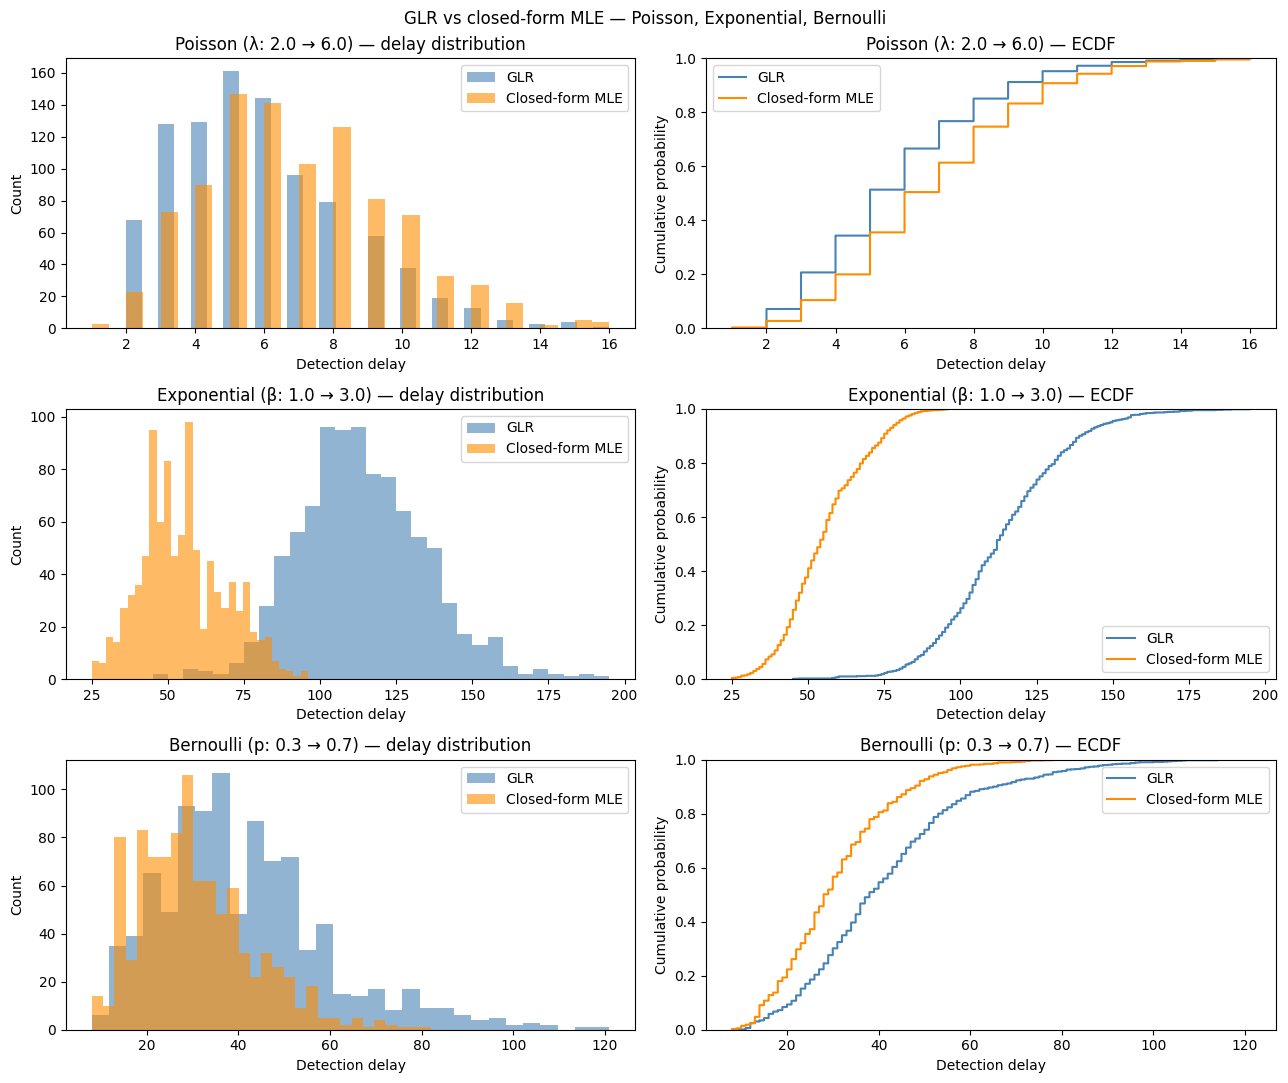

In [25]:
# Poisson, Exponential, Bernoulli - Simulation studies
# -----------------------------------------------------------
K_nvg = 1000

# --- Pre-simulate streams ---
np.random.seed(42)
X_streams_poisson = np.concatenate([
    np.random.poisson(lambda_pre,  (K_nvg, changepoint_nvg)),
    np.random.poisson(lambda_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1).astype(float)
X_null_poisson = np.random.poisson(lambda_pre, (K_nvg, N_nvg)).astype(float)

X_streams_exponential = np.concatenate([
    np.random.exponential(1.0 / beta_pre,  (K_nvg, changepoint_nvg)),
    np.random.exponential(1.0 / beta_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1)
X_null_exponential = np.random.exponential(1.0 / beta_pre, (K_nvg, N_nvg))

X_streams_bernoulli = np.concatenate([
    np.random.binomial(1, p_pre,  (K_nvg, changepoint_nvg)),
    np.random.binomial(1, p_post, (K_nvg, N_nvg - changepoint_nvg))
], axis=1).astype(float)
X_null_bernoulli = np.random.binomial(1, p_pre, (K_nvg, N_nvg)).astype(float)

# --- Run simulations ---
print(f"Running Poisson GLR detector ({K_nvg} streams)...")
alarm_times_poisson_glr, elapsed_poisson_glr         = run_simulation(det_poisson_glr,     X_streams_poisson)
alarm_times_poisson_glr_null, _                      = run_simulation(det_poisson_glr,     X_null_poisson)

print(f"Running Poisson CF detector ({K_nvg} streams)...")
alarm_times_poisson_cf, elapsed_poisson_cf           = run_simulation(det_poisson_cf,      X_streams_poisson)
alarm_times_poisson_cf_null, _                       = run_simulation(det_poisson_cf,      X_null_poisson)

print(f"Running Exponential GLR detector ({K_nvg} streams)...")
alarm_times_exponential_glr, elapsed_exponential_glr = run_simulation(det_exponential_glr, X_streams_exponential)
alarm_times_exponential_glr_null, _                  = run_simulation(det_exponential_glr, X_null_exponential)

print(f"Running Exponential CF detector ({K_nvg} streams)...")
alarm_times_exponential_cf, elapsed_exponential_cf   = run_simulation(det_exponential_cf,  X_streams_exponential)
alarm_times_exponential_cf_null, _                   = run_simulation(det_exponential_cf,  X_null_exponential)

print(f"Running Bernoulli GLR detector ({K_nvg} streams)...")
alarm_times_bernoulli_glr, elapsed_bernoulli_glr     = run_simulation(det_bernoulli_glr,   X_streams_bernoulli)
alarm_times_bernoulli_glr_null, _                    = run_simulation(det_bernoulli_glr,   X_null_bernoulli)

print(f"Running Bernoulli CF detector ({K_nvg} streams)...")
alarm_times_bernoulli_cf, elapsed_bernoulli_cf       = run_simulation(det_bernoulli_cf,    X_streams_bernoulli)
alarm_times_bernoulli_cf_null, _                     = run_simulation(det_bernoulli_cf,    X_null_bernoulli)

# --- Compute metrics ---
metrics_poisson_glr     = compute_metrics(alarm_times_poisson_glr,     changepoint_nvg, N_nvg)
metrics_poisson_cf      = compute_metrics(alarm_times_poisson_cf,      changepoint_nvg, N_nvg)
metrics_exponential_glr = compute_metrics(alarm_times_exponential_glr, changepoint_nvg, N_nvg)
metrics_exponential_cf  = compute_metrics(alarm_times_exponential_cf,  changepoint_nvg, N_nvg)
metrics_bernoulli_glr   = compute_metrics(alarm_times_bernoulli_glr,   changepoint_nvg, N_nvg)
metrics_bernoulli_cf    = compute_metrics(alarm_times_bernoulli_cf,    changepoint_nvg, N_nvg)

far_poisson_glr         = compute_false_alarm_rate(alarm_times_poisson_glr_null)
far_poisson_cf          = compute_false_alarm_rate(alarm_times_poisson_cf_null)
far_exponential_glr     = compute_false_alarm_rate(alarm_times_exponential_glr_null)
far_exponential_cf      = compute_false_alarm_rate(alarm_times_exponential_cf_null)
far_bernoulli_glr       = compute_false_alarm_rate(alarm_times_bernoulli_glr_null)
far_bernoulli_cf        = compute_false_alarm_rate(alarm_times_bernoulli_cf_null)

# --- Print results ---
for dist_name, metrics_glr, metrics_cf, far_glr, far_cf, elapsed_glr, elapsed_cf, change_label in [
    ("Poisson",     metrics_poisson_glr,     metrics_poisson_cf,     far_poisson_glr,     far_poisson_cf,     elapsed_poisson_glr,     elapsed_poisson_cf,     f"λ: {lambda_pre} → {lambda_post}"),
    ("Exponential", metrics_exponential_glr, metrics_exponential_cf, far_exponential_glr, far_exponential_cf, elapsed_exponential_glr, elapsed_exponential_cf, f"β: {beta_pre} → {beta_post}"),
    ("Bernoulli",   metrics_bernoulli_glr,   metrics_bernoulli_cf,   far_bernoulli_glr,   far_bernoulli_cf,   elapsed_bernoulli_glr,   elapsed_bernoulli_cf,   f"p: {p_pre} → {p_post}"),
]:
    print(f"\n{dist_name} ({change_label})")
    print(f"{'Metric':<25} {'GLR':>14} {'Closed-form MLE':>16}")
    print("-" * 57)
    for key, label in [
        ("detection_rate",   "Detection rate"),
        ("false_alarm_rate", "False alarm rate"),
        ("miss_rate",        "Miss rate"),
        ("mean_delay",       "Mean delay"),
        ("median_delay",     "Median delay"),
    ]:
        print(f"{label:<25} {metrics_glr[key]:>14.3f} {metrics_cf[key]:>16.3f}")
    print(f"{'Null FAR':<25} {far_glr:>14.3f} {far_cf:>16.3f}")
    print(f"{'Runtime (s)':<25} {elapsed_glr:>14.3f} {elapsed_cf:>16.3f}")

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
fig.suptitle("GLR vs closed-form MLE — Poisson, Exponential, Bernoulli")

plot_data = [
    (alarm_times_poisson_glr,     alarm_times_poisson_cf,     "Poisson",     f"λ: {lambda_pre} → {lambda_post}"),
    (alarm_times_exponential_glr, alarm_times_exponential_cf, "Exponential", f"β: {beta_pre} → {beta_post}"),
    (alarm_times_bernoulli_glr,   alarm_times_bernoulli_cf,   "Bernoulli",   f"p: {p_pre} → {p_post}"),
]

for row, (at_glr, at_cf, name, change_label) in enumerate(plot_data):
    delays_glr = [t - changepoint_nvg for t in at_glr if t is not None and t > changepoint_nvg]
    delays_cf  = [t - changepoint_nvg for t in at_cf  if t is not None and t > changepoint_nvg]

    axes[row, 0].hist(delays_glr, bins=30, color="steelblue",  alpha=0.6, label="GLR")
    axes[row, 0].hist(delays_cf,  bins=30, color="darkorange", alpha=0.6, label="Closed-form MLE")
    axes[row, 0].set_xlabel("Detection delay")
    axes[row, 0].set_ylabel("Count")
    axes[row, 0].set_title(f"{name} ({change_label}) — delay distribution")
    axes[row, 0].legend()

    axes[row, 1].ecdf(delays_glr, color="steelblue",  label="GLR")
    axes[row, 1].ecdf(delays_cf,  color="darkorange", label="Closed-form MLE")
    axes[row, 1].set_xlabel("Detection delay")
    axes[row, 1].set_ylabel("Cumulative probability")
    axes[row, 1].set_title(f"{name} ({change_label}) — ECDF")
    axes[row, 1].legend()

plt.tight_layout()
plt.show()

### $v>1$:
1. Univariate Gaussian: Change in mean and variance
2. Multivariate Gaussian: Change in mean (known variance)
3. Multivariate Gaussian: Change in covariance matrix (known mean)

theta_init: [ 0.    -0.125]
Univariate mean+var GLR penalty constant:      1.6052
Univariate mean+var built-in penalty constant: 3.7244


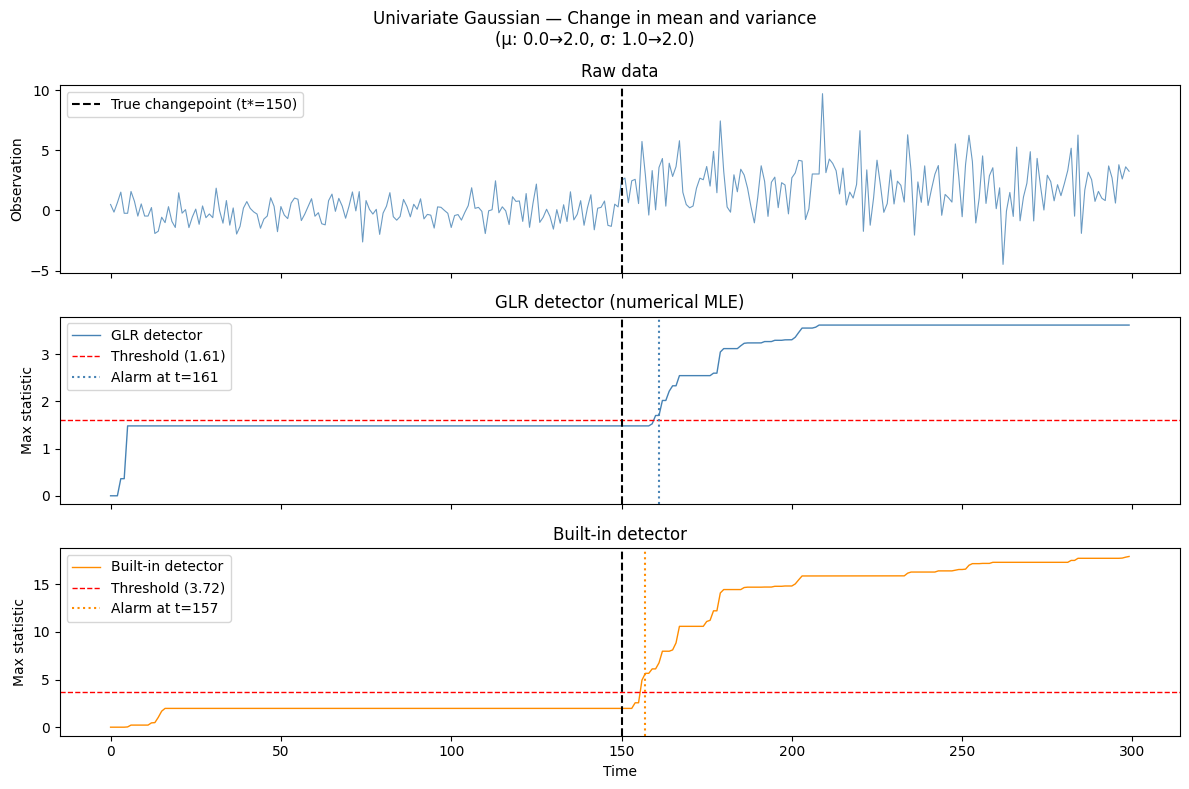


True changepoint:      t* = 150
GLR alarm:             t  = 161
Built-in alarm:        t  = 157


In [15]:
# -----------------------------------------------------------
# Case 1: Univariate Gaussian — change in mean AND variance
# theta = (mu/sigma^2, -1/(2*sigma^2))
# h(x)  = (x, x^2)
# A(theta) = -theta[0]^2 / (4*theta[1]) - 0.5*log(-2*theta[1])
# -----------------------------------------------------------

# --- Settings ---
N_v1 = 300
changepoint_v1 = N_v1 // 2
K_cal_v1 = 5000
K_v1 = 1000

mu_pre_uv = 0.0
sigma_pre_uv = 1.0
mu_post_uv = 2.0
sigma_post_uv = 2.0

# --- GLR functions ---
@nb.njit
def h_mv_gaussian_uv(x):
    return np.array([x[0], x[0] ** 2])


@nb.njit
def A_mv_gaussian_uv(theta):
    t0 = theta[0]
    t1 = theta[1]
    eps = 1e-8
    if t1 >= -eps:
        return np.nan
    return -t0**2 / (4.0 * t1) - 0.5 * np.log(-2.0 * t1)


@nb.njit
def A_grad_mv_gaussian_uv(theta):
    t0 = theta[0]
    t1 = theta[1]
    eps = 1e-8
    if t1 >= -eps:
        return np.array([np.nan, np.nan])
    g0 = -t0 / (2.0 * t1)
    g1 = t0**2 / (4.0 * t1**2) - 1.0 / (2.0 * t1)
    return np.array([g0, g1])


@nb.njit
def A_hess_mv_gaussian_uv(theta):
    t0 = theta[0]
    t1 = theta[1]
    eps = 1e-8
    if t1 >= -eps:
        H_bad = np.empty((2, 2))
        H_bad[0, 0] = np.nan
        H_bad[0, 1] = np.nan
        H_bad[1, 0] = np.nan
        H_bad[1, 1] = np.nan
        return H_bad

    h00 = -1.0 / (2.0 * t1)
    h01 = t0 / (2.0 * t1**2)
    h10 = t0 / (2.0 * t1**2)
    h11 = -t0**2 / (2.0 * t1**3) + 1.0 / (2.0 * t1**2)
    return np.array([[h00, h01], [h10, h11]])


# theta_init: corresponds to null mu, sigma
# Use a slightly inflated sigma for init to stay well away from boundary
_sigma2_init_uv = (sigma_pre_uv * 2.0) ** 2  # use 2*sigma as init
_mu_init_uv = 0.0
_theta_init_uv = np.array([
    _mu_init_uv / _sigma2_init_uv,
    -1.0 / (2.0 * _sigma2_init_uv),
])
print(f"theta_init: {_theta_init_uv}")  # should be [0.0, -0.125]

# --- Build and calibrate detectors ---
det_uv_glr = make_exponential_family_detector(
    p=1,
    h=h_mv_gaussian_uv,
    A=A_mv_gaussian_uv,
    v=2,
    A_grad=A_grad_mv_gaussian_uv,
    A_hess=A_hess_mv_gaussian_uv,
    theta_init=_theta_init_uv,
)
det_uv_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_v1,
    K=K_cal_v1,
    null_dist=np.random.normal,
    null_kwargs={"loc": mu_pre_uv, "scale": sigma_pre_uv},
)
print(f"Univariate mean+var GLR penalty constant:      {det_uv_glr.penalty_constant:.4f}")

det_uv_builtin = make_univariate_mean_or_variance_change_detector()
det_uv_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_v1,
    K=K_cal_v1,
    null_dist=np.random.normal,
    null_kwargs={"loc": mu_pre_uv, "scale": sigma_pre_uv},
)
print(f"Univariate mean+var built-in penalty constant: {det_uv_builtin.penalty_constant:.4f}")

# -----------------------------------------------------------
# Single stream example
# -----------------------------------------------------------
np.random.seed(42)
X_uv = np.concatenate(
    [
        np.random.normal(mu_pre_uv, sigma_pre_uv, changepoint_v1),
        np.random.normal(mu_post_uv, sigma_post_uv, N_v1 - changepoint_v1),
    ]
)

stats_uv_glr = []
stats_uv_builtin = []
t_alarm_uv_glr = None
t_alarm_uv_builtin = None

det_uv_glr.reset()
det_uv_builtin.reset()
for i in range(N_v1):
    det_uv_glr.update(X_uv[i])
    det_uv_builtin.update(X_uv[i])
    stats_uv_glr.append(det_uv_glr.max_statistic)
    stats_uv_builtin.append(det_uv_builtin.max_statistic)
    if det_uv_glr.alarm and t_alarm_uv_glr is None:
        t_alarm_uv_glr = det_uv_glr.t
    if det_uv_builtin.alarm and t_alarm_uv_builtin is None:
        t_alarm_uv_builtin = det_uv_builtin.t

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Univariate Gaussian — Change in mean and variance\n"
    f"(μ: {mu_pre_uv}→{mu_post_uv}, σ: {sigma_pre_uv}→{sigma_post_uv})"
)

axes[0].plot(X_uv, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(
    changepoint_v1,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"True changepoint (t*={changepoint_v1})",
)
axes[0].set_ylabel("Observation")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data")

axes[1].plot(stats_uv_glr, color="steelblue", linewidth=1.0, label="GLR detector")
axes[1].axhline(
    det_uv_glr.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_uv_glr.penalty_constant:.2f})",
)
axes[1].axvline(changepoint_v1, color="black", linestyle="--", linewidth=1.5)
if t_alarm_uv_glr is not None:
    axes[1].axvline(
        t_alarm_uv_glr,
        color="steelblue",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_uv_glr}",
    )
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("GLR detector (numerical MLE)")

axes[2].plot(stats_uv_builtin, color="darkorange", linewidth=1.0, label="Built-in detector")
axes[2].axhline(
    det_uv_builtin.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_uv_builtin.penalty_constant:.2f})",
)
axes[2].axvline(changepoint_v1, color="black", linestyle="--", linewidth=1.5)
if t_alarm_uv_builtin is not None:
    axes[2].axvline(
        t_alarm_uv_builtin,
        color="darkorange",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_uv_builtin}",
    )
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Built-in detector")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:      t* = {changepoint_v1}")
print(f"GLR alarm:             t  = {t_alarm_uv_glr}")
print(f"Built-in alarm:        t  = {t_alarm_uv_builtin}")

Running univariate mean+var GLR (1000 streams)...
Running univariate mean+var built-in (1000 streams)...

Univariate Gaussian — Change in mean and variance (μ: 0.0→2.0, σ: 1.0→2.0)
Metric                               GLR       Built-in
-------------------------------------------------------
Detection rate                     0.948          0.957
False alarm rate                   0.052          0.043
Miss rate                          0.000          0.000
Mean delay                        15.404          8.144
Median delay                      14.000          7.000
Null FAR                           0.045          0.051
Runtime (s)                        9.943          4.234


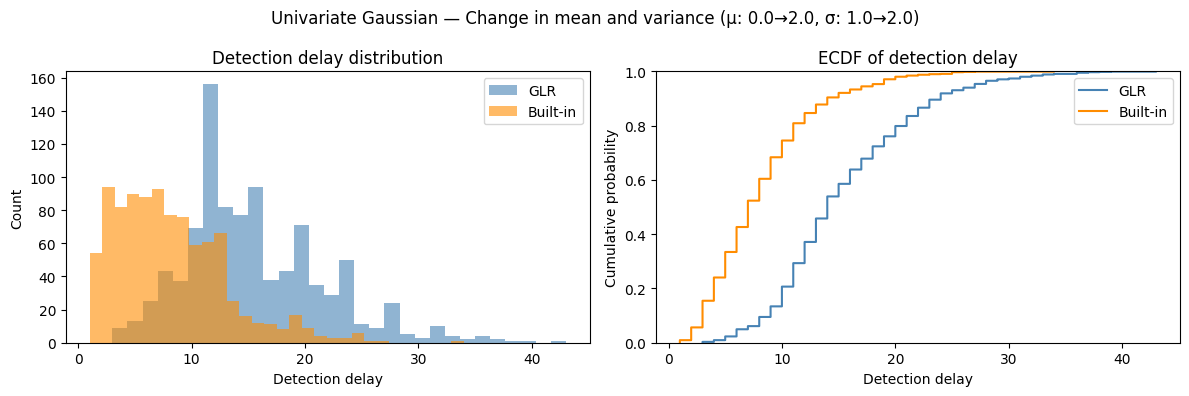

In [18]:
# Univariate Gaussian - Change in mean AND variance - Simulation study

import time
import numpy as np
import matplotlib.pyplot as plt
 
# --- Guard: catch missing variables early with a clear message ---
_required = [
    "det_uv_glr", "det_uv_builtin",
    "K_v1", "N_v1", "changepoint_v1",
    "mu_pre_uv", "mu_post_uv", "sigma_pre_uv", "sigma_post_uv",
]
_missing = [v for v in _required if v not in globals()]
if _missing:
    raise RuntimeError(
        f"The following variables must be defined before running this cell: {_missing}"
    )
 
# --- Local helpers (fallback definitions if earlier utility cell was not run) ---
if "run_simulation" not in globals():
    def run_simulation(detector, X_streams):
        start = time.perf_counter()
        alarm_times = []
        for k in range(X_streams.shape[0]):
            detector.reset()
            t_alarm = None
            for x in X_streams[k]:
                detector.update(x)
                if detector.alarm:
                    t_alarm = detector.t
                    break
            alarm_times.append(t_alarm)
        elapsed = time.perf_counter() - start
        return alarm_times, elapsed
 
if "compute_metrics" not in globals():
    def compute_metrics(alarm_times, t_star, N):
        alarm_times = np.array(
            [t if t is not None else np.nan for t in alarm_times], dtype=float
        )
        detected = ~np.isnan(alarm_times)
        # t_star is the first post-change index, so an alarm at t_star is a
        # true positive, not a false alarm — hence strict < here.
        false_alarm = detected & (alarm_times < t_star)
        miss = np.isnan(alarm_times)
        post_change = detected & (alarm_times >= t_star)
        delay = alarm_times[post_change] - t_star
 
        return {
            "detection_rate": float(np.mean(post_change)),
            "false_alarm_rate": float(np.mean(false_alarm)),
            "miss_rate": float(np.mean(miss)),
            "mean_delay": float(np.nanmean(delay)) if delay.size else np.nan,
            "median_delay": float(np.nanmedian(delay)) if delay.size else np.nan,
        }
 
if "compute_false_alarm_rate" not in globals():
    def compute_false_alarm_rate(alarm_times):
        alarm_times = np.array(
            [t if t is not None else np.nan for t in alarm_times], dtype=float
        )
        return float(np.mean(~np.isnan(alarm_times)))
 
# --- Settings / data ---
np.random.seed(42)
X_streams_uv = np.concatenate(
    [
        np.random.normal(mu_pre_uv, sigma_pre_uv, (K_v1, changepoint_v1)),
        np.random.normal(mu_post_uv, sigma_post_uv, (K_v1, N_v1 - changepoint_v1)),
    ],
    axis=1,
)
X_null_uv = np.random.normal(mu_pre_uv, sigma_pre_uv, (K_v1, N_v1))
 
print(f"Running univariate mean+var GLR ({K_v1} streams)...")
alarm_times_uv_glr, elapsed_uv_glr = run_simulation(det_uv_glr, X_streams_uv)
alarm_times_uv_glr_null, _ = run_simulation(det_uv_glr, X_null_uv)
 
print(f"Running univariate mean+var built-in ({K_v1} streams)...")
alarm_times_uv_bi, elapsed_uv_bi = run_simulation(det_uv_builtin, X_streams_uv)
alarm_times_uv_bi_null, _ = run_simulation(det_uv_builtin, X_null_uv)
 
metrics_uv_glr = compute_metrics(alarm_times_uv_glr, changepoint_v1, N_v1)
metrics_uv_bi = compute_metrics(alarm_times_uv_bi, changepoint_v1, N_v1)
far_uv_glr = compute_false_alarm_rate(alarm_times_uv_glr_null)
far_uv_bi = compute_false_alarm_rate(alarm_times_uv_bi_null)
 
print(
    f"\nUnivariate Gaussian — Change in mean and variance "
    f"(μ: {mu_pre_uv}→{mu_post_uv}, σ: {sigma_pre_uv}→{sigma_post_uv})"
)
print(f"{'Metric':<25} {'GLR':>14} {'Built-in':>14}")
print("-" * 55)
for key, label in [
    ("detection_rate",   "Detection rate"),
    ("false_alarm_rate", "False alarm rate"),
    ("miss_rate",        "Miss rate"),
    ("mean_delay",       "Mean delay"),
    ("median_delay",     "Median delay"),
]:
    print(f"{label:<25} {metrics_uv_glr[key]:>14.3f} {metrics_uv_bi[key]:>14.3f}")
print(f"{'Null FAR':<25} {far_uv_glr:>14.3f} {far_uv_bi:>14.3f}")
print(f"{'Runtime (s)':<25} {elapsed_uv_glr:>14.3f} {elapsed_uv_bi:>14.3f}")
 
delays_uv_glr = [
    t - changepoint_v1
    for t in alarm_times_uv_glr
    if t is not None and t >= changepoint_v1  # consistent with >= convention above
]
delays_uv_bi = [
    t - changepoint_v1
    for t in alarm_times_uv_bi
    if t is not None and t >= changepoint_v1
]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Univariate Gaussian — Change in mean and variance "
    f"(μ: {mu_pre_uv}→{mu_post_uv}, σ: {sigma_pre_uv}→{sigma_post_uv})"
)
 
axes[0].hist(delays_uv_glr, bins=30, color="steelblue", alpha=0.6, label="GLR")
axes[0].hist(delays_uv_bi,  bins=30, color="darkorange", alpha=0.6, label="Built-in")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()
 
if len(delays_uv_glr) > 0:
    axes[1].ecdf(delays_uv_glr, color="steelblue", label="GLR")
if len(delays_uv_bi) > 0:
    axes[1].ecdf(delays_uv_bi, color="darkorange", label="Built-in")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()
 
plt.tight_layout()
plt.show()

theta_init: [0. 0. 0.]
Multivariate mean GLR penalty constant:      0.7116
Multivariate mean built-in penalty constant: 3.1520


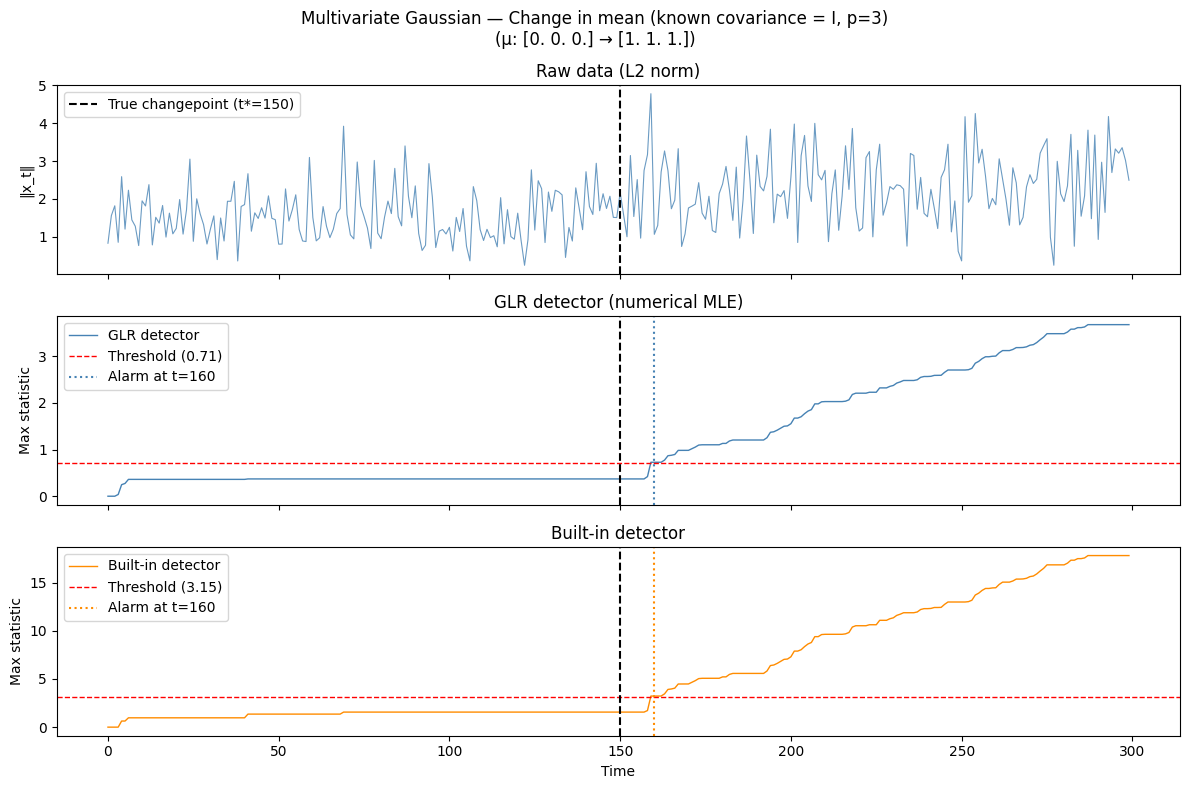


True changepoint:      t* = 150
GLR alarm:             t  = 160
Built-in alarm:        t  = 160


In [19]:
# Case 2: Multivariate Gaussian — change in mean (known covariance = I)
# theta = mu  (natural parameter = mean for identity covariance)
# h(x)  = x
# A(theta) = 0.5 * ||theta||^2
# -----------------------------------------------------------
 
# --- Settings ---
N_mv = 300
changepoint_mv = N_mv // 2
K_cal_mv = 5000
K_mv = 1000
 
p_mv = 3
mu_pre_mv  = np.zeros(p_mv)
mu_post_mv = np.array([1.0, 1.0, 1.0])
 
# --- GLR functions ---
@nb.njit
def h_mv_mean(x):
    return x.copy()
 
 
@nb.njit
def A_mv_mean(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s
 
 
@nb.njit
def A_grad_mv_mean(theta):
    return theta.copy()
 
 
@nb.njit
def A_hess_mv_mean(theta):
    return np.eye(theta.shape[0])
 
 
_theta_init_mv = mu_pre_mv.copy()
print(f"theta_init: {_theta_init_mv}")  # should be [0. 0. 0.]
 
# --- Build and calibrate detectors ---
det_mv_glr = make_exponential_family_detector(
    p=p_mv,
    h=h_mv_mean,
    A=A_mv_mean,
    v=p_mv,
    A_grad=A_grad_mv_mean,
    A_hess=A_hess_mv_mean,
    theta_init=_theta_init_mv,
)
det_mv_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal_mv,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0, "size": p_mv},
)
print(f"Multivariate mean GLR penalty constant:      {det_mv_glr.penalty_constant:.4f}")
 
det_mv_builtin = make_multivariate_mean_change_detector(p=p_mv, mode="known_variance")
det_mv_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal_mv,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0, "size": p_mv},
)
print(f"Multivariate mean built-in penalty constant: {det_mv_builtin.penalty_constant:.4f}")
 
# -----------------------------------------------------------
# Single stream example
# -----------------------------------------------------------
np.random.seed(42)
X_mv = np.concatenate(
    [
        np.random.multivariate_normal(mu_pre_mv,  np.eye(p_mv), changepoint_mv),
        np.random.multivariate_normal(mu_post_mv, np.eye(p_mv), N_mv - changepoint_mv),
    ]
)
 
stats_mv_glr     = []
stats_mv_builtin = []
t_alarm_mv_glr     = None
t_alarm_mv_builtin = None
 
det_mv_glr.reset()
det_mv_builtin.reset()
for i in range(N_mv):
    det_mv_glr.update(X_mv[i])
    det_mv_builtin.update(X_mv[i])
    stats_mv_glr.append(det_mv_glr.max_statistic)
    stats_mv_builtin.append(det_mv_builtin.max_statistic)
    if det_mv_glr.alarm and t_alarm_mv_glr is None:
        t_alarm_mv_glr = det_mv_glr.t
    if det_mv_builtin.alarm and t_alarm_mv_builtin is None:
        t_alarm_mv_builtin = det_mv_builtin.t
 
# Summarise the stream as its L2 norm over time for plotting
X_mv_norm = np.linalg.norm(X_mv, axis=1)
 
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Multivariate Gaussian — Change in mean (known covariance = I, p={p_mv})\n"
    f"(μ: {mu_pre_mv} → {mu_post_mv})"
)
 
axes[0].plot(X_mv_norm, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(
    changepoint_mv,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"True changepoint (t*={changepoint_mv})",
)
axes[0].set_ylabel("‖x_t‖")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data (L2 norm)")
 
axes[1].plot(stats_mv_glr, color="steelblue", linewidth=1.0, label="GLR detector")
axes[1].axhline(
    det_mv_glr.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_mv_glr.penalty_constant:.2f})",
)
axes[1].axvline(changepoint_mv, color="black", linestyle="--", linewidth=1.5)
if t_alarm_mv_glr is not None:
    axes[1].axvline(
        t_alarm_mv_glr,
        color="steelblue",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_mv_glr}",
    )
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("GLR detector (numerical MLE)")
 
axes[2].plot(stats_mv_builtin, color="darkorange", linewidth=1.0, label="Built-in detector")
axes[2].axhline(
    det_mv_builtin.penalty_constant,
    color="red",
    linestyle="--",
    linewidth=1.0,
    label=f"Threshold ({det_mv_builtin.penalty_constant:.2f})",
)
axes[2].axvline(changepoint_mv, color="black", linestyle="--", linewidth=1.5)
if t_alarm_mv_builtin is not None:
    axes[2].axvline(
        t_alarm_mv_builtin,
        color="darkorange",
        linestyle=":",
        linewidth=1.5,
        label=f"Alarm at t={t_alarm_mv_builtin}",
    )
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Built-in detector")
 
plt.tight_layout()
plt.show()
 
print(f"\nTrue changepoint:      t* = {changepoint_mv}")
print(f"GLR alarm:             t  = {t_alarm_mv_glr}")
print(f"Built-in alarm:        t  = {t_alarm_mv_builtin}")

GLR penalty constant:      0.7116
Built-in penalty constant: 3.1520

Running GLR detector (1000 streams)...
Running built-in detector (1000 streams)...

Multivariate Gaussian — Change in mean (known covariance = I, p=3)
μ: [0. 0. 0.] → [1. 1. 1.]

Metric                             GLR     Built-in
--------------------------------------------------
Detection rate                   0.960        0.950
False alarm rate                 0.040        0.050
Miss rate                        0.000        0.000
Mean delay                      12.105       12.113
Median delay                    11.000       11.000
Null FAR                         0.041        0.041
Runtime (s)                      5.504        4.189


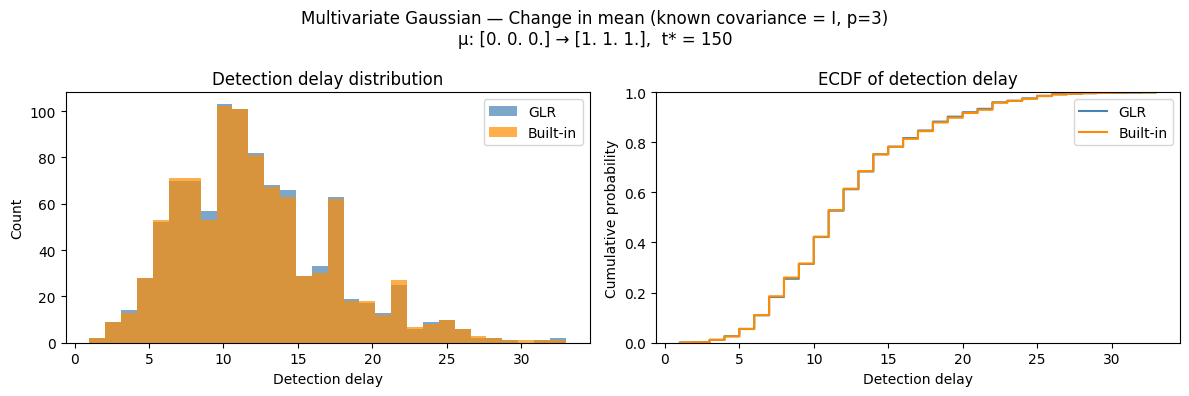

In [21]:
# Multivariate Gaussian - Change in mean (known covariance = I) - Simulation study

import time
import numpy as np
import numba as nb
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Settings
# -----------------------------------------------------------
N_mv        = 300
changepoint = N_mv // 2
K_cal       = 5000
K           = 1000
p           = 3

mu_pre  = np.zeros(p)
mu_post = np.ones(p)

# -----------------------------------------------------------
# Null sampler
# np.random.multivariate_normal requires mean and cov as
# positional args, so it can't be passed via null_kwargs.
# Wrap it in a no-arg callable instead.
# -----------------------------------------------------------
def null_dist():
    return np.random.multivariate_normal(mu_pre, np.eye(p))

# -----------------------------------------------------------
# GLR exponential family functions
# For MVN with known covariance = I:
#   h(x)      = x
#   A(theta)  = 0.5 * ||theta||^2
#   grad A    = theta
#   hess A    = I
# -----------------------------------------------------------
@nb.njit
def h_mv(x):
    return x.copy()

@nb.njit
def A_mv(theta):
    s = 0.0
    for i in range(theta.shape[0]):
        s += theta[i] * theta[i]
    return 0.5 * s

@nb.njit
def A_grad_mv(theta):
    return theta.copy()

@nb.njit
def A_hess_mv(theta):
    return np.eye(theta.shape[0])

# theta_init at null mean (zeros)
theta_init = mu_pre.copy()

# -----------------------------------------------------------
# Build and calibrate detectors
# -----------------------------------------------------------
det_glr = make_exponential_family_detector(
    p=p,
    h=h_mv,
    A=A_mv,
    v=p,
    A_grad=A_grad_mv,
    A_hess=A_hess_mv,
    theta_init=theta_init,
)
det_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal,
    null_dist=null_dist,
)
print(f"GLR penalty constant:      {det_glr.penalty_constant:.4f}")

det_builtin = make_multivariate_mean_change_detector(p=p, mode="known_variance")
det_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_mv,
    K=K_cal,
    null_dist=null_dist,
)
print(f"Built-in penalty constant: {det_builtin.penalty_constant:.4f}")

# -----------------------------------------------------------
# Helper functions
# -----------------------------------------------------------
def run_simulation(detector, X_streams):
    start = time.perf_counter()
    alarm_times = []
    for k in range(X_streams.shape[0]):
        detector.reset()
        t_alarm = None
        for x in X_streams[k]:
            detector.update(x)
            if detector.alarm:
                t_alarm = detector.t
                break
        alarm_times.append(t_alarm)
    elapsed = time.perf_counter() - start
    return alarm_times, elapsed

def compute_metrics(alarm_times, t_star):
    alarm_times = np.array(
        [t if t is not None else np.nan for t in alarm_times], dtype=float
    )
    detected    = ~np.isnan(alarm_times)
    # t_star is the first post-change index: alarm at t_star is a true positive
    false_alarm = detected & (alarm_times < t_star)
    miss        = np.isnan(alarm_times)
    post_change = detected & (alarm_times >= t_star)
    delay       = alarm_times[post_change] - t_star
    return {
        "detection_rate":   float(np.mean(post_change)),
        "false_alarm_rate": float(np.mean(false_alarm)),
        "miss_rate":        float(np.mean(miss)),
        "mean_delay":       float(np.nanmean(delay)) if delay.size else np.nan,
        "median_delay":     float(np.nanmedian(delay)) if delay.size else np.nan,
    }

def compute_far(alarm_times):
    alarm_times = np.array(
        [t if t is not None else np.nan for t in alarm_times], dtype=float
    )
    return float(np.mean(~np.isnan(alarm_times)))

# -----------------------------------------------------------
# Simulate streams
# -----------------------------------------------------------
np.random.seed(42)
X_streams = np.concatenate([
    np.random.multivariate_normal(mu_pre,  np.eye(p), (K, changepoint)),
    np.random.multivariate_normal(mu_post, np.eye(p), (K, N_mv - changepoint)),
], axis=1)  # shape (K, N_mv, p)

X_null = np.random.multivariate_normal(mu_pre, np.eye(p), (K, N_mv))
# shape (K, N_mv, p) — multivariate_normal with size=(K, N_mv) gives (K, N_mv, p)

# -----------------------------------------------------------
# Run simulations
# -----------------------------------------------------------
print(f"\nRunning GLR detector ({K} streams)...")
alarm_times_glr,     elapsed_glr     = run_simulation(det_glr,     X_streams)
alarm_times_glr_null, _              = run_simulation(det_glr,     X_null)

print(f"Running built-in detector ({K} streams)...")
alarm_times_builtin, elapsed_builtin = run_simulation(det_builtin, X_streams)
alarm_times_builtin_null, _          = run_simulation(det_builtin, X_null)

# -----------------------------------------------------------
# Metrics
# -----------------------------------------------------------
metrics_glr     = compute_metrics(alarm_times_glr,     changepoint)
metrics_builtin = compute_metrics(alarm_times_builtin, changepoint)
far_glr         = compute_far(alarm_times_glr_null)
far_builtin     = compute_far(alarm_times_builtin_null)

print(f"\nMultivariate Gaussian — Change in mean (known covariance = I, p={p})")
print(f"μ: {mu_pre} → {mu_post}")
print(f"\n{'Metric':<25} {'GLR':>12} {'Built-in':>12}")
print("-" * 50)
for key, label in [
    ("detection_rate",   "Detection rate"),
    ("false_alarm_rate", "False alarm rate"),
    ("miss_rate",        "Miss rate"),
    ("mean_delay",       "Mean delay"),
    ("median_delay",     "Median delay"),
]:
    print(f"{label:<25} {metrics_glr[key]:>12.3f} {metrics_builtin[key]:>12.3f}")
print(f"{'Null FAR':<25} {far_glr:>12.3f} {far_builtin:>12.3f}")
print(f"{'Runtime (s)':<25} {elapsed_glr:>12.3f} {elapsed_builtin:>12.3f}")

# -----------------------------------------------------------
# Plot
# -----------------------------------------------------------
delays_glr     = [t - changepoint for t in alarm_times_glr
                  if t is not None and t >= changepoint]
delays_builtin = [t - changepoint for t in alarm_times_builtin
                  if t is not None and t >= changepoint]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Multivariate Gaussian — Change in mean (known covariance = I, p={p})\n"
    f"μ: {mu_pre} → {mu_post},  t* = {changepoint}"
)

axes[0].hist(delays_glr,     bins=30, color="steelblue",  alpha=0.7, label="GLR")
axes[0].hist(delays_builtin, bins=30, color="darkorange", alpha=0.7, label="Built-in")
axes[0].set_xlabel("Detection delay")
axes[0].set_ylabel("Count")
axes[0].set_title("Detection delay distribution")
axes[0].legend()

if len(delays_glr) > 0:
    axes[1].ecdf(delays_glr,     color="steelblue",  label="GLR")
if len(delays_builtin) > 0:
    axes[1].ecdf(delays_builtin, color="darkorange", label="Built-in")
axes[1].set_xlabel("Detection delay")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("ECDF of detection delay")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
# Multivariate Gaussian - Change in covariance (known mean = 0) - Single stream example
# -----------------------------------------------------------
# Case: Multivariate Gaussian — change in covariance (known mean = 0)
# theta = -0.5 * Sigma^{-1}  (natural parameter, flattened upper triangle)
# h(x)  = vech(x x^T)        (upper triangle of outer product, row-major)
# A(theta) = -0.5 * log det(-2 * Theta)  where Theta = mat(theta)
# -----------------------------------------------------------

# --- Settings ---
N_cov        = 300
changepoint_cov = N_cov // 2
K_cal_cov    = 5000
K_cov        = 1000
p_cov        = 3

mu_cov       = np.zeros(p_cov)           # known mean = 0
Sigma_pre    = np.eye(p_cov)             # pre:  identity
Sigma_post   = np.diag([1.0, 4.0, 9.0]) # post: inflated variances

# vech dimension: p*(p+1)/2
v_cov = p_cov * (p_cov + 1) // 2        # = 6 for p=3

# --- Upper-triangle index pairs (row-major), used by h and theta_init ---
_triu_rows, _triu_cols = np.triu_indices(p_cov)

# --- GLR functions ---
@nb.njit
def h_cov(x):
    """vech(x x^T): upper triangle of outer product, row-major."""
    p = x.shape[0]
    v = p * (p + 1) // 2
    out = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            out[idx] = x[i] * x[j]
            idx += 1
    return out


@nb.njit
def _fill_sym(theta_vec, p):
    """Reconstruct symmetric matrix from upper-triangle vector."""
    Theta = np.zeros((p, p))
    idx = 0
    for i in range(p):
        for j in range(i, p):
            Theta[i, j] = theta_vec[idx]
            Theta[j, i] = theta_vec[idx]
            idx += 1
    return Theta


@nb.njit
def A_cov(theta):
    """A(theta) = -0.5 * log det(-2 * Theta), Theta = mat(theta)."""
    p = 3  # fixed for this case
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, ld = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.inf
    return -0.5 * ld


@nb.njit
def _p_from_v(v):
    """Recover p from vech dimension v = p*(p+1)/2."""
    # solve p^2 + p - 2v = 0
    return int((-1.0 + (1.0 + 8.0 * v) ** 0.5) / 2.0)


@nb.njit
def A_grad_cov(theta):
    """grad A = vech((-2*Theta)^{-1}) with off-diagonal entries doubled."""
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full(v, np.nan)
    M_inv = np.linalg.inv(M)
    g = np.empty(v)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            if i == j:
                g[idx] = -M_inv[i, i]
            else:
                g[idx] = -2.0 * M_inv[i, j]
            idx += 1
    return g


@nb.njit
def A_hess_cov(theta):
    """
    Hessian of A. For the matrix-normal log-partition,
    H_{(i,j),(k,l)} = -2 * (M^{-1})_{ik} (M^{-1})_{jl} * c_{ij} * c_{kl}
    where c_{ij} = 1 if i==j else 2 (the vech scaling factors).
    Returns NaN matrix if M is not positive definite.
    """
    v = theta.shape[0]
    p = _p_from_v(v)
    Theta = _fill_sym(theta, p)
    M = -2.0 * Theta
    sign, _ = np.linalg.slogdet(M)
    if sign <= 0.0:
        return np.full((v, v), np.nan)
    Mi = np.linalg.inv(M)

    rows = np.empty(v, dtype=nb.int64)
    cols = np.empty(v, dtype=nb.int64)
    idx = 0
    for i in range(p):
        for j in range(i, p):
            rows[idx] = i
            cols[idx] = j
            idx += 1

    H = np.empty((v, v))
    for a in range(v):
        i, j = rows[a], cols[a]
        c_ij = 1.0 if i == j else 2.0
        for b in range(v):
            k, l = rows[b], cols[b]
            c_kl = 1.0 if k == l else 2.0
            H[a, b] = -2.0 * Mi[i, k] * Mi[j, l] * c_ij * c_kl
    return H


# --- theta_init: corresponds to Sigma_pre = I, so Theta = -0.5 * I ---
_Theta_init = -0.5 * np.linalg.inv(Sigma_pre)
_theta_init_cov = np.array([
    _Theta_init[i, j]
    for i in range(p_cov)
    for j in range(i, p_cov)
], dtype=np.float64)
print(f"theta_init: {_theta_init_cov}")  # should be [-0.5, 0, 0, -0.5, 0, -0.5]

# --- Null sampler ---
def _null_cov():
    return np.random.multivariate_normal(mu_cov, Sigma_pre)

# --- Build and calibrate detectors ---
det_cov_glr = make_exponential_family_detector(
    p=p_cov,
    h=h_cov,
    A=A_cov,
    v=v_cov,
    A_grad=A_grad_cov,
    A_hess=A_hess_cov,
    theta_init=_theta_init_cov,
)
det_cov_glr.calibrate_false_alarm(
    alpha=0.05,
    N=N_cov,
    K=K_cal_cov,
    null_dist=_null_cov,
)
print(f"GLR penalty constant:      {det_cov_glr.penalty_constant:.4f}")

det_cov_builtin = make_multivariate_mean_or_covariance_change_detector(p=p_cov)
det_cov_builtin.calibrate_false_alarm(
    alpha=0.05,
    N=N_cov,
    K=K_cal_cov,
    null_dist=_null_cov,
)
print(f"Built-in penalty constant: {det_cov_builtin.penalty_constant:.4f}")

# -----------------------------------------------------------
# Single stream example
# -----------------------------------------------------------
np.random.seed(42)
X_cov = np.concatenate([
    np.random.multivariate_normal(mu_cov, Sigma_pre,  changepoint_cov),
    np.random.multivariate_normal(mu_cov, Sigma_post, N_cov - changepoint_cov),
])  # shape (N_cov, p_cov)

stats_cov_glr     = []
stats_cov_builtin = []
t_alarm_cov_glr     = None
t_alarm_cov_builtin = None

det_cov_glr.reset()
det_cov_builtin.reset()
for i in range(N_cov):
    det_cov_glr.update(X_cov[i])
    det_cov_builtin.update(X_cov[i])
    stats_cov_glr.append(det_cov_glr.max_statistic)
    stats_cov_builtin.append(det_cov_builtin.max_statistic)
    if det_cov_glr.alarm and t_alarm_cov_glr is None:
        t_alarm_cov_glr = det_cov_glr.t
    if det_cov_builtin.alarm and t_alarm_cov_builtin is None:
        t_alarm_cov_builtin = det_cov_builtin.t

# Summarise stream as per-component squared norm (highlights variance change)
X_cov_sq = np.sum(X_cov ** 2, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(
    f"Multivariate Gaussian — Change in covariance (known mean = 0, p={p_cov})\n"
    f"Σ: I → diag({np.diag(Sigma_post).tolist()})"
)

axes[0].plot(X_cov_sq, color="steelblue", linewidth=0.8, alpha=0.8)
axes[0].axvline(
    changepoint_cov, color="black", linestyle="--", linewidth=1.5,
    label=f"True changepoint (t*={changepoint_cov})",
)
axes[0].set_ylabel("‖x_t‖²")
axes[0].legend(loc="upper left")
axes[0].set_title("Raw data (squared norm)")

axes[1].plot(stats_cov_glr, color="steelblue", linewidth=1.0, label="GLR detector")
axes[1].axhline(
    det_cov_glr.penalty_constant, color="red", linestyle="--", linewidth=1.0,
    label=f"Threshold ({det_cov_glr.penalty_constant:.2f})",
)
axes[1].axvline(changepoint_cov, color="black", linestyle="--", linewidth=1.5)
if t_alarm_cov_glr is not None:
    axes[1].axvline(
        t_alarm_cov_glr, color="steelblue", linestyle=":", linewidth=1.5,
        label=f"Alarm at t={t_alarm_cov_glr}",
    )
axes[1].set_ylabel("Max statistic")
axes[1].legend(loc="upper left")
axes[1].set_title("GLR detector (numerical MLE)")

axes[2].plot(stats_cov_builtin, color="darkorange", linewidth=1.0, label="Built-in detector")
axes[2].axhline(
    det_cov_builtin.penalty_constant, color="red", linestyle="--", linewidth=1.0,
    label=f"Threshold ({det_cov_builtin.penalty_constant:.2f})",
)
axes[2].axvline(changepoint_cov, color="black", linestyle="--", linewidth=1.5)
if t_alarm_cov_builtin is not None:
    axes[2].axvline(
        t_alarm_cov_builtin, color="darkorange", linestyle=":", linewidth=1.5,
        label=f"Alarm at t={t_alarm_cov_builtin}",
    )
axes[2].set_ylabel("Max statistic")
axes[2].set_xlabel("Time")
axes[2].legend(loc="upper left")
axes[2].set_title("Built-in detector")

plt.tight_layout()
plt.show()

print(f"\nTrue changepoint:      t* = {changepoint_cov}")
print(f"GLR alarm:             t  = {t_alarm_cov_glr}")
print(f"Built-in alarm:        t  = {t_alarm_cov_builtin}")

theta_init: [-0.5 -0.  -0.  -0.5 -0.  -0.5]


LinAlgError: Array must not contain infs or NaNs.

**False alarm control**: Inspecting max f vs. lambda*penalty

In [ ]:
# -----------------------------------------------------------
# 6e. False alarm control check: one long null stream
#
# Goal:
# - Calibrate each detector at N_cal = 1000 under the null.
# - Run one long null stream (N_long = 100000).
# - Store both instantaneous and cumulative-max traces.
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
N_CAL = 1_000
K_CAL = 2_000
N_LONG = 100_000
SEED = 12345


def collect_lr_vs_threshold_trace(detector, x_stream):
    """
    Collect per-time traces from a detector run:
    - lr_best[t]: raw LR (f value) for the candidate maximizing f/penalty at time t
    - thr_best[t]: lambda * penalty for that same maximizing candidate
    - ratio_best[t]: max f/penalty at time t
    - stat_running[t]: detector's running max statistic (monotone)
    - lr_running[t]: cumulative max of lr_best (monotone)
    - thr_running[t]: cumulative max of thr_best (monotone)
    """
    detector.reset()

    n = len(x_stream)
    lr_best = np.full(n, np.nan)
    thr_best = np.full(n, np.nan)
    ratio_best = np.full(n, np.nan)
    stat_running = np.full(n, np.nan)

    first_alarm = None

    for i in range(n):
        detector.update(x_stream[i])

        # This is the detector's test statistic: running maximum over time.
        stat_running[i] = detector.max_statistic

        if detector.alarm and first_alarm is None:
            first_alarm = detector.t

        state = detector._state
        t = state["t"]

        if t <= 1 or len(state["grid_list"]) == 0:
            continue

        S_total = state["sum"]
        p = state["p"]
        f_fn = state["f"]
        pen_fn = state["penalty"]
        lam = state["penalty_constant"]

        best_ratio = -np.inf
        best_lr = np.nan
        best_thr = np.nan

        for j in range(len(state["grid_list"]) - 1, -1, -1):
            g = state["grid_list"][j] + t + 1
            b = t - g

            S_pre = state["sum_pre_list"][j]
            S_post = S_total - S_pre

            pen = pen_fn(b, t, p)
            if pen <= 0.0:
                continue

            lr = f_fn(S_pre, S_post, b, t)
            ratio = lr / pen

            if ratio > best_ratio:
                best_ratio = ratio
                best_lr = lr
                best_thr = lam * pen

        lr_best[i] = best_lr
        thr_best[i] = best_thr
        ratio_best[i] = best_ratio

    lr_running = np.maximum.accumulate(np.nan_to_num(lr_best, nan=0.0))
    thr_running = np.maximum.accumulate(np.nan_to_num(thr_best, nan=0.0))

    return {
        "lr": lr_best,
        "threshold": thr_best,
        "ratio": ratio_best,
        "stat_running": stat_running,
        "lr_running": lr_running,
        "threshold_running": thr_running,
        "first_alarm": first_alarm,
        "lambda": detector.penalty_constant,
    }


# --- Build and calibrate detectors for this experiment ---
det_builtin_long = make_univariate_mean_change_detector()
det_builtin_long.calibrate_false_alarm(
    alpha=0.05,
    N=N_CAL,
    K=K_CAL,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

# Reuse the same exponential-family specification used earlier.
det_expfam_long = make_exponential_family_detector(
    p=1,
    h=h_gaussian,
    A=A_gaussian,
    v=1,
    A_prime=A_prime_gaussian,
    A_dprime=A_dprime_gaussian,
)
det_expfam_long.calibrate_false_alarm(
    alpha=0.05,
    N=N_CAL,
    K=K_CAL,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

print(f"Built-in lambda (N_cal={N_CAL}):   {det_builtin_long.penalty_constant:.4f}")
print(f"Exp. family lambda (N_cal={N_CAL}): {det_expfam_long.penalty_constant:.4f}")

# --- One shared long null stream ---
rng = np.random.default_rng(SEED)
X_long_null = rng.normal(0.0, 1.0, N_LONG)

a = time.perf_counter()
trace_builtin = collect_lr_vs_threshold_trace(det_builtin_long, X_long_null)
elapsed_builtin = time.perf_counter() - a
print(f"Built-in long stream runtime: {elapsed_builtin:.2f} seconds")
trace_expfam = collect_lr_vs_threshold_trace(det_expfam_long, X_long_null)


Built-in lambda (N_cal=1000):   2.9488
Exp. family lambda (N_cal=1000): 1.6759
Built-in long stream runtime: 13.85 seconds


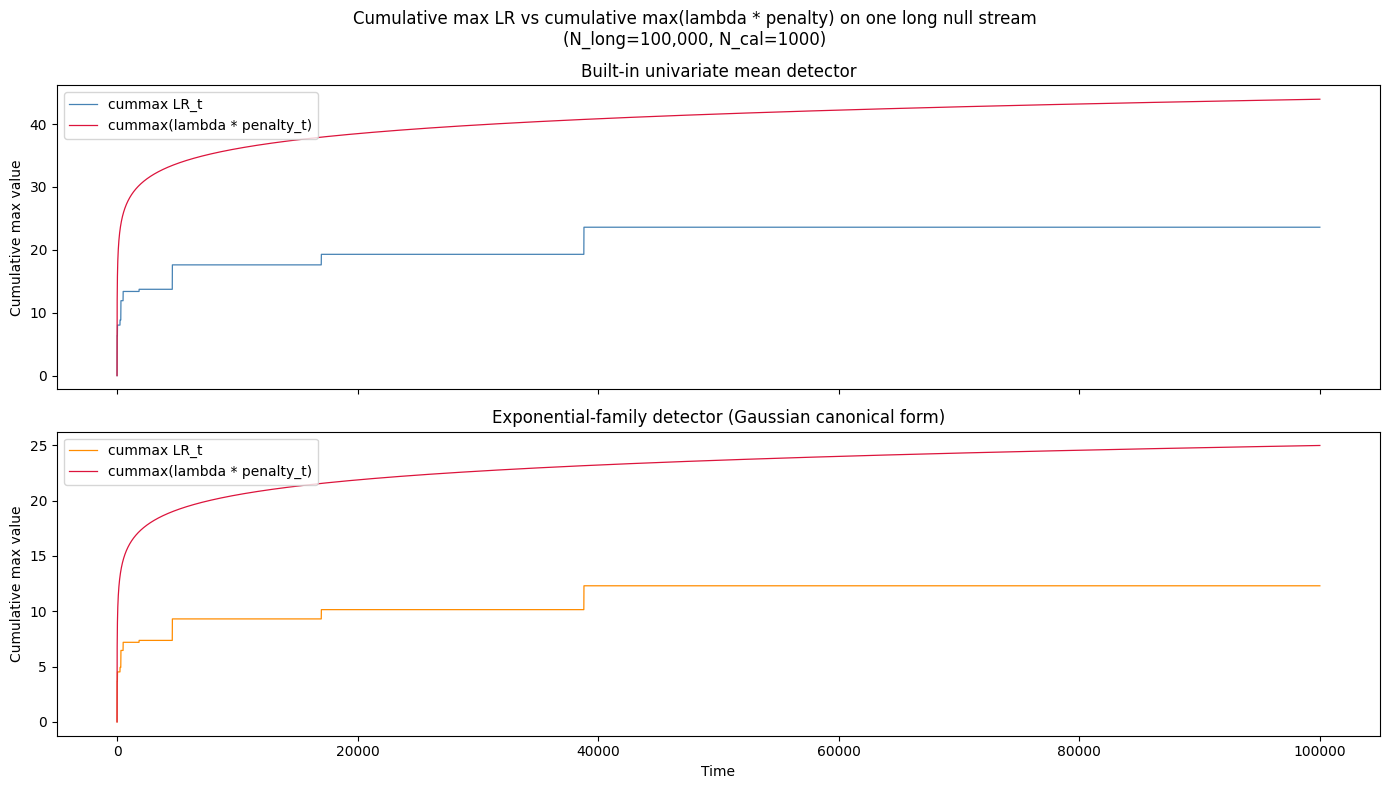


Built-in first alarm time:    None
Exp. family first alarm time: None
Stored monotone test statistic arrays:
  trace_builtin['stat_running'], trace_expfam['stat_running']


In [ ]:
time_axis = np.arange(1, N_LONG + 1)

# Use cumulative maxima so both lines are monotone increasing.
lr_builtin_max = trace_builtin.get("lr_running", np.maximum.accumulate(np.nan_to_num(trace_builtin["lr"], nan=0.0)))
thr_builtin_max = trace_builtin.get("threshold_running", np.maximum.accumulate(np.nan_to_num(trace_builtin["threshold"], nan=0.0)))

lr_expfam_max = trace_expfam.get("lr_running", np.maximum.accumulate(np.nan_to_num(trace_expfam["lr"], nan=0.0)))
thr_expfam_max = trace_expfam.get("threshold_running", np.maximum.accumulate(np.nan_to_num(trace_expfam["threshold"], nan=0.0)))

# --- Plot: cumulative maxima ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    f"Cumulative max f vs cumulative max(lambda * penalty) on one long null stream\n"
    f"(N_long={N_LONG:,}, N_cal={N_CAL})"
)

axes[0].plot(time_axis, lr_builtin_max, color="steelblue", linewidth=0.9, label="cummax LR_t")
axes[0].plot(time_axis, thr_builtin_max, color="crimson", linewidth=0.9, label="cummax(lambda * penalty_t)")
if trace_builtin["first_alarm"] is not None:
    axes[0].axvline(trace_builtin["first_alarm"], color="black", linestyle=":", linewidth=1.0)
axes[0].set_title("Built-in univariate mean detector")
axes[0].set_ylabel("Cumulative max value")
axes[0].legend(loc="upper left")

axes[1].plot(time_axis, lr_expfam_max, color="darkorange", linewidth=0.9, label="cummax LR_t")
axes[1].plot(time_axis, thr_expfam_max, color="crimson", linewidth=0.9, label="cummax(lambda * penalty_t)")
if trace_expfam["first_alarm"] is not None:
    axes[1].axvline(trace_expfam["first_alarm"], color="black", linestyle=":", linewidth=1.0)
axes[1].set_title("Exponential-family detector (Gaussian canonical form)")
axes[1].set_ylabel("Cumulative max value")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"\nBuilt-in first alarm time:    {trace_builtin['first_alarm']}")
print(f"Exp. family first alarm time: {trace_expfam['first_alarm']}")
print("Stored monotone test statistic arrays:")
print("  trace_builtin['stat_running'], trace_expfam['stat_running']")

**Simulation study: False alarm rate over time from repeated long null runs**

In [ ]:
# --- Settings ---
K_MC_NEW = 800          # Number of NEW streams to simulate this run
N_MC = 100_000
SEED_MC = 20260317
ALPHA_TARGET = 0.05
APPEND = True          # False = overwrite existing results, True = append to existing results

In [ ]:
# -----------------------------------------------------------
# Simulation study: Monte Carlo false alarm control (built-in only)
# Full-pass simulation with disk-backed storage for plot variables
# Supports incremental runs: new results are appended to existing ones.
# -----------------------------------------------------------

import json
import numpy as np
from pathlib import Path
from time import perf_counter



# Calibration for this FAR experiment
N_CAL_FAR = 1_000
K_CAL_FAR = 2_000

# FAR checkpoints
T_CHECK = np.array([1_000, 2_000, 5_000, 10_000, 50_000, 100_000], dtype=np.int64)
T_CHECK = T_CHECK[T_CHECK <= N_MC]

# --- Output paths ---
results_dir = Path("results") / "mc_far_builtin"
results_dir.mkdir(parents=True, exist_ok=True)
stat_paths_file  = results_dir / "stat_paths.npy"
summary_file     = results_dir / "mc_far_summary.npz"
meta_file        = results_dir / "mc_far_meta.json"
alarm_times_file = results_dir / "first_alarm_times_partial.npy"

# --- Check for existing run ---
if APPEND and meta_file.exists():
    meta_prev = json.loads(meta_file.read_text())
    K_MC_prev = meta_prev["shape"][0]
    N_MC_prev = meta_prev["shape"][1]
    assert N_MC_prev == N_MC, (
        f"N_MC mismatch: existing run has N_MC={N_MC_prev}, current N_MC={N_MC}. "
        "Cannot append runs with different stream lengths."
    )
    print(f"Found existing run with K={K_MC_prev} streams. Appending {K_MC_NEW} new streams.")
    first_alarm_times_prev = np.load(alarm_times_file)
    assert len(first_alarm_times_prev) == K_MC_prev
    stat_paths_prev = np.load(stat_paths_file, mmap_mode="r")
else:
    if not APPEND and meta_file.exists():
        print(f"APPEND=False: overwriting existing results in {results_dir}.")
    else:
        print(f"No existing run found. Starting fresh with {K_MC_NEW} streams.")
    K_MC_prev = 0
    first_alarm_times_prev = np.empty(0, dtype=np.int64)
    stat_paths_prev = None

K_MC_TOTAL = K_MC_prev + K_MC_NEW

# --- Build and calibrate built-in detector ---
det_builtin_far = make_univariate_mean_change_detector()
det_builtin_far.calibrate_false_alarm(
    alpha=ALPHA_TARGET,
    N=N_CAL_FAR,
    K=K_CAL_FAR,
    null_dist=np.random.normal,
    null_kwargs={"loc": 0.0, "scale": 1.0},
)

lambda_far = det_builtin_far.penalty_constant
print(f"Built-in lambda (N_cal={N_CAL_FAR}): {lambda_far:.4f}")

# --- Create new memmap with full size, copy old data in chunks ---
stat_paths_new_file = results_dir / "stat_paths_new.npy"
stat_paths = np.lib.format.open_memmap(
    stat_paths_new_file,
    mode="w+",
    dtype=np.float32,
    shape=(K_MC_TOTAL, N_MC),
)
if stat_paths_prev is not None:
    chunk_size = 50
    for start_row in range(0, K_MC_prev, chunk_size):
        end_row = min(start_row + chunk_size, K_MC_prev)
        stat_paths[start_row:end_row, :] = stat_paths_prev[start_row:end_row, :]
    stat_paths.flush()
    del stat_paths_prev

# --- First alarm times: allocate full array, copy old ---
first_alarm_times = np.full(K_MC_TOTAL, N_MC + 1, dtype=np.int64)
if K_MC_prev > 0:
    first_alarm_times[:K_MC_prev] = first_alarm_times_prev

# --- Monte Carlo: simulate only new streams ---
rng_mc = np.random.default_rng(SEED_MC + K_MC_prev)  # offset seed so new streams differ

start = perf_counter()
for k_new in range(K_MC_NEW):
    k = K_MC_prev + k_new
    x_null = rng_mc.normal(0.0, 1.0, N_MC)
    det_builtin_far.reset()

    t_alarm = N_MC + 1
    for i, x in enumerate(x_null, start=1):
        det_builtin_far.update(x)
        stat_paths[k, i - 1] = det_builtin_far.max_statistic

        if t_alarm == N_MC + 1 and det_builtin_far.alarm:
            t_alarm = i

    first_alarm_times[k] = t_alarm

    if (k_new + 1) % 25 == 0:
        stat_paths.flush()
        np.save(alarm_times_file, first_alarm_times[:k + 1])
        print(f"Completed {k_new + 1}/{K_MC_NEW} new streams ({k + 1} total)")

stat_paths.flush()
np.save(alarm_times_file, first_alarm_times)
elapsed_mc = perf_counter() - start
print(f"New streams runtime: {elapsed_mc:.2f} seconds")

# --- Atomic swap: replace old stat_paths file with new ---
stat_paths_file.unlink(missing_ok=True)
stat_paths_new_file.rename(stat_paths_file)

# --- FAR summaries ---
far_at_checkpoints = np.array(
    [np.mean(first_alarm_times <= t_check) for t_check in T_CHECK],
    dtype=np.float64,
)

time_mc = np.arange(1, N_MC + 1)
alarmed = first_alarm_times[first_alarm_times <= N_MC]
counts = np.bincount(alarmed - 1, minlength=N_MC) if len(alarmed) > 0 else np.zeros(N_MC, dtype=np.int64)
far_t_builtin = np.cumsum(counts) / K_MC_TOTAL
far_final_builtin = far_t_builtin[-1]

stat_paths_loaded = np.load(stat_paths_file, mmap_mode="r")
final_max_stats = np.array(stat_paths_loaded[:, -1], dtype=np.float64)
mean_stat_path  = np.array(np.mean(stat_paths_loaded, axis=0), dtype=np.float64)
del stat_paths_loaded

# --- Save summary ---
np.savez_compressed(
    summary_file,
    first_alarm_times=first_alarm_times,
    T_CHECK=T_CHECK,
    far_at_checkpoints=far_at_checkpoints,
    time_mc=time_mc,
    far_t_builtin=far_t_builtin,
    final_max_stats=final_max_stats,
    mean_stat_path=mean_stat_path,
    lambda_far=np.array([lambda_far], dtype=np.float64),
    alpha_target=np.array([ALPHA_TARGET], dtype=np.float64),
    K_MC=np.array([K_MC_TOTAL], dtype=np.int64),
    N_MC=np.array([N_MC], dtype=np.int64),
    N_CAL_FAR=np.array([N_CAL_FAR], dtype=np.int64),
)

meta_payload = {
    "stat_paths_file": str(stat_paths_file),
    "summary_file": str(summary_file),
    "shape": [int(K_MC_TOTAL), int(N_MC)],
    "dtype": "float32",
    "note": "Use np.load(stat_paths_file, mmap_mode='r') to read without loading whole array into RAM."
}
meta_file.write_text(json.dumps(meta_payload, indent=2))

print(f"Total streams: {K_MC_TOTAL}")
print(f"Saved stream paths to: {stat_paths_file}")
print(f"Saved summary arrays to: {summary_file}")
print(f"Saved metadata to: {meta_file}")

Found existing run with K=200 streams. Appending 800 new streams.
Built-in lambda (N_cal=1000): 2.9488
Completed 25/800 new streams (225 total)
Completed 50/800 new streams (250 total)
Completed 75/800 new streams (275 total)
Completed 100/800 new streams (300 total)
Completed 125/800 new streams (325 total)
Completed 150/800 new streams (350 total)
Completed 175/800 new streams (375 total)
Completed 200/800 new streams (400 total)
Completed 225/800 new streams (425 total)
Completed 250/800 new streams (450 total)
Completed 275/800 new streams (475 total)
Completed 300/800 new streams (500 total)
Completed 325/800 new streams (525 total)
Completed 350/800 new streams (550 total)
Completed 375/800 new streams (575 total)
Completed 400/800 new streams (600 total)
Completed 425/800 new streams (625 total)
Completed 450/800 new streams (650 total)
Completed 475/800 new streams (675 total)
Completed 500/800 new streams (700 total)
Completed 525/800 new streams (725 total)
Completed 550/800 

In [ ]:
# Optional recovery cell: run this if kernel restarted and you want to re-plot without re-simulating.
from pathlib import Path
import numpy as np

def _human_size(n_bytes: int) -> str:
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(n_bytes)
    for unit in units:
        if size < 1024.0 or unit == units[-1]:
            return f"{size:.2f} {unit}"
        size /= 1024.0

results_dir = Path("results") / "mc_far_builtin"
stat_paths_file = results_dir / "stat_paths.npy"
summary_file = results_dir / "mc_far_summary.npz"

if stat_paths_file.exists() and summary_file.exists():
    stat_paths_size = stat_paths_file.stat().st_size
    summary_size = summary_file.stat().st_size

    stat_paths = np.load(stat_paths_file, mmap_mode="r")
    summary = np.load(summary_file)

    first_alarm_times = summary["first_alarm_times"]
    T_CHECK = summary["T_CHECK"]
    far_at_checkpoints = summary["far_at_checkpoints"]
    time_mc = summary["time_mc"]
    far_t_builtin = summary["far_t_builtin"]
    final_max_stats = summary["final_max_stats"]
    mean_stat_path = summary["mean_stat_path"]
    lambda_far = float(summary["lambda_far"][0])
    ALPHA_TARGET = float(summary["alpha_target"][0])
    K_MC = int(summary["K_MC"][0])
    N_MC = int(summary["N_MC"][0])
    far_final_builtin = float(far_t_builtin[-1])

    print(f"Recovered arrays from {results_dir}")
    print(f"stat_paths shape: {stat_paths.shape}, dtype: {stat_paths.dtype}")
    print(f"stat_paths file size: {_human_size(stat_paths_size)} ({stat_paths_size:,} bytes)")
    print(f"summary file size:   {_human_size(summary_size)} ({summary_size:,} bytes)")
else:
    print("Saved files not found yet. Run the Monte Carlo simulation cell first.")

Recovered arrays from results/mc_far_builtin
stat_paths shape: (200, 100000), dtype: float32
stat_paths file size: 76.29 MB (80,000,128 bytes)
summary file size:   155.77 KB (159,507 bytes)


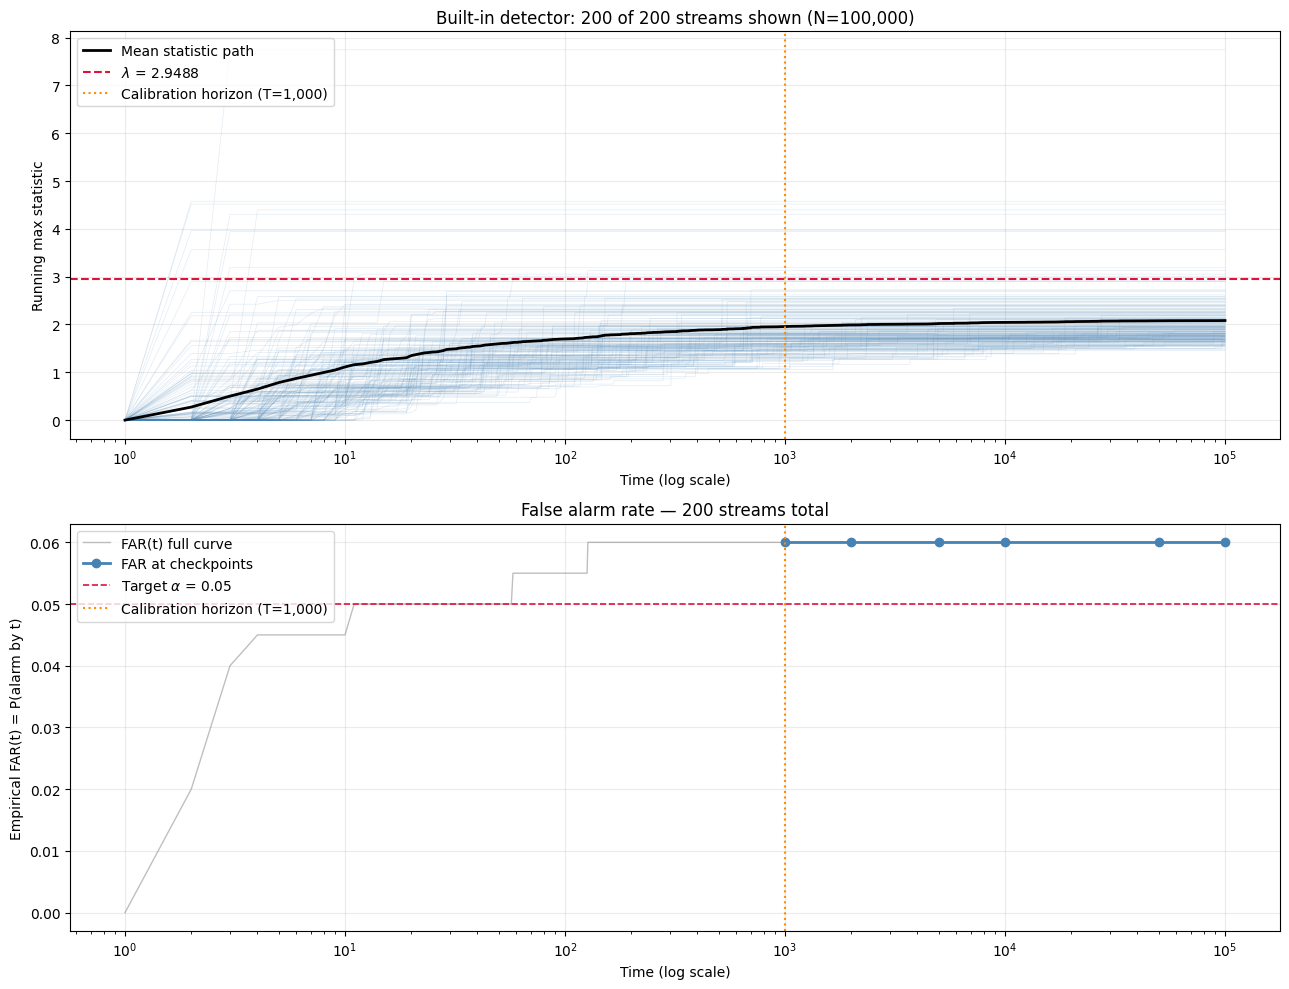


Final FAR at t=100,000: 0.0600

FAR at checkpoints:
  t=  1,000: FAR=0.0600 (12/200)
  t=  2,000: FAR=0.0600 (12/200)
  t=  5,000: FAR=0.0600 (12/200)
  t= 10,000: FAR=0.0600 (12/200)
  t= 50,000: FAR=0.0600 (12/200)
  t=100,000: FAR=0.0600 (12/200)


In [ ]:
# --- Plot settings ---
MAX_STREAMS_TO_PLOT = 200  # cap individual paths for readability at large K
plot_indices = (
    np.random.choice(K_MC_TOTAL, size=MAX_STREAMS_TO_PLOT, replace=False)
    if K_MC_TOTAL > MAX_STREAMS_TO_PLOT
    else np.arange(K_MC_TOTAL)
)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# --- Plot 1: sampled max statistic streams ---
stat_paths_mm = np.load(stat_paths_file, mmap_mode="r")
for k in plot_indices:
    axes[0].semilogx(time_mc, stat_paths_mm[k], color="steelblue", alpha=0.15, linewidth=0.5)
del stat_paths_mm

axes[0].semilogx(time_mc, mean_stat_path, color="black", linewidth=2.0, label="Mean statistic path")
axes[0].axhline(lambda_far, color="crimson", linestyle="--", linewidth=1.5, label=f"$\\lambda$ = {lambda_far:.4f}")
axes[0].axvline(N_CAL_FAR, color="darkorange", linestyle=":", linewidth=1.5, label=f"Calibration horizon (T={N_CAL_FAR:,})")
axes[0].set_xlabel("Time (log scale)")
axes[0].set_ylabel("Running max statistic")
axes[0].set_title(f"Built-in detector: {len(plot_indices)} of {K_MC_TOTAL} streams shown (N={N_MC:,})")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left")

# --- Plot 2: FAR curve ---
axes[1].semilogx(time_mc, far_t_builtin, color="gray", linewidth=1.0, alpha=0.5, label="FAR(t) full curve")
axes[1].semilogx(T_CHECK, far_at_checkpoints, color="steelblue", marker="o", linewidth=2.0, label="FAR at checkpoints")
axes[1].axhline(ALPHA_TARGET, color="crimson", linestyle="--", linewidth=1.2, label=f"Target $\\alpha$ = {ALPHA_TARGET}")
axes[1].axvline(N_CAL_FAR, color="darkorange", linestyle=":", linewidth=1.5, label=f"Calibration horizon (T={N_CAL_FAR:,})")
axes[1].set_xlabel("Time (log scale)")
axes[1].set_ylabel("Empirical FAR(t) = P(alarm by t)")
axes[1].set_title(f"False alarm rate — {K_MC_TOTAL} streams total")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nFinal FAR at t={N_MC:,}: {far_final_builtin:.4f}")
print("\nFAR at checkpoints:")
for t_check, far_val in zip(T_CHECK, far_at_checkpoints):
    n_alarm = int(np.sum(first_alarm_times <= t_check))
    print(f"  t={t_check:>7,}: FAR={far_val:.4f} ({n_alarm}/{K_MC_TOTAL})")

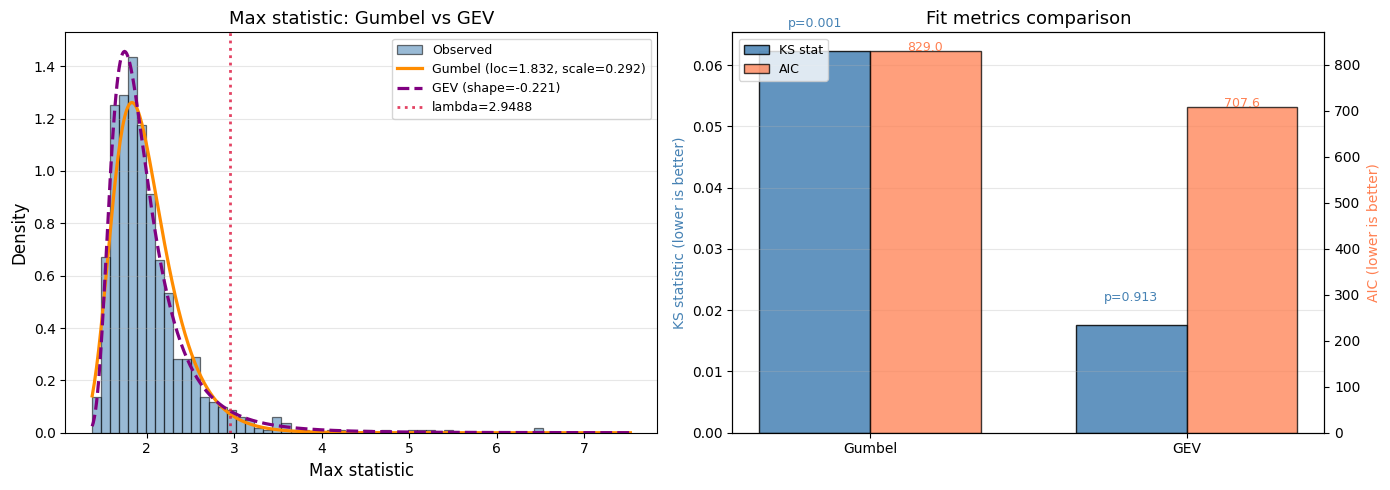


GUMBEL vs GEV COMPARISON
Gumbel: KS=0.062249, p=0.000822, AIC=828.98
GEV:    KS=0.017535, p=0.912796, AIC=707.58
Best by KS:  GEV
Best by AIC: GEV
--------------------------------------------------------------
GEV params: shape=-0.221055, loc=1.797778, scale=0.258337
Note: shape near 0 implies GEV is close to Gumbel.


In [ ]:
# --- Plot 6: Gumbel vs GEV fit for max statistic ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (50 bins)
x_range = np.linspace(final_max_stats.min(), final_max_stats.max() + 1.0, 500)
axes[0].hist(
    final_max_stats,
    bins=50,
    density=True,
    color="steelblue",
    alpha=0.55,
    edgecolor="black",
    linewidth=0.9,
    label="Observed",
)

# Fit Gumbel (GEV with xi = 0)
loc_g, scale_g = stats.gumbel_r.fit(final_max_stats)
pdf_g = stats.gumbel_r.pdf(x_range, loc=loc_g, scale=scale_g)

# Fit full GEV
shape_gev, loc_gev, scale_gev = stats.genextreme.fit(final_max_stats)
pdf_gev = stats.genextreme.pdf(x_range, shape_gev, loc=loc_gev, scale=scale_gev)

axes[0].plot(
    x_range,
    pdf_g,
    color="darkorange",
    linewidth=2.3,
    label=f"Gumbel (loc={loc_g:.3f}, scale={scale_g:.3f})",
)
axes[0].plot(
    x_range,
    pdf_gev,
    color="purple",
    linewidth=2.3,
    linestyle="--",
    label=f"GEV (shape={shape_gev:.3f})",
)

axes[0].axvline(lambda_far, color="crimson", linestyle=":", linewidth=2.0, alpha=0.8, label=f"lambda={lambda_far:.4f}")
axes[0].set_title("Max statistic: Gumbel vs GEV", fontsize=13)
axes[0].set_xlabel("Max statistic", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# Goodness-of-fit metrics
ks_g = stats.kstest(final_max_stats, lambda x: stats.gumbel_r.cdf(x, loc=loc_g, scale=scale_g))
ks_gev = stats.kstest(final_max_stats, lambda x: stats.genextreme.cdf(x, shape_gev, loc=loc_gev, scale=scale_gev))

pdf_vals_g = stats.gumbel_r.pdf(final_max_stats, loc=loc_g, scale=scale_g)
pdf_vals_gev = stats.genextreme.pdf(final_max_stats, shape_gev, loc=loc_gev, scale=scale_gev)
ll_g = np.sum(np.log(np.clip(pdf_vals_g, 1e-300, None)))
ll_gev = np.sum(np.log(np.clip(pdf_vals_gev, 1e-300, None)))
aic_g = 2 * 2 - 2 * ll_g      # params: loc, scale
aic_gev = 2 * 3 - 2 * ll_gev  # params: shape, loc, scale

# Bar comparison panel
labels = ["Gumbel", "GEV"]
ks_vals = [ks_g.statistic, ks_gev.statistic]
aic_vals = [aic_g, aic_gev]
x = np.arange(len(labels))
width = 0.35

bars1 = axes[1].bar(x - width / 2, ks_vals, width=width, color="steelblue", alpha=0.85, edgecolor="black", label="KS stat")
ax2 = axes[1].twinx()
bars2 = ax2.bar(x + width / 2, aic_vals, width=width, color="coral", alpha=0.75, edgecolor="black", label="AIC")

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("KS statistic (lower is better)", color="steelblue")
ax2.set_ylabel("AIC (lower is better)", color="coral")
axes[1].set_title("Fit metrics comparison", fontsize=13)
axes[1].grid(axis="y", alpha=0.3)

for i, pval in enumerate([ks_g.pvalue, ks_gev.pvalue]):
    axes[1].text(i - width / 2, ks_vals[i] + 0.004, f"p={pval:.3f}", ha="center", fontsize=9, color="steelblue")
for i, val in enumerate(aic_vals):
    ax2.text(i + width / 2, val + 1.0, f"{val:.1f}", ha="center", fontsize=9, color="coral")

h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

best_ks = "GEV" if ks_gev.statistic < ks_g.statistic else "Gumbel"
best_aic = "GEV" if aic_gev < aic_g else "Gumbel"

print("\n" + "=" * 62)
print("GUMBEL vs GEV COMPARISON")
print("=" * 62)
print(f"Gumbel: KS={ks_g.statistic:.6f}, p={ks_g.pvalue:.6f}, AIC={aic_g:.2f}")
print(f"GEV:    KS={ks_gev.statistic:.6f}, p={ks_gev.pvalue:.6f}, AIC={aic_gev:.2f}")
print(f"Best by KS:  {best_ks}")
print(f"Best by AIC: {best_aic}")
print("-" * 62)
print(f"GEV params: shape={shape_gev:.6f}, loc={loc_gev:.6f}, scale={scale_gev:.6f}")
print("Note: shape near 0 implies GEV is close to Gumbel.")
print("=" * 62)

# OLD GLR SECTION:

## 1. General GLR framework for exponential families

The test is fixed; only MLE computation changes:
$$\Lambda = \ell(\hat\theta_1; \text{pre}) + \ell(\hat\theta_2; \text{post}) - \ell(\hat\theta_0; \text{all}).$$

This notebook first builds general numerical solvers for $\hat\theta$ and then benchmarks exact closed-form implementations (when available) as baselines.

### 1.1 Exponential family definitions

We define two example families: **Gaussian** ($\theta = \mu$, $A(\theta)=\theta^2/2$, $h(y)=y$) and **Bernoulli** ($\theta = \text{logit}(p)$, $A(\theta) = \log(1+e^\theta)$, $h(y)=y$).

For each we provide: $h$, $A$, $\nabla A$, $\nabla^2 A$, the inverse link $(\nabla A)^{-1}$, a log-likelihood function, and a penalty.

In [ ]:
# =====================================================================
# Exponential family definitions — Gaussian & Bernoulli
# =====================================================================

# ─── Gaussian (known variance σ²=1) ────────────────────────────────
# Natural parameter θ = μ, h(y) = y, A(θ) = θ²/2

V_GAUSS = 1

@nb.njit
def h_gauss(y):
    return y

@nb.njit
def A_gauss(theta):
    """Log-partition for N(θ,1): A(θ) = θ²/2."""
    return 0.5 * np.dot(theta, theta)

@nb.njit
def grad_A_gauss(theta):
    """∇A(θ) = θ."""
    return theta.copy()

@nb.njit
def hess_A_gauss(theta):
    """∇²A(θ) = I."""
    v = theta.shape[0]
    return np.eye(v)

@nb.njit
def grad_A_inv_gauss(mu):
    """Inverse link for Gaussian: identity."""
    return mu.copy()

@nb.njit
def loglik_gauss(theta, S, n):
    """ℓ(θ) = θᵀS − n·A(θ) for Gaussian."""
    return np.dot(theta, S) - n * A_gauss(theta)

# ─── Bernoulli ─────────────────────────────────────────────────────
# Natural parameter θ = logit(p), h(y) = y, A(θ) = log(1+eθ)

V_BERN = 1

@nb.njit
def h_bern(y):
    """Sufficient statistic for Bernoulli: h(y) = y."""
    return y

@nb.njit
def A_bern(theta):
    """Log-partition for Bernoulli: A(θ) = log(1 + exp(θ))."""
    return np.log(1.0 + np.exp(theta)).sum()

@nb.njit
def grad_A_inv_bern(mu):
    """Inverse link (logit): θ = log(μ/(1−μ))."""
    return np.log(mu / (1.0 - mu))

@nb.njit
def grad_A_bern(theta):
    """∇A = sigmoid(θ)."""
    ee = np.exp(theta)
    return ee / (1.0 + ee)

@nb.njit
def hess_A_bern(theta):
    """∇²A for Bernoulli."""
    ee = np.exp(theta)
    H = np.zeros((1, 1), dtype=np.float64)
    H[0, 0] = (ee / ((1.0 + ee) ** 2)).sum()
    return H

@nb.njit
def loglik_bern(theta, S, n):
    """ℓ(θ) = θᵀS − n·A(θ) for Bernoulli."""
    return np.dot(theta, S) - n * A_bern(theta)

# ─── Penalty functions (same for all MLE methods) ─────────────────

@nb.njit
def penalty_glr_gauss(pos, t, p):
    logt = fastlog(t)
    return math.sqrt(V_GAUSS * logt) + logt

@nb.njit
def penalty_glr_bern(g, t, p):
    logt = fastlog(t)
    return math.sqrt(V_BERN * logt) + logt

print("Exponential family definitions compiled.")

Exponential family definitions compiled.


### 1.2 Exact baselines (for known families only)

These closed-form MLE implementations are included as **reference baselines** for distributions where $(\nabla A)^{-1}$ is explicit:
- **Gaussian:** $\hat\theta = S/n$
- **Bernoulli:** $\hat\theta = \mathrm{logit}(S/n)$

In [ ]:
# =====================================================================
# Closed-form MLE — when (∇A)⁻¹ is available analytically
# =====================================================================

EPS = 1e-8  # clamping for boundary cases

# ─── Gaussian: θ̂ = S/n (sample mean = natural parameter) ─────────

@nb.njit
def closed_form_mle_gauss(S, n):
    return S / n

@nb.njit
def f_glr_gauss(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Gaussian using closed-form MLE."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_gauss(S_all, t)
    theta1 = closed_form_mle_gauss(sum_pre_j, n1)
    theta2 = closed_form_mle_gauss(sum_post_j, n2)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

# ─── Bernoulli: θ̂ = logit(S/n) ───────────────────────────────────

@nb.njit
def closed_form_mle_bern(S, n):
    """MLE via inverse link: θ̂ = (∇A)⁻¹(S/n) = logit(S/n)."""
    mu = S / n
    for i in range(mu.shape[0]):
        if mu[i] < EPS:
            mu[i] = EPS
        elif mu[i] > 1.0 - EPS:
            mu[i] = 1.0 - EPS
    return grad_A_inv_bern(mu)

@nb.njit
def f_glr_bern(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Bernoulli using closed-form MLE."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_bern(S_all, t)
    theta1 = closed_form_mle_bern(sum_pre_j, n1)
    theta2 = closed_form_mle_bern(sum_post_j, n2)
    ll0 = loglik_bern(theta0, S_all, t)
    ll1 = loglik_bern(theta1, sum_pre_j, n1)
    ll2 = loglik_bern(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

print("Closed-form MLEs compiled.")

Closed-form MLEs compiled.


### 1.3 General solver candidate A: Newton

Newton solves the score equation $\nabla A(\theta)=S/n$ and is the primary candidate for the default general implementation when Hessians are available and well-conditioned.

In [ ]:
# =====================================================================
# Solving the score equation via Newton's method
# =====================================================================
# For v=1: scalar root-finding on A'(θ) = S/n  (fast, no arrays)
# For any v: array-based Newton on ∇A(θ) = S/n  (slower, needs Hessian)

# ─── Scalar A, A', A'' for v=1 Newton ────────────────────────────

# Gaussian
@nb.njit
def A_scalar_gauss(theta):
    return 0.5 * theta * theta

@nb.njit
def A_prime_gauss(theta):
    return theta

@nb.njit
def A_dprime_gauss(theta):
    return 1.0

# Bernoulli
@nb.njit
def A_scalar_bern(theta):
    if theta > 30.0:
        return theta
    if theta < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(theta))

@nb.njit
def A_prime_bern(theta):
    if theta > 30.0:
        return 1.0
    if theta < -30.0:
        return 0.0
    e = math.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bern(theta):
    if abs(theta) > 30.0:
        return 0.0
    e = math.exp(theta)
    s = e / (1.0 + e)
    return s * (1.0 - s)

# ─── Generic scalar Newton MLE ───────────────────────────────────

@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    """Scalar Newton to solve A'(θ̂) = S/n.
    Pure scalar arithmetic, zero allocations."""
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta

@nb.njit
def scalar_loglik(theta, S_scalar, n, A_scalar):
    """Scalar log-likelihood θ·S − n·A(θ)."""
    return theta * S_scalar - n * A_scalar(theta)

# ─── Gaussian: scalar Newton GLR ─────────────────────────────────

@nb.njit
def f_glr_gauss_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Gaussian v=1."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre, s_post = sum_pre_j[0], sum_post_j[0]
    s_all = s_pre + s_post
    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_gauss, A_dprime_gauss)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_gauss, A_dprime_gauss)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_gauss, A_dprime_gauss)
    ll0 = scalar_loglik(th0, s_all, t, A_scalar_gauss)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_gauss)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_gauss)
    return ll1 + ll2 - ll0

# ─── Bernoulli: scalar Newton GLR ────────────────────────────────

@nb.njit
def f_glr_bern_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Bernoulli v=1."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre, s_post = sum_pre_j[0], sum_post_j[0]
    s_all = s_pre + s_post
    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_bern, A_dprime_bern)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_bern, A_dprime_bern)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_bern, A_dprime_bern)
    ll0 = scalar_loglik(th0, s_all, t, A_scalar_bern)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_bern)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_bern)
    return ll1 + ll2 - ll0

# ─── Array-based Newton (slow baseline, any v) ───────────────────
# Uses np.linalg.solve + Hessian.  Included for completeness.

@nb.njit
def newton_mle_gauss(S, n, theta_init, tol=1e-12, max_iter=100):
    """Array-based Newton MLE for Gaussian (slow baseline)."""
    theta = theta_init.copy()
    v = theta.shape[0]
    ridge = 1e-8
    ll_old = loglik_gauss(theta, S, n)
    for _ in range(max_iter):
        grad = S - n * grad_A_gauss(theta)
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta
        HA = hess_A_gauss(theta)
        H = -n * HA
        for i in range(v):
            H[i, i] -= ridge
        step = np.linalg.solve(H, grad)
        step_scale = 1.0
        for _ in range(6):
            theta_new = theta + step_scale * step
            ll_new = loglik_gauss(theta_new, S, n)
            if np.isfinite(ll_new) and ll_new >= ll_old:
                theta = theta_new
                ll_old = ll_new
                break
            step_scale *= 0.5
        else:
            theta = theta + step_scale * step
            ll_old = loglik_gauss(theta, S, n)
    return theta

@nb.njit
def f_glr_gauss_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with array-based Newton (slow baseline)."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0])
    theta0 = newton_mle_gauss(S_all, t, theta_init)
    theta1 = newton_mle_gauss(sum_pre_j, n1, theta0)
    theta2 = newton_mle_gauss(sum_post_j, n2, theta0)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

print("Newton solvers compiled.")

Newton solvers compiled.


### 1.4 General solver candidate B: Gradient Descent

Gradient methods need only $(A,\nabla A)$ and provide a robust fallback general solver when Newton is unstable or Hessians are unavailable.

In [ ]:
# =====================================================================
# General-purpose GD MLE for exponential families (any dim θ)
# =====================================================================
# Works with vector θ ∈ ℝᵛ and takes function pointers for the
# log-partition A(θ) and its gradient ∇A(θ).
#
# The GD method needs ONLY (A, grad_A) — no Hessian.

# ─── Gradient Descent with Armijo backtracking (general, any dim) ───

@nb.njit
def gd_mle(S, n, theta_init, A_fn, grad_A_fn, tol=1e-8, max_iter=50):
    """Gradient ascent with Armijo backtracking for array-valued θ.

    Maximizes ℓ(θ) = θᵀS − n·A(θ).
    Gradient: ∇ℓ = S − n·∇A(θ).

    Does not need the Hessian ∇²A — first-order only.

    Parameters
    ----------
    S : np.ndarray, shape (v,)   — sufficient statistic sum
    n : int                       — number of observations
    theta_init : np.ndarray (v,)  — starting point
    A_fn : callable(θ) -> float   — log-partition function
    grad_A_fn : callable(θ) -> ndarray(v,) — gradient of A
    tol : float       — convergence tolerance on ‖∇ℓ‖∞
    max_iter : int    — maximum gradient steps

    Returns
    -------
    theta : np.ndarray (v,) — approximate MLE
    """
    theta = theta_init.copy()
    v = theta.shape[0]
    ll = np.dot(theta, S) - n * A_fn(theta)
    c_armijo = 1e-4

    for _ in range(max_iter):
        grad = S - n * grad_A_fn(theta)

        # Check convergence: ‖grad‖∞ < tol
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta

        grad_sq = np.dot(grad, grad)

        # Backtracking line search (Armijo condition)
        eta = 1.0
        for _ in range(20):
            theta_new = theta + eta * grad
            ll_new = np.dot(theta_new, S) - n * A_fn(theta_new)
            if np.isfinite(ll_new) and ll_new >= ll + c_armijo * eta * grad_sq:
                theta = theta_new
                ll = ll_new
                break
            eta *= 0.5
        else:
            theta = theta + eta * grad
            ll = np.dot(theta, S) - n * A_fn(theta)

    return theta

# ─── Generic GLR f-function builder ─────────────────────────────────
# The _glr_stat helper computes the GLR given any MLE solver and A function.

@nb.njit
def _glr_stat(sum_pre_j, sum_post_j, pos, t, mle_fn, A_fn):
    """Core GLR statistic: ℓ(θ̂₁;seg1) + ℓ(θ̂₂;seg2) − ℓ(θ̂₀;all).
    mle_fn(S, n, theta_init) -> theta_hat  (partial application of optimizer)."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    v = sum_pre_j.shape[0]
    theta_init = np.zeros(v)

    theta0 = mle_fn(S_all, t, theta_init)
    theta1 = mle_fn(sum_pre_j, n1, theta0)
    theta2 = mle_fn(sum_post_j, n2, theta0)

    ll0 = np.dot(theta0, S_all) - t * A_fn(theta0)
    ll1 = np.dot(theta1, sum_pre_j) - n1 * A_fn(theta1)
    ll2 = np.dot(theta2, sum_post_j) - n2 * A_fn(theta2)
    return ll1 + ll2 - ll0

# =====================================================================
# Gaussian specializations (work for any v = dim(θ))
# h_gauss, A_gauss, grad_A_gauss defined in §2.1
# =====================================================================

@nb.njit
def _gd_mle_gauss(S, n, theta_init):
    return gd_mle(S, n, theta_init, A_gauss, grad_A_gauss)

@nb.njit
def f_glr_gauss_gd(sum_pre_j, sum_post_j, pos, t):
    """GLR with gradient descent for Gaussian (any dimension)."""
    return _glr_stat(sum_pre_j, sum_post_j, pos, t, _gd_mle_gauss, A_gauss)

# =====================================================================
# Bernoulli specializations (v=1, but using array form so it's general)
# =====================================================================

@nb.njit
def A_bern_vec(theta):
    """Log-partition for Bernoulli, takes array θ of shape (v,) with v=1."""
    t = theta[0]
    if t > 30.0:
        return t
    if t < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(t))

@nb.njit
def grad_A_bern_vec(theta):
    """∇A for Bernoulli (sigmoid), returns array of shape (1,)."""
    t = theta[0]
    out = np.empty(1)
    if t > 30.0:
        out[0] = 1.0
    elif t < -30.0:
        out[0] = 0.0
    else:
        e = math.exp(t)
        out[0] = e / (1.0 + e)
    return out

@nb.njit
def _gd_mle_bern(S, n, theta_init):
    return gd_mle(S, n, theta_init, A_bern_vec, grad_A_bern_vec)

@nb.njit
def f_glr_bern_gd(sum_pre_j, sum_post_j, pos, t):
    """GLR with gradient descent for Bernoulli."""
    return _glr_stat(sum_pre_j, sum_post_j, pos, t, _gd_mle_bern, A_bern_vec)

print("General GD MLE compiled (supports any dim θ).")

General GD MLE compiled (supports any dim θ).


### 1.5 General solver candidate C: L-BFGS (reference)

L-BFGS is included as a SciPy/Python-path reference solver for comparison. It is useful for validating optimization quality, but it does not run in the Numba-compiled fast path used by production detector loops.

In [ ]:
# =====================================================================
# L-BFGS reference solver (SciPy / Python path)
# =====================================================================

try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


def lbfgs_mle(S, n, theta_init, A_fn, grad_A_fn, max_iter=100):
    """Reference MLE solver using L-BFGS-B (Python path)."""
    S = np.asarray(S, dtype=np.float64)
    theta_init = np.asarray(theta_init, dtype=np.float64)

    def obj(theta):
        return n * A_fn(theta) - float(np.dot(theta, S))

    def grad(theta):
        return n * grad_A_fn(theta) - S

    res = minimize(
        obj,
        theta_init,
        jac=grad,
        method="L-BFGS-B",
        options={"maxiter": max_iter, "ftol": 1e-12},
    )
    if res.success and np.all(np.isfinite(res.x)):
        return res.x
    return theta_init


def _glr_stat_py(sum_pre_j, sum_post_j, pos, t, mle_fn, A_fn):
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0

    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0], dtype=np.float64)

    theta0 = mle_fn(S_all, t, theta_init)
    theta1 = mle_fn(sum_pre_j, n1, theta0)
    theta2 = mle_fn(sum_post_j, n2, theta0)

    ll0 = np.dot(theta0, S_all) - t * A_fn(theta0)
    ll1 = np.dot(theta1, sum_pre_j) - n1 * A_fn(theta1)
    ll2 = np.dot(theta2, sum_post_j) - n2 * A_fn(theta2)
    return float(ll1 + ll2 - ll0)


def _lbfgs_mle_gauss(S, n, theta_init):
    return lbfgs_mle(S, n, theta_init, A_gauss, grad_A_gauss)


def f_glr_gauss_lbfgs(sum_pre_j, sum_post_j, pos, t):
    return _glr_stat_py(sum_pre_j, sum_post_j, pos, t, _lbfgs_mle_gauss, A_gauss)


def _lbfgs_mle_bern(S, n, theta_init):
    return lbfgs_mle(S, n, theta_init, A_bern_vec, grad_A_bern_vec)


def f_glr_bern_lbfgs(sum_pre_j, sum_post_j, pos, t):
    return _glr_stat_py(sum_pre_j, sum_post_j, pos, t, _lbfgs_mle_bern, A_bern_vec)

print(f"L-BFGS reference ready. SciPy available: {SCIPY_AVAILABLE}")

## 2. Solver benchmarking for general GLR

We now benchmark general solver candidates (Newton, GD, L-BFGS reference) and compare against exact closed-form baselines on known families.

### 2.1 Gaussian: general solvers vs exact baselines

Primary comparison: general GLR solvers (Newton, GD, L-BFGS reference). Baselines: exact GLR closed-form and exact GLR CUSUM form.

In [ ]:
# =====================================================================
# Gaussian (v=1): general solvers first, exact baselines second
# =====================================================================
N_nvg = 200
K_cal_nvg = 5000
K_nvg = 1000
changepoint_nvg = N_nvg // 2

methods_gauss = {}

# 1) General GLR — Newton (primary candidate)
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["General GLR (Newton)"] = {
    "f": f_glr_gauss_scalar_newton, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) General GLR — gradient descent
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_gd, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["General GLR (GD)"] = {
    "f": f_glr_gauss_gd, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 3) General GLR — L-BFGS reference (Python path)
if SCIPY_AVAILABLE:
    det_tmp = OnlineChangepointDetector(
        p=1, f=f_glr_gauss_lbfgs, h=h_gauss,
        penalty=penalty_glr_gauss, penalty_constant=10.0,
    )
    det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=min(1000, K_cal_nvg), null_dist=np.random.normal)
    methods_gauss["General GLR (L-BFGS ref)"] = {
        "f": f_glr_gauss_lbfgs, "h": h_gauss, "penalty": penalty_glr_gauss,
        "pen_const": det_tmp._state["penalty_constant"],
    }

# 4) Exact GLR baseline — closed-form MLE
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["Exact GLR baseline (closed-form)"] = {
    "f": f_glr_gauss, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 5) Exact GLR baseline — CUSUM form
det_tmp = make_univariate_mean_change_detector()
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["Exact GLR baseline (CUSUM form)"] = {
    "pen_const": det_tmp._state["penalty_constant"], "make_det": "cusum",
}

print("Gaussian (v=1) — calibrated thresholds:")
for name, m in methods_gauss.items():
    print(f"  {name:<35s} λ = {m['pen_const']:.3f}")

# Generate test data: N(0,1) → N(2,1)
xs_nvg = draw_samples(
    K=K_nvg, N=N_nvg, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_nvg,
)

# --- Run all methods and time them ---
results_gauss = {}
for name, m in methods_gauss.items():
    dt = np.ones(K_nvg, dtype=np.int64) * N_nvg
    t0 = perf_counter()
    for k in range(K_nvg):
        if m.get("make_det") == "cusum":
            d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
        else:
            d = OnlineChangepointDetector(
                p=1, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
        for i in range(N_nvg):
            d.update(xs_nvg[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_gauss[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 68)
for name, r in results_gauss.items():
    delay = np.mean(r["dt"]) - changepoint_nvg
    det_rate = np.mean(r["dt"] < N_nvg)
    print(f"{name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

Gaussian (v=1) — calibrated thresholds:
  Closed-form GLR           λ = 1.410
  Scalar Newton GLR         λ = 1.410
  Gradient Descent GLR      λ = 1.410
  Built-in CUSUM            λ = 2.963

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Closed-form GLR                  1.8      1.000       2.08
Scalar Newton GLR                1.8      1.000       1.86
Gradient Descent GLR             1.8      1.000      26.12
Built-in CUSUM                   3.1      1.000       1.84


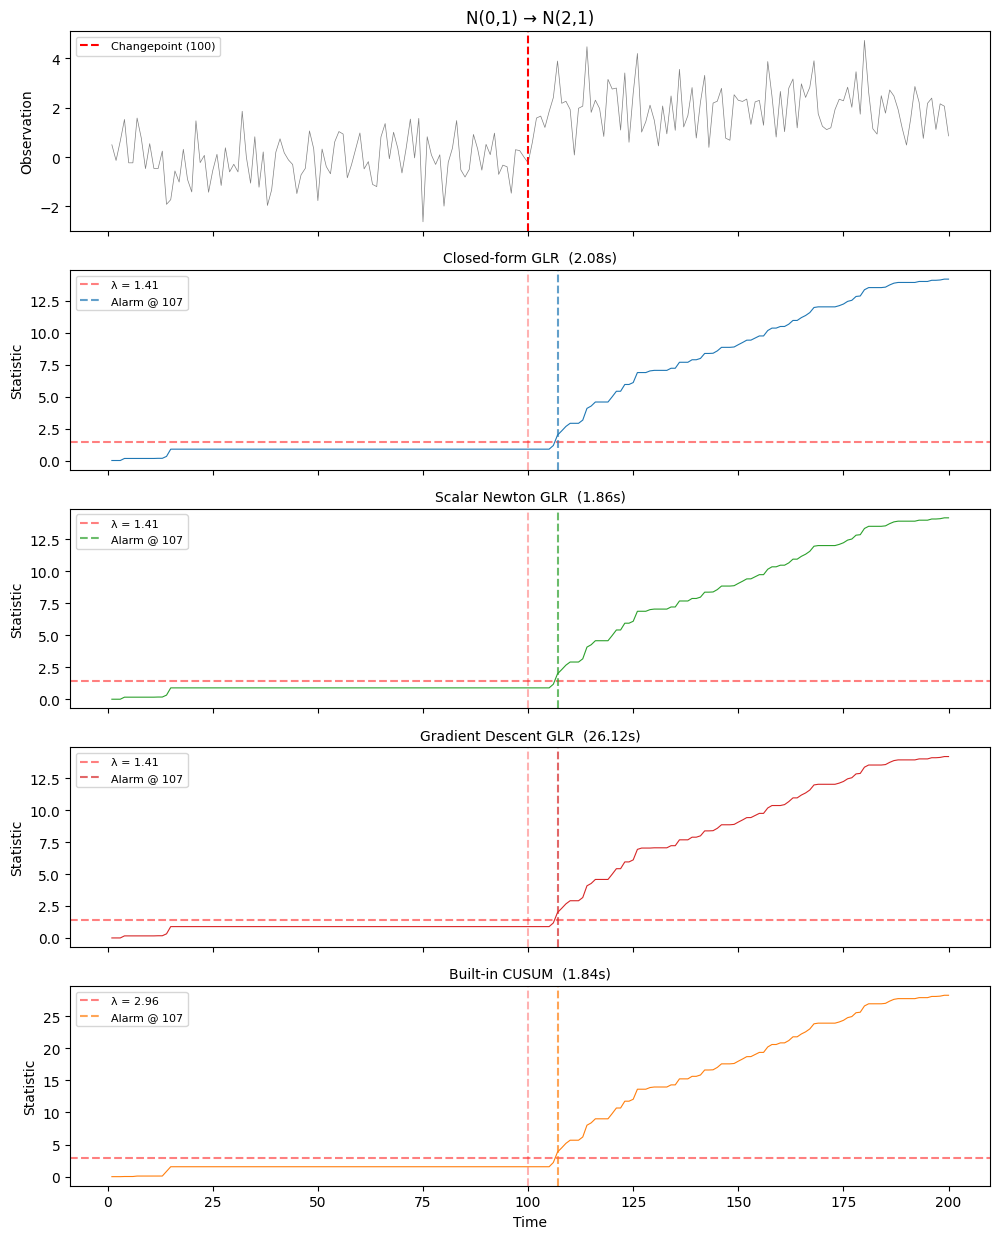

In [ ]:
# Visualize all methods on a single stream
stream = xs_nvg[0]
method_names_g = list(methods_gauss.keys())
n_methods = len(method_names_g)

color_map_g = {
    "General GLR (Newton)": "tab:green",
    "General GLR (GD)": "tab:red",
    "General GLR (L-BFGS ref)": "tab:purple",
    "Exact GLR baseline (closed-form)": "tab:blue",
    "Exact GLR baseline (CUSUM form)": "tab:orange",
}

fig, axes = plt.subplots(n_methods + 1, 1,
                         figsize=(10, 2.5 * (n_methods + 1)), sharex=True)

# Top panel: data
axes[0].plot(np.arange(1, N_nvg + 1), stream[:, 0], linewidth=0.5, color="gray")
axes[0].axvline(changepoint_nvg, color="red", ls="--",
                label=f"Changepoint ({changepoint_nvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(fontsize=8)
axes[0].set_title("N(0,1) → N(2,1)")

for idx, name in enumerate(method_names_g):
    m = methods_gauss[name]
    if m.get("make_det") == "cusum":
        d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
    else:
        d = OnlineChangepointDetector(
            p=1, f=m["f"], h=m["h"],
            penalty=m["penalty"], penalty_constant=m["pen_const"],
        )
    st = np.zeros(N_nvg)
    alarm = None
    for i in range(N_nvg):
        d.update(stream[i])
        st[i] = d.max_statistic
        if d.alarm and alarm is None:
            alarm = i + 1
    color = color_map_g.get(name, "gray")
    ax = axes[idx + 1]
    ax.plot(np.arange(1, N_nvg + 1), np.maximum(st, 1e-6),
            linewidth=0.8, color=color)
    ax.axhline(m["pen_const"], color="red", ls="--", alpha=0.5,
               label=f"λ = {m['pen_const']:.2f}")
    ax.axvline(changepoint_nvg, color="red", ls="--", alpha=0.3)
    if alarm:
        ax.axvline(alarm, color=color, ls="--", alpha=0.7,
                   label=f"Alarm @ {alarm}")
    ax.set_ylabel("Statistic")
    ax.set_title(f"{name}  ({results_gauss[name]['time']:.2f}s)", fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### 2.2 Bernoulli: general solvers vs exact baseline

In [ ]:
# =====================================================================
# Bernoulli: general solvers first, exact baseline second
# =====================================================================
N_nvb = 200
K_cal_nvb = 5000
K_nvb = 1000
changepoint_nvb = N_nvb // 2

methods_bern = {}

# 1) General GLR — Newton (primary candidate)
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern_scalar_newton, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["General GLR (Newton)"] = {
    "f": f_glr_bern_scalar_newton, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) General GLR — gradient descent
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern_gd, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["General GLR (GD)"] = {
    "f": f_glr_bern_gd, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 3) General GLR — L-BFGS reference (Python path)
if SCIPY_AVAILABLE:
    det_tmp = OnlineChangepointDetector(
        p=1, f=f_glr_bern_lbfgs, h=h_bern,
        penalty=penalty_glr_bern, penalty_constant=10.0,
    )
    det_tmp.calibrate_false_alarm(
        alpha=0.05, N=N_nvb, K=min(1000, K_cal_nvb),
        null_dist=np.random.binomial,
        null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
    )
    methods_bern["General GLR (L-BFGS ref)"] = {
        "f": f_glr_bern_lbfgs, "h": h_bern, "penalty": penalty_glr_bern,
        "pen_const": det_tmp._state["penalty_constant"],
    }

# 4) Exact GLR baseline — closed-form MLE
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["Exact GLR baseline (closed-form)"] = {
    "f": f_glr_bern, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

print("Bernoulli — calibrated thresholds:")
for name, m in methods_bern.items():
    print(f"  {name:<35s} λ = {m['pen_const']:.3f}")

# Generate test data: Bernoulli(0.3) → Bernoulli(0.7)
xs_nvb = draw_samples(
    K=K_nvb, N=N_nvb, p=1, seed=42,
    pre_change_dist=np.random.binomial,
    pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
    post_change_dist=np.random.binomial,
    post_change_kwargs={"n": 1, "p": 0.7, "size": (1,)},
    changepoint_loc=changepoint_nvb,
)

# --- Run all methods and time them ---
results_bern = {}
for name, m in methods_bern.items():
    dt = np.ones(K_nvb, dtype=np.int64) * N_nvb
    t0 = perf_counter()
    for k in range(K_nvb):
        d = OnlineChangepointDetector(
            p=1, f=m["f"], h=m["h"],
            penalty=m["penalty"], penalty_constant=m["pen_const"],
        )
        for i in range(N_nvb):
            d.update(xs_nvb[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_bern[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 68)
for name, r in results_bern.items():
    delay = np.mean(r["dt"]) - changepoint_nvb
    det_rate = np.mean(r["dt"] < N_nvb)
    print(f"{name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

Bernoulli — calibrated thresholds:
  Scalar Newton GLR         λ = 1.431
  Gradient Descent GLR      λ = 1.403

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Scalar Newton GLR               45.1      0.889       3.11
Gradient Descent GLR            43.0      0.901       6.55


### 2.2b Exact baseline reference: Gaussian CUSUM form

This section is an exact baseline only. For Gaussian mean change, CUSUM is algebraically equivalent to the exact GLR after closed-form simplification.

In [ ]:
# Exact baseline CUSUM implementation (Gaussian mean-change)

@nb.njit
def h_cusum(y):
    return y


@nb.njit
def f_cusum(sum_pre_j, sum_post_j, g, t):
    res = math.sqrt(1.0 * g / (t * (t - g))) * sum_pre_j
    res = res - math.sqrt(1.0 * (t - g) / t / g) * sum_post_j
    return np.sum(res * res)


@nb.njit
def penalty_cusum(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg
    return rr


# Quick baseline check
detector_cusum = OnlineChangepointDetector(
    p=1, f=f_cusum, h=h_cusum, penalty=penalty_cusum, penalty_constant=10
)
detector_cusum.calibrate_false_alarm(alpha=0.05, N=1000, K=1000, null_dist=np.random.normal)

N_cus = 1000
changepoint_cus = 500
K_cus = 1000

xs_cus = draw_samples(
    K=K_cus, N=N_cus, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_cus,
)

pen_const_cus = detector_cusum._state["penalty_constant"]
detect_times_cus = np.ones(K_cus, dtype=np.int64) * N_cus
for k in range(K_cus):
    det = OnlineChangepointDetector(
        p=1, f=f_cusum, h=h_cusum,
        penalty=penalty_cusum, penalty_constant=pen_const_cus,
    )
    for i in range(N_cus):
        det.update(xs_cus[k, i])
        if det.alarm:
            detect_times_cus[k] = i + 1
            break

print(f"CUSUM baseline — Average detection delay: {np.mean(detect_times_cus) - changepoint_cus:.1f}")
print(f"CUSUM baseline — Proportion detected: {np.mean(detect_times_cus < N_cus):.3f}")

### 2.3 Detection delay vs change magnitude

In [ ]:
# =====================================================================
# Gaussian: Detection delay vs change magnitude (general + baselines)
# =====================================================================
phis_gauss = np.linspace(0, 6, 10)
K_sw = 1000
N_sw = 200
cp_sw = N_sw // 2

# Store detection times: shape (n_methods, n_phis, K)
method_names_g = list(methods_gauss.keys())
dd_gauss = {name: np.ones((len(phis_gauss), K_sw)) * N_sw for name in method_names_g}

for j, phi in enumerate(phis_gauss):
    xs_sw = draw_samples(
        K=K_sw, N=N_sw, p=1, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": phi, "scale": 1, "size": (1,)},
        changepoint_loc=cp_sw,
    )
    for k in range(K_sw):
        for name, m in methods_gauss.items():
            if m.get("make_det") == "cusum":
                d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
            else:
                d = OnlineChangepointDetector(
                    p=1, f=m["f"], h=m["h"],
                    penalty=m["penalty"], penalty_constant=m["pen_const"],
                )
            for i in range(N_sw):
                d.update(xs_sw[k, i])
                if d.alarm:
                    dd_gauss[name][j, k] = i + 1
                    break

# Print false alarm rates at φ=0
print("Gaussian — False alarm rates at φ=0:")
for name in method_names_g:
    far = np.mean(dd_gauss[name][0] < N_sw)
    print(f"  {name:<35s} {far:.3f}")

# =====================================================================
# Bernoulli: Detection delay vs change magnitude (general + baseline)
# =====================================================================
# Parameterize by probabilities: pre=0.3, post sweeps from 0.3 to 0.9
probs_bern = np.linspace(0.3, 0.9, 10)
dd_bern = {name: np.ones((len(probs_bern), K_sw)) * N_sw for name in methods_bern}

for j, p_post in enumerate(probs_bern):
    xs_sw_b = draw_samples(
        K=K_sw, N=N_sw, p=1, seed=1234,
        pre_change_dist=np.random.binomial,
        pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
        post_change_dist=np.random.binomial,
        post_change_kwargs={"n": 1, "p": p_post, "size": (1,)},
        changepoint_loc=cp_sw,
    )
    for k in range(K_sw):
        for name, m in methods_bern.items():
            d = OnlineChangepointDetector(
                p=1, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
            for i in range(N_sw):
                d.update(xs_sw_b[k, i])
                if d.alarm:
                    dd_bern[name][j, k] = i + 1
                    break

print("\nBernoulli — False alarm rates at p_post=0.3 (no change):")
for name in methods_bern:
    far = np.mean(dd_bern[name][0] < N_sw)
    print(f"  {name:<35s} {far:.3f}")

Gaussian — False alarm rates at φ=0:
  Closed-form GLR           0.056
  Scalar Newton GLR         0.056
  Gradient Descent GLR      0.054
  Built-in CUSUM            0.046

Bernoulli — False alarm rates at p_post=0.3 (no change):
  Scalar Newton GLR         0.029
  Gradient Descent GLR      0.030


In [ ]:
# =====================================================================
# Plot 1: Detection delay vs change magnitude
# =====================================================================
markers = {
    "General GLR (Newton)":              "s--",
    "General GLR (GD)":                  "D-.",
    "General GLR (L-BFGS ref)":          "P-",
    "Exact GLR baseline (closed-form)":  "o-",
    "Exact GLR baseline (CUSUM form)":   "^:",
}
colors = {
    "General GLR (Newton)":              "tab:green",
    "General GLR (GD)":                  "tab:red",
    "General GLR (L-BFGS ref)":          "tab:purple",
    "Exact GLR baseline (closed-form)":  "tab:blue",
    "Exact GLR baseline (CUSUM form)":   "tab:orange",
}

# Bernoulli uses the same general/baseline style
colors_b = {
    "General GLR (Newton)":              "tab:green",
    "General GLR (GD)":                  "tab:red",
    "General GLR (L-BFGS ref)":          "tab:purple",
    "Exact GLR baseline (closed-form)":  "tab:blue",
}
markers_b = {
    "General GLR (Newton)":              "s--",
    "General GLR (GD)":                  "D-.",
    "General GLR (L-BFGS ref)":          "P-",
    "Exact GLR baseline (closed-form)":  "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian
ax = axes[0]
for name in method_names_g:
    avg_dd = np.mean(dd_gauss[name], axis=1) - cp_sw
    ax.plot(phis_gauss, avg_dd, markers.get(name, "o-"),
            color=colors.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("Mean change magnitude φ")
ax.set_ylabel("Average detection delay")
ax.set_title("Gaussian N(0,1) → N(φ,1)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Bernoulli
ax = axes[1]
for name in methods_bern:
    avg_dd = np.mean(dd_bern[name], axis=1) - cp_sw
    ax.plot(probs_bern, avg_dd, markers_b.get(name, "o-"),
            color=colors_b.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("Post-change probability p")
ax.set_ylabel("Average detection delay")
ax.set_title("Bernoulli Bern(0.3) → Bern(p)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

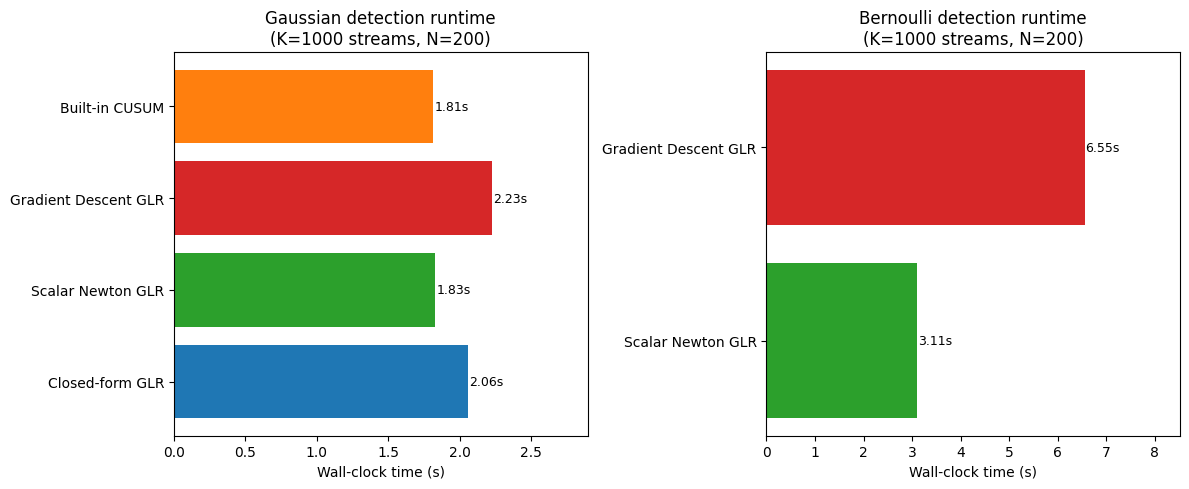


SUMMARY: Newton vs Gradient Descent for GLR Optimization

Gaussian N(0,1) → N(2,1):
  Method                     Avg delay   Detected       Time    Speedup
  --------------------------------------------------------------------
  Closed-form GLR                  1.8      1.000      2.06s      1.08x
  Scalar Newton GLR                1.8      1.000      1.83s      1.22x
  Gradient Descent GLR             1.8      1.000      2.23s      1.00x
  Built-in CUSUM                   3.1      1.000      1.81s      1.23x

Bernoulli Bern(0.3) → Bern(0.7):
  Method                     Avg delay   Detected       Time    Speedup
  --------------------------------------------------------------------
  Scalar Newton GLR               45.1      0.889      3.11s      2.11x
  Gradient Descent GLR            43.0      0.901      6.55s      1.00x


In [ ]:
# =====================================================================
# Plot 2: Wall-clock timing comparison (bar chart)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian timing
ax = axes[0]
names_g = list(results_gauss.keys())
times_g = [results_gauss[n]["time"] for n in names_g]
bars = ax.barh(names_g, times_g, color=[colors.get(n, "gray") for n in names_g])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Gaussian detection runtime\n(K={K_nvg} streams, N={N_nvg})")
for bar, t in zip(bars, times_g):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_g) * 1.3)

# Right: Bernoulli timing
ax = axes[1]
names_b = list(results_bern.keys())
times_b = [results_bern[n]["time"] for n in names_b]
bars = ax.barh(names_b, times_b, color=[colors_b.get(n, "gray") for n in names_b])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Bernoulli detection runtime\n(K={K_nvb} streams, N={N_nvb})")
for bar, t in zip(bars, times_b):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_b) * 1.3)

plt.tight_layout()
plt.show()

# --- Summary statistics ---
print("\n" + "=" * 70)
print("SUMMARY: General GLR solvers vs exact baselines")
print("=" * 70)

print("\nGaussian N(0,1) → N(2,1):")
print(f"  {'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time':>10} {'Speedup':>10}")
print("  " + "-" * 78)
ref_time_g = results_gauss.get("General GLR (Newton)", {}).get("time", 1.0)
for name, r in results_gauss.items():
    delay = np.mean(r["dt"]) - changepoint_nvg
    det_rate = np.mean(r["dt"] < N_nvg)
    speedup = ref_time_g / r["time"] if r["time"] > 0 else float("inf")
    print(f"  {name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s {speedup:>9.2f}x")

print(f"\nBernoulli Bern(0.3) → Bern(0.7):")
print(f"  {'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time':>10} {'Speedup':>10}")
print("  " + "-" * 78)
ref_time_b = results_bern.get("General GLR (Newton)", {}).get("time", 1.0)
for name, r in results_bern.items():
    delay = np.mean(r["dt"]) - changepoint_nvb
    det_rate = np.mean(r["dt"] < N_nvb)
    speedup = ref_time_b / r["time"] if r["time"] > 0 else float("inf")
    print(f"  {name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s {speedup:>9.2f}x")

print("\nConclusion candidate: Newton is the default general solver; GD is the robust fallback; L-BFGS is a Python-path reference.")

### 2.4 Multivariate Gaussian: general solver vs exact baseline

In multivariate settings, we benchmark the general solver against a known exact built-in baseline.

In [ ]:
# =====================================================================
# Multivariate Gaussian (v=5): exact GLR (built-in) vs general GLR (GD)
# =====================================================================
# θ ∈ ℝ⁵, A(θ) = ‖θ‖²/2, h(y) = y, known covariance = I₅
# Only GD (general GLR) and the built-in closed-form (exact GLR) can handle this.

P_MV = 5  # dimension of the observation / natural parameter
N_mv = 200
K_cal_mv = 5000
K_mv = 1000
changepoint_mv = N_mv // 2

# Penalty for v-dimensional Gaussian
@nb.njit
def penalty_glr_gauss_mv(g, t, p):
    logt = fastlog(t)
    return math.sqrt(p * logt) + logt

methods_mv = {}

# 1) General GLR — gradient descent (works for any v)
det_tmp = OnlineChangepointDetector(
    p=P_MV, f=f_glr_gauss_gd, h=h_gauss,
    penalty=penalty_glr_gauss_mv, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_mv, K=K_cal_mv, null_dist=np.random.normal,
)
methods_mv["General GLR (GD)"] = {
    "f": f_glr_gauss_gd, "h": h_gauss, "penalty": penalty_glr_gauss_mv,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) Exact GLR — built-in multivariate mean change detector (closed-form)
det_tmp = make_multivariate_mean_change_detector(p=P_MV)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_mv, K=K_cal_mv, null_dist=np.random.normal,
)
methods_mv["Exact GLR (built-in)"] = {
    "pen_const": det_tmp._state["penalty_constant"], "make_det": "builtin_mv",
}

print(f"Multivariate Gaussian (v={P_MV}) — calibrated thresholds:")
for name, m in methods_mv.items():
    print(f"  {name:<30s} λ = {m['pen_const']:.3f}")

# Generate test data: N(0,I₅) → N(μ₁,I₅) where μ₁ = (1,1,0,...,0)
mu_post = np.zeros(P_MV)
mu_post[0] = 1.0
mu_post[1] = 1.0

xs_mv = draw_samples(
    K=K_mv, N=N_mv, p=P_MV, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": np.zeros(P_MV), "scale": 1, "size": (P_MV,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": mu_post, "scale": 1, "size": (P_MV,)},
    changepoint_loc=changepoint_mv,
)

# --- Run all methods and time them ---
results_mv = {}
for name, m in methods_mv.items():
    dt = np.ones(K_mv, dtype=np.int64) * N_mv
    t0 = perf_counter()
    for k in range(K_mv):
        if m.get("make_det") == "builtin_mv":
            d = make_multivariate_mean_change_detector(p=P_MV, penalty_constant=m["pen_const"])
        else:
            d = OnlineChangepointDetector(
                p=P_MV, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
        for i in range(N_mv):
            d.update(xs_mv[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_mv[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<30} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 63)
for name, r in results_mv.items():
    delay = np.mean(r["dt"]) - changepoint_mv
    det_rate = np.mean(r["dt"] < N_mv)
    print(f"{name:<30} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

In [ ]:
# =====================================================================
# Multivariate: Detection delay vs change magnitude + timing
# =====================================================================
# Sweep ‖μ_post‖ from 0 to 4 (change in first two components)
magnitudes_mv = np.linspace(0, 4, 9)
dd_mv = {name: np.ones((len(magnitudes_mv), K_sw)) * N_mv for name in methods_mv}

for j, mag in enumerate(magnitudes_mv):
    mu_post_j = np.zeros(P_MV)
    mu_post_j[0] = mag / math.sqrt(2)
    mu_post_j[1] = mag / math.sqrt(2)

    xs_sw_mv = draw_samples(
        K=K_sw, N=N_mv, p=P_MV, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": np.zeros(P_MV), "scale": 1, "size": (P_MV,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": mu_post_j, "scale": 1, "size": (P_MV,)},
        changepoint_loc=changepoint_mv,
    )
    for k in range(K_sw):
        for name, m in methods_mv.items():
            if m.get("make_det") == "builtin_mv":
                d = make_multivariate_mean_change_detector(p=P_MV, penalty_constant=m["pen_const"])
            else:
                d = OnlineChangepointDetector(
                    p=P_MV, f=m["f"], h=m["h"],
                    penalty=m["penalty"], penalty_constant=m["pen_const"],
                )
            for i in range(N_mv):
                d.update(xs_sw_mv[k, i])
                if d.alarm:
                    dd_mv[name][j, k] = i + 1
                    break

# --- Plots ---
colors_mv = {
    "General GLR (GD)":    "tab:red",
    "Exact GLR (built-in)": "tab:blue",
}
markers_mv = {
    "General GLR (GD)":    "D-.",
    "Exact GLR (built-in)": "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Detection delay vs magnitude
ax = axes[0]
for name in methods_mv:
    avg_dd = np.mean(dd_mv[name], axis=1) - changepoint_mv
    ax.plot(magnitudes_mv, avg_dd, markers_mv.get(name, "o-"),
            color=colors_mv.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("‖μ_post‖ (change magnitude)")
ax.set_ylabel("Average detection delay")
ax.set_title(f"Multivariate Gaussian (v={P_MV}), N={N_mv}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Timing bar chart
ax = axes[1]
names_mv = list(results_mv.keys())
times_mv = [results_mv[n]["time"] for n in names_mv]
bars = ax.barh(names_mv, times_mv, color=[colors_mv.get(n, "gray") for n in names_mv])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Multivariate detection runtime\n(v={P_MV}, K={K_mv}, N={N_mv})")
for bar, t_val in zip(bars, times_mv):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t_val:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_mv) * 1.3)

plt.tight_layout()
plt.show()

# Summary
print(f"\nMultivariate Gaussian (v={P_MV}), N(0,I) → N(μ,I) with ‖μ‖={np.linalg.norm(mu_post):.1f}:")
print(f"  {'Method':<30} {'Avg delay':>10} {'Detected':>10} {'Time':>10}")
print("  " + "-" * 63)
for name, r in results_mv.items():
    delay = np.mean(r["dt"]) - changepoint_mv
    det_rate = np.mean(r["dt"] < N_mv)
    print(f"  {name:<30} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s")